# Proyecto analítico CREAN — App de inversiones

## Propósito

Desarrollar una solución analítica orientada a responder, en secuencia, cuatro preguntas de negocio:

1. **¿Cómo se comportan los clientes según la información disponible?**
2. **¿Qué clientes presentan afinidad o potencial para invertir?**
3. **Entre los inversionistas, qué perfiles de inversión pueden identificarse?**
4. **¿Qué monto potencial de inversión puede estimarse para dichos clientes?**

El notebook conserva la trazabilidad técnica del proceso completo: integración, calidad de datos, análisis exploratorio, modelado, validación e interpretabilidad.

## Índice

1. **Contexto, configuración y fuentes**
2. **Construcción de la tabla analítica**
3. **Calidad de datos y caracterización general de clientes**
4. **Identificación de clientes potenciales para inversión**
5. **Caracterización de los inversionistas y estimación inicial del monto**
6. **Modelado especializado del perfil y monto de inversión**
7. **Aplicación de la solución en el negocio**
8. **Conclusiones y lineamientos de mantenimiento**

> La estructura sigue el flujo natural de decisión del negocio: comprender al cliente → identificar afinidad → caracterizar al inversionista → estimar potencial → traducir resultados en acciones.

# 1. Contexto, configuración y fuentes

Se importan dependencias, se conectan las fuentes SQLite y se realiza una inspección inicial de estructura, categorías y duplicados.

## 1.1 Dependencias

In [1]:
#!pip install pandas 
#!pip install matplotlib
#!pip install seaborn 

In [2]:

import pandas as pd
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



## 1.2 Conexión a las fuentes SQLite

In [3]:
conn_clientes = sqlite3.connect(r"clientes\clientes.db")

df_clientes = pd.read_sql_query("SELECT * FROM clientes", conn_clientes)

In [4]:
conn_crean_aho_cte = sqlite3.connect(r"crean_aho_cte\crean_aho_cte.db")

df_crean_aho_cte = pd.read_sql_query("SELECT * FROM crean_aho_cte", conn_crean_aho_cte)

In [5]:
conn_crean_bolsillos = sqlite3.connect(r"crean_bolsillos\crean_bolsillos.db")

df_crean_bolsillos = pd.read_sql_query("SELECT * FROM crean_bolsillos", conn_crean_bolsillos)

In [6]:
conn_crean_fidu = sqlite3.connect(r"crean_fiducuenta\crean_fiducuenta.db")

df_crean_fidu = pd.read_sql_query("SELECT * FROM crean_fiducuenta", conn_crean_fidu)

In [7]:
conn_crean_inv_virtual = sqlite3.connect(r"crean_inv_virtual_cdt\crean_inv_virtual_cdt.db")

df_crean_inv_virtual = pd.read_sql_query("SELECT * FROM crean_inv_virtual_cdt", conn_crean_inv_virtual)

In [8]:
conn_estimador = sqlite3.connect(r"estimador_ing\estimador_ing.db")

df_estimador = pd.read_sql_query("SELECT * FROM estimador_ing", conn_estimador)

In [9]:
conn_invesbot = sqlite3.connect(r"invesbot\invesbot.db")

df_invesbot = pd.read_sql_query("SELECT * FROM invesbot", conn_invesbot)

## 1.3 Inspección inicial de las fuentes

In [10]:
df_invesbot.head()

,fecha,numero_id,producto,saldo
0,2026-05-11,-4455498691690317961,INVESBOT,425405.92
1,2025-11-25,7190472578366945756,INVESBOT,7971987.66
2,2025-06-24,-1237314025466821076,INVESBOT,173043.65
3,2026-04-16,-375000770824817477,INVESBOT,27438543.23
4,2026-04-27,-2984135926251809763,INVESBOT,5121208.76


In [11]:
df_estimador.head()

,numero_id,producto,estimador_ingreso
0,8482174354453385212,ESTIMADOR INGRESO,4853570.31
1,8831305677363912137,ESTIMADOR INGRESO,1749148.95
2,8289414305330255763,ESTIMADOR INGRESO,1542841.12
3,5066284055348912520,ESTIMADOR INGRESO,2889280.32
4,4208199011104756958,ESTIMADOR INGRESO,1742505.76


In [12]:
df_estimador["numero_id"].duplicated().sum()

np.int64(0)

In [13]:
df_crean_inv_virtual.head()

,fecha,numero_id,producto,saldo
0,2025-06-01,-6228143491694978166,INVERSIóN VIRTUAL,15000000.0
1,2025-08-26,4123427955016713068,INVERSIóN VIRTUAL,500000.0
2,2025-06-10,-6813311859168202310,INVERSIóN VIRTUAL,62522900.0
3,2025-12-01,-1182476400737234276,INVERSIóN VIRTUAL,20627000.0
4,2026-03-01,-6751564772676490392,CDT,10025000.0


In [14]:
df_crean_fidu.head()

,fecha,numero_id,producto,saldo
0,2025-09-01,-2165011641475171977,FIDUCUENTA,19337.21
1,2025-08-01,-2661850999936757122,FIDUCUENTA,7540113.82
2,2026-06-01,7030715403446493978,FIDUCUENTA,2308.21
3,2026-05-01,7720175993936919159,FIDUCUENTA,2818.81
4,2025-11-01,-6374737054833898392,FIDUCUENTA,633685.45


In [15]:
df_crean_fidu.producto.value_counts()

producto
FIDUCUENTA    1000000
Name: count, dtype: int64

In [16]:
df_crean_bolsillos.head()


,fecha,numero_id,producto,saldo
0,2026-05-01,1013449549804401435,BOLSILLOS,0.00
1,2026-04-01,-1429655475333460263,BOLSILLOS,762189.70
2,2026-04-01,-7881360550938175834,BOLSILLOS,761222.85
3,2025-08-01,-4886857658013163021,BOLSILLOS,100000.00
4,2026-01-01,1547171292443722937,BOLSILLOS,0.00


In [17]:
df_crean_bolsillos.producto.value_counts()

producto
BOLSILLOS    1000000
Name: count, dtype: int64

In [18]:
df_crean_aho_cte.head()

,fecha,numero_id,producto,saldo
0,2026-03-01,-1787624227069906332,CUENTA DE AHORRO,171151.39
1,2025-07-01,2081948080502941032,CUENTA DE AHORRO,7674083.03
2,2026-06-01,-4762164790684256469,CUENTA DE AHORRO,22170.28
3,2025-12-01,7597949800216855292,CUENTA DE AHORRO,1121.97
4,2026-05-01,-5893334273208187262,CUENTA DE AHORRO,10945.58


In [19]:
df_crean_aho_cte.producto.value_counts()

producto
CUENTA DE AHORRO       987914
CUENTA DE CORRIENTE     12086
Name: count, dtype: int64

In [20]:
df_clientes.head()

,numero_id,grupo_edad,desc_genero,desc_segmento,desc_tipo_de_vivienda,ingresos_mensuales,total_egresos_mensuales,total_activos,total_pasivos,total_patrimonio
0,8805210490649048784,65+,masculino,preferencial,NaN,29239444.0,30000000.0,1.450470e+11,6.356702e+09,1.054223e+08
1,-5723572980375902369,50-65,masculino,preferencial,PROPIA,31024544.0,10000000.0,1.133345e+09,8.307200e+07,1.050273e+09
2,-8245474570363424359,65+,masculino,preferencial,PROPIA,2834000.0,500000.0,1.073787e+09,0.000000e+00,3.430000e+08
3,-7840506796880772723,65+,femenino,preferencial,PROPIA,28035850.0,0.0,1.750000e+08,0.000000e+00,5.500000e+07
4,5309731180094827430,36-49,femenino,preferencial,FAMILIAR,3846205.0,2500000.0,7.580000e+08,0.000000e+00,7.580000e+08


# 2. Construcción de la tabla analítica

La granularidad objetivo es **una fila por cliente**. Las fuentes históricas se agregan por `numero_id` y luego se integran progresivamente.

## 2.1 Agregación de Bolsillos


In [21]:
resumen_bolsillos = (
    df_crean_bolsillos
    .groupby("numero_id")
    .agg(
        saldo_actual_bolsillo=("saldo", "last"),       # Último saldo
        saldo_promedio_bolsillo=("saldo", "mean"),     # Comportamiento promedio
        saldo_maximo_bolsillo=("saldo", "max"),        # Máximo alcanzado
        saldo_minimo_bolsillo=("saldo", "min"),        # Mínimo alcanzado
        meses_activos_bolsillo=("fecha", "nunique")    # Antigüedad/uso
    )
    .reset_index())

df_modelo = df_clientes.merge(resumen_bolsillos,on="numero_id",how="left")

df_modelo["tiene_bolsillos"] = (
    df_modelo["saldo_actual_bolsillo"]
    .notna()
    .astype(int)
)

In [22]:
df_modelo

,numero_id,grupo_edad,desc_genero,desc_segmento,desc_tipo_de_vivienda,ingresos_mensuales,total_egresos_mensuales,total_activos,total_pasivos,total_patrimonio,saldo_actual_bolsillo,saldo_promedio_bolsillo,saldo_maximo_bolsillo,saldo_minimo_bolsillo,meses_activos_bolsillo,tiene_bolsillos
0,8805210490649048784,65+,masculino,preferencial,NaN,29239444.0,30000000.0,1.450470e+11,6.356702e+09,1.054223e+08,NaN,NaN,NaN,NaN,NaN,0
1,-5723572980375902369,50-65,masculino,preferencial,PROPIA,31024544.0,10000000.0,1.133345e+09,8.307200e+07,1.050273e+09,NaN,NaN,NaN,NaN,NaN,0
2,-8245474570363424359,65+,masculino,preferencial,PROPIA,2834000.0,500000.0,1.073787e+09,0.000000e+00,3.430000e+08,NaN,NaN,NaN,NaN,NaN,0
3,-7840506796880772723,65+,femenino,preferencial,PROPIA,28035850.0,0.0,1.750000e+08,0.000000e+00,5.500000e+07,NaN,NaN,NaN,NaN,NaN,0
4,5309731180094827430,36-49,femenino,preferencial,FAMILIAR,3846205.0,2500000.0,7.580000e+08,0.000000e+00,7.580000e+08,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
860226,5882320376089669583,65+,masculino,plus,NaN,5436883.0,0.0,3.055760e+08,0.000000e+00,3.055760e+08,NaN,NaN,NaN,NaN,NaN,0
860227,6034010744462256034,36-49,masculino,plus,FAMILIAR,7143835.0,4500000.0,3.173790e+08,3.500000e+07,2.823790e+08,NaN,NaN,NaN,NaN,NaN,0
860228,3918722977197857898,50-65,masculino,plus,NaN,7800000.0,1400000.0,3.500000e+08,1.200000e+08,2.300000e+08,NaN,NaN,NaN,NaN,NaN,0
860229,-8439226781033547229,50-65,femenino,plus,NaN,7521978.0,0.0,6.669600e+07,0.000000e+00,6.669600e+07,NaN,NaN,NaN,NaN,NaN,0


## 2.2 Separación de cuentas de ahorro y corriente


In [23]:
df_crean_ahorro = df_crean_aho_cte[df_crean_aho_cte["producto"] == "CUENTA DE AHORRO"]

df_crean_corriente = df_crean_aho_cte[df_crean_aho_cte["producto"] == "CUENTA DE CORRIENTE"]

### 2.2.1 Cuenta de ahorro


In [24]:
resumen_cta_ahorro = (
    df_crean_ahorro
    .groupby("numero_id")
    .agg(
        saldo_actual_ahorro=("saldo", "last"),       # Último saldo
        saldo_promedio_ahorro=("saldo", "mean"),     # Comportamiento promedio
        saldo_maximo_ahorro=("saldo", "max"),        # Máximo alcanzado
        saldo_minimo_ahorro=("saldo", "min"),        # Mínimo alcanzado
        meses_activos_ahorro=("fecha", "nunique")    # Antigüedad/uso
    )
    .reset_index())

df_modelo = df_modelo.merge(resumen_cta_ahorro,on="numero_id",how="left")

df_modelo["tiene_cta_ahorro"] = (
    df_modelo["saldo_actual_ahorro"]
    .notna()
    .astype(int)
)

### 2.2.2 Cuenta corriente


In [25]:
resumen_cta_corriente = (
    df_crean_corriente
    .groupby("numero_id")
    .agg(
        saldo_actual_corriente=("saldo", "last"),       # Último saldo
        saldo_promedio_corriente=("saldo", "mean"),     # Comportamiento promedio
        saldo_maximo_corriente=("saldo", "max"),        # Máximo alcanzado
        saldo_minimo_corriente=("saldo", "min"),        # Mínimo alcanzado
        meses_activos_corriente=("fecha", "nunique")    # Antigüedad/uso
    )
    .reset_index())

df_modelo = df_modelo.merge(resumen_cta_corriente,on="numero_id",how="left")

df_modelo["tiene_cta_corriente"] = (
    df_modelo["saldo_actual_corriente"]
    .notna()
    .astype(int)
)

## 2.3 Fiducuenta


In [26]:
# df_crean_fidu

resumen_fidu = (
    df_crean_fidu
    .groupby("numero_id")
    .agg(
        saldo_actual_fiducuenta=("saldo", "last"),       # Último saldo
        saldo_promedio_fiducuenta=("saldo", "mean"),     # Comportamiento promedio
        saldo_maximo_fiducuenta=("saldo", "max"),        # Máximo alcanzado
        saldo_minimo_fiducuenta=("saldo", "min"),        # Mínimo alcanzado
        meses_activos_fiducuenta=("fecha", "nunique")    # Antigüedad/uso
    )
    .reset_index())

df_modelo = df_modelo.merge(resumen_fidu,on="numero_id",how="left")

df_modelo["tiene_fiducuenta"] = (
    df_modelo["saldo_actual_fiducuenta"]
    .notna()
    .astype(int)
)

In [27]:
df_modelo.tiene_fiducuenta.value_counts()

tiene_fiducuenta
0    679210
1    181021
Name: count, dtype: int64

## 2.4 Inversión Virtual y CDT


In [28]:
df_crean_inv_virtual.producto.value_counts()

producto
INVERSIóN VIRTUAL    678038
CDT                  316139
Name: count, dtype: int64

In [29]:
df_inv_virtual = df_crean_inv_virtual[df_crean_inv_virtual["producto"] == "INVERSIóN VIRTUAL"]

df_cdt = df_crean_inv_virtual[df_crean_inv_virtual["producto"] == "CDT"]

### 2.4.1 Inversión Virtual


In [30]:
# df_crean_fidu

resumen_inv_virtual = (
    df_inv_virtual
    .groupby("numero_id")
    .agg(
        saldo_actual_inv_virtual=("saldo", "last"),       # Último saldo
        saldo_promedio_inv_virtual=("saldo", "mean"),     # Comportamiento promedio
        saldo_maximo_inv_virtual=("saldo", "max"),        # Máximo alcanzado
        saldo_minimo_inv_virtual=("saldo", "min"),        # Mínimo alcanzado
        meses_activos_inv_virtual=("fecha", "nunique")    # Antigüedad/uso
    )
    .reset_index())

df_modelo = df_modelo.merge(resumen_inv_virtual,on="numero_id",how="left")

df_modelo["tiene_inversion_virtual"] = (
    df_modelo["saldo_actual_inv_virtual"]
    .notna()
    .astype(int)
)

In [31]:
df_modelo.columns

Index(['numero_id', 'grupo_edad', 'desc_genero', 'desc_segmento',
       'desc_tipo_de_vivienda', 'ingresos_mensuales',
       'total_egresos_mensuales', 'total_activos', 'total_pasivos',
       'total_patrimonio', 'saldo_actual_bolsillo', 'saldo_promedio_bolsillo',
       'saldo_maximo_bolsillo', 'saldo_minimo_bolsillo',
       'meses_activos_bolsillo', 'tiene_bolsillos', 'saldo_actual_ahorro',
       'saldo_promedio_ahorro', 'saldo_maximo_ahorro', 'saldo_minimo_ahorro',
       'meses_activos_ahorro', 'tiene_cta_ahorro', 'saldo_actual_corriente',
       'saldo_promedio_corriente', 'saldo_maximo_corriente',
       'saldo_minimo_corriente', 'meses_activos_corriente',
       'tiene_cta_corriente', 'saldo_actual_fiducuenta',
       'saldo_promedio_fiducuenta', 'saldo_maximo_fiducuenta',
       'saldo_minimo_fiducuenta', 'meses_activos_fiducuenta',
       'tiene_fiducuenta', 'saldo_actual_inv_virtual',
       'saldo_promedio_inv_virtual', 'saldo_maximo_inv_virtual',
       'saldo_minimo_in

### 2.4.2 CDT


In [32]:
# df_crean_fidu

resumen_cdt = (
    df_cdt
    .groupby("numero_id")
    .agg(
        saldo_actual_cdt=("saldo", "last"),       # Último saldo
        saldo_promedio_cdt=("saldo", "mean"),     # Comportamiento promedio
        saldo_maximo_cdt=("saldo", "max"),        # Máximo alcanzado
        saldo_minimo_cdt=("saldo", "min"),        # Mínimo alcanzado
        meses_activos_cdt=("fecha", "nunique")    # Antigüedad/uso
    )
    .reset_index())

df_modelo = df_modelo.merge(resumen_cdt,on="numero_id",how="left")

df_modelo["tiene_cdt"] = (
    df_modelo["saldo_actual_cdt"]
    .notna()
    .astype(int)
)

## 2.5 Investbot


In [33]:
#df_estimador


resumen_investbot = (
    df_invesbot
    .groupby("numero_id")
    .agg(
        saldo_actual_investbot=("saldo", "last"),       # Último saldo
        saldo_promedio_investbot=("saldo", "mean"),     # Comportamiento promedio
        saldo_maximo_investbot=("saldo", "max"),        # Máximo alcanzado
        saldo_minimo_investbot=("saldo", "min"),        # Mínimo alcanzado
        meses_activos_investbot=("fecha", "nunique")    # Antigüedad/uso
    )
    .reset_index())

df_modelo = df_modelo.merge(resumen_investbot,on="numero_id",how="left")

df_modelo["tiene_investbot"] = (
    df_modelo["saldo_actual_investbot"]
    .notna()
    .astype(int)
)

In [34]:
df_modelo.columns

Index(['numero_id', 'grupo_edad', 'desc_genero', 'desc_segmento',
       'desc_tipo_de_vivienda', 'ingresos_mensuales',
       'total_egresos_mensuales', 'total_activos', 'total_pasivos',
       'total_patrimonio', 'saldo_actual_bolsillo', 'saldo_promedio_bolsillo',
       'saldo_maximo_bolsillo', 'saldo_minimo_bolsillo',
       'meses_activos_bolsillo', 'tiene_bolsillos', 'saldo_actual_ahorro',
       'saldo_promedio_ahorro', 'saldo_maximo_ahorro', 'saldo_minimo_ahorro',
       'meses_activos_ahorro', 'tiene_cta_ahorro', 'saldo_actual_corriente',
       'saldo_promedio_corriente', 'saldo_maximo_corriente',
       'saldo_minimo_corriente', 'meses_activos_corriente',
       'tiene_cta_corriente', 'saldo_actual_fiducuenta',
       'saldo_promedio_fiducuenta', 'saldo_maximo_fiducuenta',
       'saldo_minimo_fiducuenta', 'meses_activos_fiducuenta',
       'tiene_fiducuenta', 'saldo_actual_inv_virtual',
       'saldo_promedio_inv_virtual', 'saldo_maximo_inv_virtual',
       'saldo_minimo_in

## 2.6 Estimador de ingreso


In [35]:
df_modelo = df_modelo.merge(df_estimador,on="numero_id",how="left")

In [36]:
df_modelo.drop(columns="producto", inplace=True)

In [37]:
df_modelo

,numero_id,grupo_edad,desc_genero,desc_segmento,desc_tipo_de_vivienda,ingresos_mensuales,total_egresos_mensuales,total_activos,total_pasivos,total_patrimonio,...,saldo_minimo_cdt,meses_activos_cdt,tiene_cdt,saldo_actual_investbot,saldo_promedio_investbot,saldo_maximo_investbot,saldo_minimo_investbot,meses_activos_investbot,tiene_investbot,estimador_ingreso
0,8805210490649048784,65+,masculino,preferencial,NaN,29239444.0,30000000.0,1.450470e+11,6.356702e+09,1.054223e+08,...,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN
1,-5723572980375902369,50-65,masculino,preferencial,PROPIA,31024544.0,10000000.0,1.133345e+09,8.307200e+07,1.050273e+09,...,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN
2,-8245474570363424359,65+,masculino,preferencial,PROPIA,2834000.0,500000.0,1.073787e+09,0.000000e+00,3.430000e+08,...,100000000.0,19.0,1,NaN,NaN,NaN,NaN,NaN,0,NaN
3,-7840506796880772723,65+,femenino,preferencial,PROPIA,28035850.0,0.0,1.750000e+08,0.000000e+00,5.500000e+07,...,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN
4,5309731180094827430,36-49,femenino,preferencial,FAMILIAR,3846205.0,2500000.0,7.580000e+08,0.000000e+00,7.580000e+08,...,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
860226,5882320376089669583,65+,masculino,plus,NaN,5436883.0,0.0,3.055760e+08,0.000000e+00,3.055760e+08,...,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,5707416.22
860227,6034010744462256034,36-49,masculino,plus,FAMILIAR,7143835.0,4500000.0,3.173790e+08,3.500000e+07,2.823790e+08,...,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,1423500.00
860228,3918722977197857898,50-65,masculino,plus,NaN,7800000.0,1400000.0,3.500000e+08,1.200000e+08,2.300000e+08,...,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN
860229,-8439226781033547229,50-65,femenino,plus,NaN,7521978.0,0.0,6.669600e+07,0.000000e+00,6.669600e+07,...,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,0,7226462.34


## 2.7 Variables derivadas de negocio

Se crean indicadores que resumen capacidad económica, liquidez, ahorro, endeudamiento y relacionamiento con productos.

> `total_inversiones`, `num_productos` y `num_productos_inversion` son útiles para descripción y para el futuro modelo de monto, pero **no deben utilizarse como predictores del modelo de clasificación** cuando el target se define a partir de productos de inversión.


### 2.7.1 Total invertido


In [38]:
df_modelo["total_inversiones"] = (
    df_modelo["saldo_actual_investbot"].fillna(0)
    + df_modelo["saldo_actual_fiducuenta"].fillna(0)
    + df_modelo["saldo_actual_inv_virtual"].fillna(0)
    + df_modelo["saldo_actual_cdt"].fillna(0)
    
)

In [39]:
df_modelo['total_inversiones'].value_counts()

total_inversiones
0.000000e+00    639910
1.000000e+07      1684
2.000000e+07      1394
5.000000e+06      1163
1.000000e+06       938
                 ...  
1.643571e+07         1
6.768234e+04         1
3.632482e+07         1
3.501280e+08         1
3.300339e+06         1
Name: count, Length: 190998, dtype: int64

### 2.7.2 Liquidez


In [40]:
df_modelo["liquidez"] = (
    df_modelo["saldo_actual_ahorro"].fillna(0)
    + df_modelo["saldo_actual_corriente"].fillna(0)
)

In [41]:
df_modelo['liquidez'].value_counts(ascending= True)

liquidez
2.409809e+08         1
9.704052e+06         1
3.198757e+05         1
3.191655e+06         1
5.636994e+06         1
                 ...  
9.000000e-02        89
1.000000e+03        95
1.000000e+00       106
1.000000e-02       108
0.000000e+00    415324
Name: count, Length: 426681, dtype: int64

### 2.7.3 Total ahorro


In [42]:
df_modelo["total_ahorro"] = (
    df_modelo["saldo_actual_bolsillo"].fillna(0)
    + df_modelo["saldo_actual_ahorro"].fillna(0)
)

In [43]:
df_modelo['total_ahorro'].value_counts(ascending= True)

total_ahorro
2.409809e+08         1
9.704052e+06         1
3.162966e+05         1
3.162698e+06         1
5.840752e+06         1
                 ...  
5.000000e+04       124
1.000000e+05       127
1.000000e+03       152
1.000000e+04       205
0.000000e+00    407275
Name: count, Length: 432312, dtype: int64

### 2.7.4 Capacidad de ahorro


In [44]:
df_modelo["capacidad_ahorro"] = (
    df_modelo["ingresos_mensuales"]
    - df_modelo["total_egresos_mensuales"]
)

In [45]:
df_modelo['capacidad_ahorro'].value_counts(ascending= True)

capacidad_ahorro
-760556.0          1
 21024544.0        1
 28035850.0        1
 1346205.0         1
 34441440.0        1
               ...  
 1500000.0      6174
 500000.0       6524
 1000000.0      9576
 2000000.0     15115
 0.0           38432
Name: count, Length: 501496, dtype: int64

### 2.7.5 Ratio de endeudamiento


In [46]:
df_modelo["ratio_endeudamiento"] = (
    df_modelo["total_pasivos"]
    / df_modelo["total_activos"]
)

In [47]:
df_modelo['ratio_endeudamiento'].value_counts(ascending= True)

ratio_endeudamiento
0.043825         1
0.073298         1
0.106926         1
0.673162         1
0.040951         1
             ...  
0.500000      2130
0.200000      2195
0.166667      5138
1.000000     39587
0.000000    549125
Name: count, Length: 103414, dtype: int64

### 2.7.6 Número de productos de inversión


In [48]:
df_modelo["num_productos_inversion"] = (
    df_modelo["tiene_fiducuenta"]
    + df_modelo["tiene_investbot"]
    + df_modelo["tiene_inversion_virtual"]
    + df_modelo["tiene_cdt"]
)

In [49]:
df_modelo['num_productos_inversion'].value_counts(ascending= True)

num_productos_inversion
4       132
3      3802
2     45271
1    171248
0    639778
Name: count, dtype: int64

### 2.7.7 Número total de productos


In [50]:
df_modelo["num_productos"] = (
    df_modelo["tiene_bolsillos"]
    + df_modelo["tiene_cta_ahorro"]
    + df_modelo["tiene_cta_corriente"]
    + df_modelo["tiene_fiducuenta"]
    + df_modelo["tiene_inversion_virtual"]
    + df_modelo["tiene_cdt"]
    + df_modelo["tiene_investbot"]
)

In [51]:
df_modelo['num_productos'].value_counts(ascending= True)

num_productos
7         8
6       227
5      3744
4     39306
2    108053
3    120780
1    258525
0    329588
Name: count, dtype: int64

In [52]:
df_modelo

,numero_id,grupo_edad,desc_genero,desc_segmento,desc_tipo_de_vivienda,ingresos_mensuales,total_egresos_mensuales,total_activos,total_pasivos,total_patrimonio,...,meses_activos_investbot,tiene_investbot,estimador_ingreso,total_inversiones,liquidez,total_ahorro,capacidad_ahorro,ratio_endeudamiento,num_productos_inversion,num_productos
0,8805210490649048784,65+,masculino,preferencial,NaN,29239444.0,30000000.0,1.450470e+11,6.356702e+09,1.054223e+08,...,NaN,0,NaN,0.000000e+00,0.0,0.0,-760556.0,0.043825,0,0
1,-5723572980375902369,50-65,masculino,preferencial,PROPIA,31024544.0,10000000.0,1.133345e+09,8.307200e+07,1.050273e+09,...,NaN,0,NaN,0.000000e+00,0.0,0.0,21024544.0,0.073298,0,0
2,-8245474570363424359,65+,masculino,preferencial,PROPIA,2834000.0,500000.0,1.073787e+09,0.000000e+00,3.430000e+08,...,NaN,0,NaN,4.502679e+08,0.0,0.0,2334000.0,0.000000,1,1
3,-7840506796880772723,65+,femenino,preferencial,PROPIA,28035850.0,0.0,1.750000e+08,0.000000e+00,5.500000e+07,...,NaN,0,NaN,0.000000e+00,0.0,0.0,28035850.0,0.000000,0,0
4,5309731180094827430,36-49,femenino,preferencial,FAMILIAR,3846205.0,2500000.0,7.580000e+08,0.000000e+00,7.580000e+08,...,NaN,0,NaN,0.000000e+00,0.0,0.0,1346205.0,0.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
860226,5882320376089669583,65+,masculino,plus,NaN,5436883.0,0.0,3.055760e+08,0.000000e+00,3.055760e+08,...,NaN,0,5707416.22,0.000000e+00,0.0,0.0,5436883.0,0.000000,0,0
860227,6034010744462256034,36-49,masculino,plus,FAMILIAR,7143835.0,4500000.0,3.173790e+08,3.500000e+07,2.823790e+08,...,NaN,0,1423500.00,0.000000e+00,0.0,0.0,2643835.0,0.110278,0,0
860228,3918722977197857898,50-65,masculino,plus,NaN,7800000.0,1400000.0,3.500000e+08,1.200000e+08,2.300000e+08,...,NaN,0,NaN,0.000000e+00,0.0,0.0,6400000.0,0.342857,0,0
860229,-8439226781033547229,50-65,femenino,plus,NaN,7521978.0,0.0,6.669600e+07,0.000000e+00,6.669600e+07,...,NaN,0,7226462.34,0.000000e+00,0.0,0.0,7521978.0,0.000000,0,0


# 3. Calidad de datos y caracterización general de clientes

Esta sección valida la calidad de la tabla analítica y describe el comportamiento general de la población antes de construir cualquier modelo.

El objetivo es entender quiénes son los clientes, cómo se distribuyen sus principales variables demográficas y financieras, qué productos utilizan y qué patrones preliminares aparecen en la información disponible.

## 3.1 Diagnóstico inicial

In [53]:
df_modelo.shape

(860231, 60)

In [54]:
 
df_modelo.info()

<class 'pandas.DataFrame'>
RangeIndex: 860231 entries, 0 to 860230
Data columns (total 60 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   numero_id                   860231 non-null  int64  
 1   grupo_edad                  860231 non-null  str    
 2   desc_genero                 860138 non-null  str    
 3   desc_segmento               860231 non-null  str    
 4   desc_tipo_de_vivienda       268532 non-null  str    
 5   ingresos_mensuales          859982 non-null  float64
 6   total_egresos_mensuales     859982 non-null  float64
 7   total_activos               859982 non-null  float64
 8   total_pasivos               859982 non-null  float64
 9   total_patrimonio            859971 non-null  float64
 10  saldo_actual_bolsillo       260714 non-null  float64
 11  saldo_promedio_bolsillo     260714 non-null  float64
 12  saldo_maximo_bolsillo       260714 non-null  float64
 13  saldo_minimo_bolsillo    

In [55]:
### Porcentaje de nulos 
(df_modelo.isnull().mean()*100).sort_values(ascending=False)

meses_activos_investbot       99.393884
saldo_actual_investbot        99.393884
saldo_minimo_investbot        99.393884
saldo_maximo_investbot        99.393884
saldo_promedio_investbot      99.393884
saldo_promedio_corriente      99.343781
saldo_minimo_corriente        99.343781
saldo_actual_corriente        99.343781
meses_activos_corriente       99.343781
saldo_maximo_corriente        99.343781
saldo_actual_cdt              96.945704
saldo_maximo_cdt              96.945704
saldo_promedio_cdt            96.945704
meses_activos_cdt             96.945704
saldo_minimo_cdt              96.945704
meses_activos_inv_virtual     92.883888
saldo_promedio_inv_virtual    92.883888
saldo_maximo_inv_virtual      92.883888
saldo_minimo_inv_virtual      92.883888
saldo_actual_inv_virtual      92.883888
meses_activos_fiducuenta      78.956699
saldo_actual_fiducuenta       78.956699
saldo_promedio_fiducuenta     78.956699
saldo_minimo_fiducuenta       78.956699
saldo_maximo_fiducuenta       78.956699


In [56]:
#### DUPLICADOS 

if df_modelo.numero_id.duplicated().sum() > 0:

    print(f"Cantidad De registros duplicados: {df_modelo.numero_id.duplicated().sum()}")
    print("Existen duplicados, se procede a eliminarlos")    
    df_modelo=df_modelo.drop_duplicates()
    print(f"Se han eliminado los duplicados {df_modelo.numero_id.duplicated().sum()}")
else:
    print("El dataframe no tiene duplicados")






Cantidad De registros duplicados: 8
Existen duplicados, se procede a eliminarlos
Se han eliminado los duplicados 0


## 3.2 Limpieza y validaciones consolidadas

In [57]:
## 1

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_calidad = df_modelo.copy()

In [58]:
### 2 Validar granularidad 

print(f"Registros: {df_calidad.shape[0]:,}")
print(f"Variables: {df_calidad.shape[1]}")
print(f"Clientes únicos: {df_calidad['numero_id'].nunique():,}")
print(f"IDs duplicados: {df_calidad['numero_id'].duplicated().sum():,}")

assert df_calidad["numero_id"].is_unique, \
    "Existen clientes duplicados en la tabla analítica."

print("✅ Granularidad correcta: una fila por cliente.")

Registros: 860,223
Variables: 60
Clientes únicos: 860,223
IDs duplicados: 0
✅ Granularidad correcta: una fila por cliente.


In [59]:
### 3. Revisar los valores faltantes originales

tabla_nulos_inicial = pd.DataFrame({
    "cantidad_nulos": df_calidad.isna().sum(),
    "porcentaje_nulos": df_calidad.isna().mean().mul(100)
})

tabla_nulos_inicial = (
    tabla_nulos_inicial
    .query("cantidad_nulos > 0")
    .sort_values("porcentaje_nulos", ascending=False)
)

tabla_nulos_inicial

,cantidad_nulos,porcentaje_nulos
saldo_minimo_investbot,855009,99.393878
saldo_actual_investbot,855009,99.393878
saldo_maximo_investbot,855009,99.393878
saldo_promedio_investbot,855009,99.393878
meses_activos_investbot,855009,99.393878
saldo_maximo_corriente,854578,99.343775
saldo_promedio_corriente,854578,99.343775
saldo_minimo_corriente,854578,99.343775
meses_activos_corriente,854578,99.343775
saldo_actual_corriente,854578,99.343775


In [60]:
## 4. Tratar los nulos estructurales de productos

# Estas columnas quedan nulas cuando el cliente no aparece en la fuente del producto.

prefijos_producto = (
    "saldo_actual_",
    "saldo_promedio_",
    "saldo_maximo_",
    "saldo_minimo_",
    "meses_activos_"
)

columnas_producto = [
    columna
    for columna in df_calidad.columns
    if columna.startswith(prefijos_producto)
]

df_calidad[columnas_producto] = (
    df_calidad[columnas_producto]
    .fillna(0)
)

print(
    "Nulos restantes en variables de productos:",
    df_calidad[columnas_producto].isna().sum().sum()
)

Nulos restantes en variables de productos: 0


In [61]:
### 5. Limpiar variables categóricas

columnas_categoricas = [
    "grupo_edad",
    "desc_genero",
    "desc_segmento",
    "desc_tipo_de_vivienda"
]

for columna in columnas_categoricas:
    df_calidad[columna] = (
        df_calidad[columna]
        .astype("string")
        .str.strip()
        .str.upper()
        .fillna("SIN INFORMACION")
    )

df_calidad[columnas_categoricas].isna().sum()

grupo_edad               0
desc_genero              0
desc_segmento            0
desc_tipo_de_vivienda    0
dtype: int64

In [62]:
### 6. Recalcular el ratio de endeudamiento de forma segura

df_calidad["ratio_endeudamiento"] = np.where(
    df_calidad["total_activos"] > 0,
    df_calidad["total_pasivos"] / df_calidad["total_activos"],
    np.nan
)

df_calidad.replace([np.inf, -np.inf], np.nan, inplace=True)

,numero_id,grupo_edad,desc_genero,desc_segmento,desc_tipo_de_vivienda,ingresos_mensuales,total_egresos_mensuales,total_activos,total_pasivos,total_patrimonio,...,meses_activos_investbot,tiene_investbot,estimador_ingreso,total_inversiones,liquidez,total_ahorro,capacidad_ahorro,ratio_endeudamiento,num_productos_inversion,num_productos
0,8805210490649048784,65+,MASCULINO,PREFERENCIAL,SIN INFORMACION,29239444.0,30000000.0,1.450470e+11,6.356702e+09,1.054223e+08,...,0.0,0,NaN,0.000000e+00,0.0,0.0,-760556.0,0.043825,0,0
1,-5723572980375902369,50-65,MASCULINO,PREFERENCIAL,PROPIA,31024544.0,10000000.0,1.133345e+09,8.307200e+07,1.050273e+09,...,0.0,0,NaN,0.000000e+00,0.0,0.0,21024544.0,0.073298,0,0
2,-8245474570363424359,65+,MASCULINO,PREFERENCIAL,PROPIA,2834000.0,500000.0,1.073787e+09,0.000000e+00,3.430000e+08,...,0.0,0,NaN,4.502679e+08,0.0,0.0,2334000.0,0.000000,1,1
3,-7840506796880772723,65+,FEMENINO,PREFERENCIAL,PROPIA,28035850.0,0.0,1.750000e+08,0.000000e+00,5.500000e+07,...,0.0,0,NaN,0.000000e+00,0.0,0.0,28035850.0,0.000000,0,0
4,5309731180094827430,36-49,FEMENINO,PREFERENCIAL,FAMILIAR,3846205.0,2500000.0,7.580000e+08,0.000000e+00,7.580000e+08,...,0.0,0,NaN,0.000000e+00,0.0,0.0,1346205.0,0.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
860226,5882320376089669583,65+,MASCULINO,PLUS,SIN INFORMACION,5436883.0,0.0,3.055760e+08,0.000000e+00,3.055760e+08,...,0.0,0,5707416.22,0.000000e+00,0.0,0.0,5436883.0,0.000000,0,0
860227,6034010744462256034,36-49,MASCULINO,PLUS,FAMILIAR,7143835.0,4500000.0,3.173790e+08,3.500000e+07,2.823790e+08,...,0.0,0,1423500.00,0.000000e+00,0.0,0.0,2643835.0,0.110278,0,0
860228,3918722977197857898,50-65,MASCULINO,PLUS,SIN INFORMACION,7800000.0,1400000.0,3.500000e+08,1.200000e+08,2.300000e+08,...,0.0,0,NaN,0.000000e+00,0.0,0.0,6400000.0,0.342857,0,0
860229,-8439226781033547229,50-65,FEMENINO,PLUS,SIN INFORMACION,7521978.0,0.0,6.669600e+07,0.000000e+00,6.669600e+07,...,0.0,0,7226462.34,0.000000e+00,0.0,0.0,7521978.0,0.000000,0,0


In [63]:
### 7. Validar valores negativos importantes

validacion_negativos = pd.DataFrame({
    "cantidad_negativos": {
        "ingresos_mensuales":
            (df_calidad["ingresos_mensuales"] < 0).sum(),

        "total_egresos_mensuales":
            (df_calidad["total_egresos_mensuales"] < 0).sum(),

        "total_activos":
            (df_calidad["total_activos"] < 0).sum(),

        "total_pasivos":
            (df_calidad["total_pasivos"] < 0).sum(),

        "total_patrimonio":
            (df_calidad["total_patrimonio"] < 0).sum(),

        "capacidad_ahorro":
            (df_calidad["capacidad_ahorro"] < 0).sum()
    }
})

validacion_negativos["porcentaje"] = (
    validacion_negativos["cantidad_negativos"]
    .div(len(df_calidad))
    .mul(100)
    .round(3)
)

validacion_negativos

,cantidad_negativos,porcentaje
ingresos_mensuales,0,0.000
total_egresos_mensuales,0,0.000
total_activos,0,0.000
total_pasivos,0,0.000
total_patrimonio,6173,0.718
capacidad_ahorro,28566,3.321


In [64]:
## 8. Validar variables derivadas

validaciones = {}

capacidad_recalculada = (
    df_calidad["ingresos_mensuales"]
    - df_calidad["total_egresos_mensuales"]
)

validaciones["capacidad_ahorro"] = (
    df_calidad["capacidad_ahorro"]
    .sub(capacidad_recalculada)
    .abs()
    .gt(0.01)
    .sum()
)

columnas_tenencia = [
    "tiene_bolsillos",
    "tiene_cta_ahorro",
    "tiene_cta_corriente",
    "tiene_fiducuenta",
    "tiene_inversion_virtual",
    "tiene_cdt",
    "tiene_investbot"
]

num_productos_recalculado = (
    df_calidad[columnas_tenencia]
    .sum(axis=1)
)

validaciones["num_productos"] = (
    df_calidad["num_productos"]
    != num_productos_recalculado
).sum()


columnas_inversion = [
    "tiene_fiducuenta",
    "tiene_inversion_virtual",
    "tiene_cdt",
    "tiene_investbot"
]

num_inversion_recalculado = (
    df_calidad[columnas_inversion]
    .sum(axis=1)
)

validaciones["num_productos_inversion"] = (
    df_calidad["num_productos_inversion"]
    != num_inversion_recalculado
).sum()

pd.Series(
    validaciones,
    name="registros_inconsistentes"
).to_frame()

,registros_inconsistentes
capacidad_ahorro,0
num_productos,0
num_productos_inversion,0


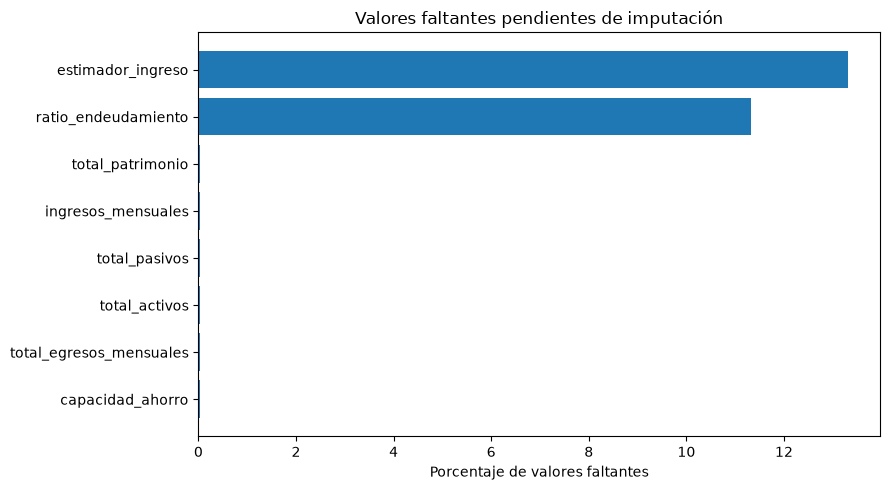

In [65]:
#### 9. Revisar los nulos pendientes

tabla_nulos_final = pd.DataFrame({
    "cantidad_nulos": df_calidad.isna().sum(),
    "porcentaje_nulos": df_calidad.isna().mean().mul(100)
})

tabla_nulos_final = (
    tabla_nulos_final
    .query("cantidad_nulos > 0")
    .sort_values("porcentaje_nulos", ascending=False)
)

tabla_nulos_final

plt.figure(figsize=(9, 5))

plt.barh(
    tabla_nulos_final.index[::-1],
    tabla_nulos_final["porcentaje_nulos"][::-1]
)

plt.title("Valores faltantes pendientes de imputación")
plt.xlabel("Porcentaje de valores faltantes")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [66]:
### 10. Guardar la tabla limpia 

df_modelo_limpio = df_calidad.copy()

df_modelo_limpio

,numero_id,grupo_edad,desc_genero,desc_segmento,desc_tipo_de_vivienda,ingresos_mensuales,total_egresos_mensuales,total_activos,total_pasivos,total_patrimonio,...,meses_activos_investbot,tiene_investbot,estimador_ingreso,total_inversiones,liquidez,total_ahorro,capacidad_ahorro,ratio_endeudamiento,num_productos_inversion,num_productos
0,8805210490649048784,65+,MASCULINO,PREFERENCIAL,SIN INFORMACION,29239444.0,30000000.0,1.450470e+11,6.356702e+09,1.054223e+08,...,0.0,0,NaN,0.000000e+00,0.0,0.0,-760556.0,0.043825,0,0
1,-5723572980375902369,50-65,MASCULINO,PREFERENCIAL,PROPIA,31024544.0,10000000.0,1.133345e+09,8.307200e+07,1.050273e+09,...,0.0,0,NaN,0.000000e+00,0.0,0.0,21024544.0,0.073298,0,0
2,-8245474570363424359,65+,MASCULINO,PREFERENCIAL,PROPIA,2834000.0,500000.0,1.073787e+09,0.000000e+00,3.430000e+08,...,0.0,0,NaN,4.502679e+08,0.0,0.0,2334000.0,0.000000,1,1
3,-7840506796880772723,65+,FEMENINO,PREFERENCIAL,PROPIA,28035850.0,0.0,1.750000e+08,0.000000e+00,5.500000e+07,...,0.0,0,NaN,0.000000e+00,0.0,0.0,28035850.0,0.000000,0,0
4,5309731180094827430,36-49,FEMENINO,PREFERENCIAL,FAMILIAR,3846205.0,2500000.0,7.580000e+08,0.000000e+00,7.580000e+08,...,0.0,0,NaN,0.000000e+00,0.0,0.0,1346205.0,0.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
860226,5882320376089669583,65+,MASCULINO,PLUS,SIN INFORMACION,5436883.0,0.0,3.055760e+08,0.000000e+00,3.055760e+08,...,0.0,0,5707416.22,0.000000e+00,0.0,0.0,5436883.0,0.000000,0,0
860227,6034010744462256034,36-49,MASCULINO,PLUS,FAMILIAR,7143835.0,4500000.0,3.173790e+08,3.500000e+07,2.823790e+08,...,0.0,0,1423500.00,0.000000e+00,0.0,0.0,2643835.0,0.110278,0,0
860228,3918722977197857898,50-65,MASCULINO,PLUS,SIN INFORMACION,7800000.0,1400000.0,3.500000e+08,1.200000e+08,2.300000e+08,...,0.0,0,NaN,0.000000e+00,0.0,0.0,6400000.0,0.342857,0,0
860229,-8439226781033547229,50-65,FEMENINO,PLUS,SIN INFORMACION,7521978.0,0.0,6.669600e+07,0.000000e+00,6.669600e+07,...,0.0,0,7226462.34,0.000000e+00,0.0,0.0,7521978.0,0.000000,0,0


## 3.X Depuración final de la tabla analítica

Como parte de la auditoría de calidad se identificaron clientes sin señales financieras ni de relacionamiento observables. Se eliminan únicamente aquellos registros que simultáneamente presentan valores nulos o iguales a cero en las variables financieras, no poseen productos financieros y no registran inversiones.

Los clientes con información financiera incompleta pero con evidencia de productos o inversiones se conservan, dado que representan observaciones válidas con cobertura parcial de información.

Adicionalmente, se estandariza el identificador `numero_id`, eliminando el signo negativo cuando corresponde, previa validación de que dicha transformación no genere colisiones entre clientes.

In [67]:
# ============================================================
# 3.X DEPURACIÓN FINAL DE LA TABLA ANALÍTICA
# ============================================================
#
# Objetivos:
#
# 1. Detectar registros sin señal financiera ni productos.
# 2. Eliminar únicamente observaciones sin información útil.
# 3. Conservar clientes con productos o inversiones aunque
#    presenten información financiera incompleta.
# 4. Estandarizar numero_id eliminando signos negativos.
# 5. Verificar que la transformación del ID no genere colisiones.
#
# IMPORTANTE:
# Este bloque debe ejecutarse ANTES del EDA ejecutivo,
# clasificación, regresión y exportación a Power BI.
# ============================================================

import numpy as np
import pandas as pd
import gc


# ============================================================
# 1. INFORMACIÓN INICIAL
# ============================================================

n_original = len(df_modelo_limpio)

clientes_unicos_original = (
    df_modelo_limpio["numero_id"]
    .nunique()
)

print("=" * 80)
print("DEPURACIÓN FINAL DE LA TABLA ANALÍTICA")
print("=" * 80)

print(
    f"Registros iniciales: {n_original:,}"
)

print(
    f"Clientes únicos iniciales: "
    f"{clientes_unicos_original:,}"
)


# ============================================================
# 2. VARIABLES FINANCIERAS A EVALUAR
# ============================================================

variables_financieras_calidad = [

    "ingresos_mensuales",
    "total_egresos_mensuales",
    "estimador_ingreso",
    "capacidad_ahorro",
    "liquidez",

    "total_activos",
    "total_pasivos",
    "total_patrimonio",

    "saldo_actual_ahorro",
    "saldo_promedio_ahorro",
    "saldo_minimo_ahorro",
    "saldo_maximo_ahorro",

    "saldo_actual_bolsillo",
    "saldo_promedio_bolsillo",
    "saldo_minimo_bolsillo",
    "saldo_maximo_bolsillo"

]


variables_financieras_calidad = [

    columna

    for columna in variables_financieras_calidad

    if columna in df_modelo_limpio.columns

]


if len(variables_financieras_calidad) == 0:

    raise ValueError(
        "No se encontraron variables financieras "
        "para realizar la auditoría."
    )


print(
    f"\nVariables financieras evaluadas: "
    f"{len(variables_financieras_calidad)}"
)

print(
    variables_financieras_calidad
)


# ============================================================
# 3. VARIABLES DE PRODUCTOS
# ============================================================

variables_productos_calidad = [

    "tiene_cta_ahorro",
    "tiene_cta_corriente",
    "tiene_bolsillos",

    "tiene_fiducuenta",
    "tiene_investbot",
    "tiene_cdt",
    "tiene_inversion_virtual"

]


variables_productos_calidad = [

    columna

    for columna in variables_productos_calidad

    if columna in df_modelo_limpio.columns

]


if len(variables_productos_calidad) == 0:

    raise ValueError(
        "No se encontraron variables de productos "
        "para realizar la auditoría."
    )


print(
    f"\nProductos evaluados: "
    f"{len(variables_productos_calidad)}"
)

print(
    variables_productos_calidad
)


# ============================================================
# 4. CLIENTES SIN INFORMACIÓN FINANCIERA
# ============================================================
#
# Versión optimizada en memoria:
# evaluamos columna por columna.
#
# Un cliente queda marcado cuando TODAS las variables
# financieras son 0 o NaN.
# ============================================================

mask_financieras_cero = pd.Series(

    True,

    index=df_modelo_limpio.index,

    dtype=bool

)


for columna in variables_financieras_calidad:

    serie_temporal = pd.to_numeric(

        df_modelo_limpio[columna],

        errors="coerce"

    )


    mask_financieras_cero &= (

        serie_temporal
        .fillna(0)
        .eq(0)

    )


    del serie_temporal


gc.collect()


n_financieras_cero = int(
    mask_financieras_cero.sum()
)


print(
    "\nClientes con todas las variables "
    f"financieras en cero: "
    f"{n_financieras_cero:,}"
)


# ============================================================
# 5. CLIENTES SIN PRODUCTOS
# ============================================================

mask_productos_cero = pd.Series(

    True,

    index=df_modelo_limpio.index,

    dtype=bool

)


for columna in variables_productos_calidad:

    serie_temporal = pd.to_numeric(

        df_modelo_limpio[columna],

        errors="coerce"

    )


    mask_productos_cero &= (

        serie_temporal
        .fillna(0)
        .eq(0)

    )


    del serie_temporal


gc.collect()


n_productos_cero = int(
    mask_productos_cero.sum()
)


print(
    "Clientes sin ningún producto: "
    f"{n_productos_cero:,}"
)


# ============================================================
# 6. CLIENTES SIN INVERSIÓN
# ============================================================

if "total_inversiones" not in df_modelo_limpio.columns:

    raise KeyError(
        "No existe la columna total_inversiones."
    )


serie_inversion = pd.to_numeric(

    df_modelo_limpio[
        "total_inversiones"
    ],

    errors="coerce"

)


mask_inversion_cero = (

    serie_inversion
    .fillna(0)
    .eq(0)

)


del serie_inversion

gc.collect()


n_inversion_cero = int(
    mask_inversion_cero.sum()
)


print(
    "Clientes sin inversión: "
    f"{n_inversion_cero:,}"
)


# ============================================================
# 7. REGLA FINAL DE DEPURACIÓN
# ============================================================
#
# Se elimina únicamente cuando el cliente cumple
# simultáneamente:
#
# - todas las variables financieras = 0 / NaN
# - todos los productos = 0 / NaN
# - total_inversiones = 0 / NaN
#
# No usamos género, edad o segmento como criterio.
# ============================================================

mask_registro_sin_senal = (

    mask_financieras_cero

    &

    mask_productos_cero

    &

    mask_inversion_cero

)


n_eliminar = int(
    mask_registro_sin_senal.sum()
)


porcentaje_eliminar = (

    n_eliminar
    / n_original
    * 100

)


print("\n" + "=" * 80)
print("REGISTROS CANDIDATOS A ELIMINACIÓN")
print("=" * 80)

print(
    f"Registros: {n_eliminar:,}"
)

print(
    f"Porcentaje de la base: "
    f"{porcentaje_eliminar:.4f}%"
)


# ============================================================
# 8. AUDITORÍA DE UNA MUESTRA
# ============================================================

columnas_revision = [

    "numero_id",

    "grupo_edad",
    "desc_genero",
    "desc_segmento",
    "desc_tipo_de_vivienda",

    "ingresos_mensuales",
    "estimador_ingreso",
    "total_egresos_mensuales",

    "total_activos",
    "total_pasivos",
    "total_patrimonio",

    "saldo_promedio_ahorro",
    "saldo_promedio_bolsillo",

    "tiene_cta_ahorro",
    "tiene_cta_corriente",
    "tiene_bolsillos",

    "tiene_fiducuenta",
    "tiene_investbot",
    "tiene_cdt",
    "tiene_inversion_virtual",

    "total_inversiones"

]


columnas_revision = [

    columna

    for columna in columnas_revision

    if columna in df_modelo_limpio.columns

]


print(
    "\nMuestra de registros candidatos:"
)


display(

    df_modelo_limpio.loc[
        mask_registro_sin_senal,
        columnas_revision
    ]
    .head(20)

)


# ============================================================
# 9. CONTROL DE SEGURIDAD ANTES DE ELIMINAR
# ============================================================
#
# Verificamos que estos registros no tengan:
# - inversión
# - productos
#
# ============================================================

inversion_eliminada = (

    pd.to_numeric(

        df_modelo_limpio.loc[
            mask_registro_sin_senal,
            "total_inversiones"
        ],

        errors="coerce"

    )

    .fillna(0)

    .sum()

)


productos_eliminados = 0


for columna in variables_productos_calidad:

    productos_eliminados += (

        pd.to_numeric(

            df_modelo_limpio.loc[
                mask_registro_sin_senal,
                columna
            ],

            errors="coerce"

        )

        .fillna(0)

        .sum()

    )


print("\n" + "=" * 80)
print("CONTROL PREVIO A LA ELIMINACIÓN")
print("=" * 80)

print(
    f"Inversión total de candidatos: "
    f"${inversion_eliminada:,.0f}"
)

print(
    f"Indicadores de productos de candidatos: "
    f"{productos_eliminados:,.0f}"
)


if (

    inversion_eliminada != 0

    or

    productos_eliminados != 0

):

    raise ValueError(

        "La regla identificó registros con actividad. "
        "No se realizará la eliminación."

    )


print(
    "\n✅ Los registros candidatos no tienen "
    "productos ni inversión."
)


# ============================================================
# 10. ELIMINAR REGISTROS SIN SEÑAL
# ============================================================

df_modelo_limpio = (

    df_modelo_limpio.loc[
        ~mask_registro_sin_senal
    ]

    .copy()

    .reset_index(
        drop=True
    )

)


# Liberar máscaras anteriores
del mask_financieras_cero
del mask_productos_cero
del mask_inversion_cero
del mask_registro_sin_senal

gc.collect()


# ============================================================
# 11. PREPARAR numero_id
# ============================================================

df_modelo_limpio[
    "numero_id"
] = pd.to_numeric(

    df_modelo_limpio[
        "numero_id"
    ],

    errors="raise"

)


n_ids_negativos = int(

    (
        df_modelo_limpio[
            "numero_id"
        ] < 0
    )
    .sum()

)


print("\n" + "=" * 80)
print("AUDITORÍA DE numero_id")
print("=" * 80)

print(
    f"IDs negativos encontrados: "
    f"{n_ids_negativos:,}"
)


# ============================================================
# 12. VALIDAR COLISIONES AL QUITAR EL SIGNO
# ============================================================
#
# Riesgo:
#
# -123
#  123
#
# Ambos se transformarían en 123.
#
# ============================================================

if n_ids_negativos > 0:

    # Trabajamos solo con los IDs.
    ids_originales = (

        df_modelo_limpio[
            "numero_id"
        ]
        .to_numpy(
            copy=True
        )

    )


    ids_absolutos = (
        np.abs(
            ids_originales
        )
    )


    # --------------------------------------------------------
    # Detectar si un mismo valor absoluto proviene
    # de IDs originales diferentes.
    # --------------------------------------------------------

    auditoria_ids = pd.DataFrame({

        "numero_id_original":
            ids_originales,

        "numero_id_absoluto":
            ids_absolutos

    })


    colisiones_id = (

        auditoria_ids

        .groupby(
            "numero_id_absoluto",
            sort=False
        )[
            "numero_id_original"
        ]

        .nunique()

    )


    colisiones_id = (

        colisiones_id[
            colisiones_id > 1
        ]

    )


    n_colisiones = len(
        colisiones_id
    )


    print(
        f"Posibles colisiones encontradas: "
        f"{n_colisiones:,}"
    )


    if n_colisiones > 0:

        print(
            "\n⚠️ NO se modificó numero_id."
        )

        print(
            "Existen identificadores positivos y negativos "
            "que terminarían con el mismo valor."
        )


        display(

            colisiones_id
            .head(20)
            .to_frame(
                "Cantidad_ID_originales"
            )

        )


        raise ValueError(

            "Revisar las colisiones de numero_id "
            "antes de continuar."

        )


    # --------------------------------------------------------
    # Aplicar valor absoluto
    # --------------------------------------------------------

    df_modelo_limpio[
        "numero_id"
    ] = ids_absolutos


    del ids_originales
    del ids_absolutos
    del auditoria_ids
    del colisiones_id

    gc.collect()


    print(
        "✅ numero_id estandarizado correctamente."
    )


else:

    print(
        "✅ No existen IDs negativos."
    )


# ============================================================
# 13. VALIDACIONES FINALES
# ============================================================

n_final = len(
    df_modelo_limpio
)


n_eliminados_real = (

    n_original
    - n_final

)


clientes_unicos_final = (

    df_modelo_limpio[
        "numero_id"
    ]

    .nunique()

)


ids_negativos_finales = int(

    (
        df_modelo_limpio[
            "numero_id"
        ] < 0
    )
    .sum()

)


ids_duplicados_finales = int(

    df_modelo_limpio[
        "numero_id"
    ]

    .duplicated()

    .sum()

)


print("\n" + "=" * 80)
print("RESULTADO FINAL DE LA DEPURACIÓN")
print("=" * 80)


print(
    f"Registros originales     : "
    f"{n_original:,}"
)

print(
    f"Registros eliminados     : "
    f"{n_eliminados_real:,}"
)

print(
    f"Registros finales        : "
    f"{n_final:,}"
)

print(
    f"Reducción de la base     : "
    f"{(n_eliminados_real / n_original * 100):.4f}%"
)

print(
    f"Clientes únicos iniciales: "
    f"{clientes_unicos_original:,}"
)

print(
    f"Clientes únicos finales  : "
    f"{clientes_unicos_final:,}"
)

print(
    f"IDs negativos finales    : "
    f"{ids_negativos_finales:,}"
)

print(
    f"IDs duplicados finales   : "
    f"{ids_duplicados_finales:,}"
)


# ============================================================
# 14. RESULTADO
# ============================================================

print("\n" + "=" * 80)

print(
    "✅ DEPURACIÓN FINAL COMPLETADA"
)

print("=" * 80)

print(
    "\nLa variable df_modelo_limpio ya contiene "
    "la población depurada."
)

print(
    "Ejecuta nuevamente desde la sección 3.8 "
    "hacia adelante."
)

DEPURACIÓN FINAL DE LA TABLA ANALÍTICA
Registros iniciales: 860,223
Clientes únicos iniciales: 860,223

Variables financieras evaluadas: 16
['ingresos_mensuales', 'total_egresos_mensuales', 'estimador_ingreso', 'capacidad_ahorro', 'liquidez', 'total_activos', 'total_pasivos', 'total_patrimonio', 'saldo_actual_ahorro', 'saldo_promedio_ahorro', 'saldo_minimo_ahorro', 'saldo_maximo_ahorro', 'saldo_actual_bolsillo', 'saldo_promedio_bolsillo', 'saldo_minimo_bolsillo', 'saldo_maximo_bolsillo']

Productos evaluados: 7
['tiene_cta_ahorro', 'tiene_cta_corriente', 'tiene_bolsillos', 'tiene_fiducuenta', 'tiene_investbot', 'tiene_cdt', 'tiene_inversion_virtual']

Clientes con todas las variables financieras en cero: 5,038
Clientes sin ningún producto: 329,583
Clientes sin inversión: 639,903

REGISTROS CANDIDATOS A ELIMINACIÓN
Registros: 4,856
Porcentaje de la base: 0.5645%

Muestra de registros candidatos:


,numero_id,grupo_edad,desc_genero,desc_segmento,desc_tipo_de_vivienda,ingresos_mensuales,estimador_ingreso,total_egresos_mensuales,total_activos,total_pasivos,...,saldo_promedio_ahorro,saldo_promedio_bolsillo,tiene_cta_ahorro,tiene_cta_corriente,tiene_bolsillos,tiene_fiducuenta,tiene_investbot,tiene_cdt,tiene_inversion_virtual,total_inversiones
84336,-5562364488999172595,36-49,FEMENINO,PERSONAL,SIN INFORMACION,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0,0,0,0,0,0,0,0.0
140076,-6290743265670435264,26-35,FEMENINO,PERSONAL,SIN INFORMACION,0.0,NaN,0.0,0.0,0.0,...,0.0,0.0,0,0,0,0,0,0,0,0.0
157351,-8183379128870361398,18-25,FEMENINO,PERSONAL,SIN INFORMACION,0.0,NaN,0.0,0.0,0.0,...,0.0,0.0,0,0,0,0,0,0,0,0.0
164990,-6692605154959274492,18-25,MASCULINO,PERSONAL,SIN INFORMACION,0.0,NaN,0.0,0.0,0.0,...,0.0,0.0,0,0,0,0,0,0,0,0.0
185679,-8167549982942925263,26-35,MASCULINO,PERSONAL,SIN INFORMACION,0.0,NaN,0.0,0.0,0.0,...,0.0,0.0,0,0,0,0,0,0,0,0.0
190628,-8157308514353748438,36-49,FEMENINO,PERSONAL,SIN INFORMACION,0.0,NaN,0.0,0.0,0.0,...,0.0,0.0,0,0,0,0,0,0,0,0.0
218793,-7065373411886580699,18-25,FEMENINO,PERSONAL,SIN INFORMACION,0.0,NaN,0.0,0.0,0.0,...,0.0,0.0,0,0,0,0,0,0,0,0.0
220296,8975399184409392887,18-25,MASCULINO,PERSONAL,SIN INFORMACION,0.0,NaN,0.0,0.0,0.0,...,0.0,0.0,0,0,0,0,0,0,0,0.0
221228,7438078533652092235,36-49,MASCULINO,PLUS,SIN INFORMACION,0.0,NaN,0.0,0.0,0.0,...,0.0,0.0,0,0,0,0,0,0,0,0.0
237530,340228646643665341,18-25,FEMENINO,PERSONAL,SIN INFORMACION,0.0,NaN,0.0,0.0,0.0,...,0.0,0.0,0,0,0,0,0,0,0,0.0



CONTROL PREVIO A LA ELIMINACIÓN
Inversión total de candidatos: $0
Indicadores de productos de candidatos: 0

✅ Los registros candidatos no tienen productos ni inversión.

AUDITORÍA DE numero_id
IDs negativos encontrados: 426,745
Posibles colisiones encontradas: 0
✅ numero_id estandarizado correctamente.

RESULTADO FINAL DE LA DEPURACIÓN
Registros originales     : 860,223
Registros eliminados     : 4,856
Registros finales        : 855,367
Reducción de la base     : 0.5645%
Clientes únicos iniciales: 860,223
Clientes únicos finales  : 855,367
IDs negativos finales    : 0
IDs duplicados finales   : 0

✅ DEPURACIÓN FINAL COMPLETADA

La variable df_modelo_limpio ya contiene la población depurada.
Ejecuta nuevamente desde la sección 3.8 hacia adelante.


## 3.8 Caracterización ejecutiva de la población

Esta sección resume visualmente las principales características de los clientes antes de introducir los modelos predictivos.

El objetivo es responder de manera directa:

- ¿Cómo se distribuyen los clientes por edad?
- ¿Qué segmentos comerciales concentran la población?
- ¿Cómo se compone la población por género?
- ¿Cuál es el perfil financiero típico del cliente?
- ¿Qué productos financieros presentan mayor penetración?

Las visualizaciones se presentan en un formato ejecutivo, priorizando interpretabilidad y facilidad de lectura sobre detalle estadístico.

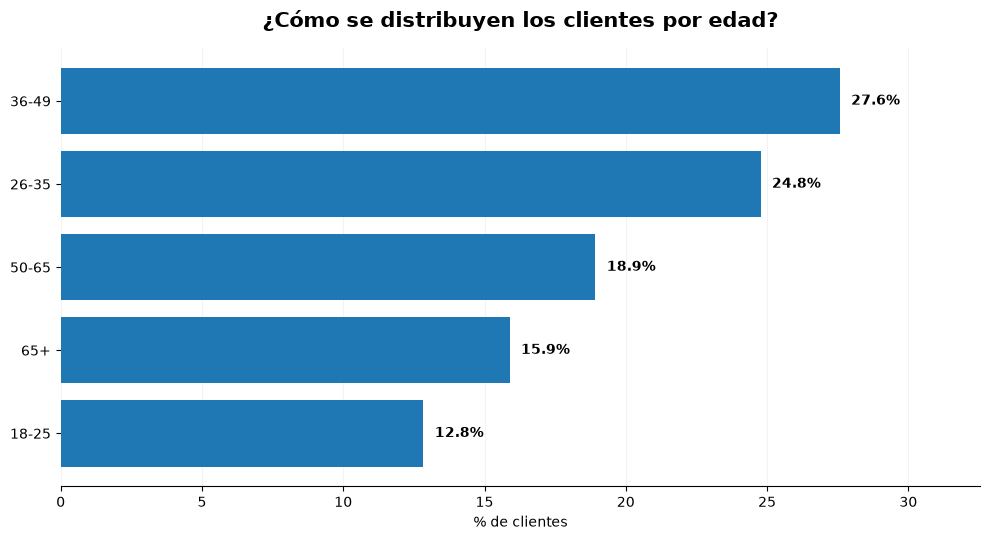

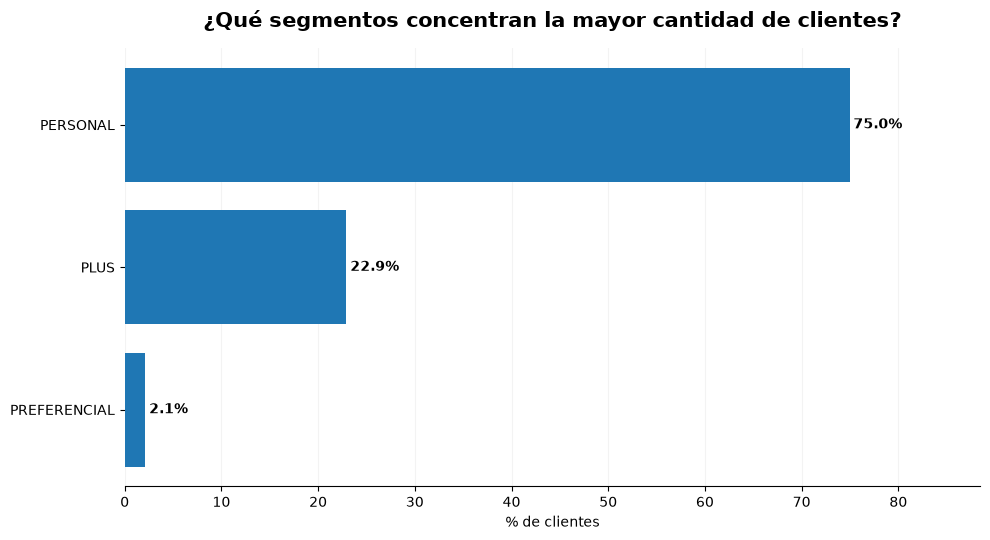

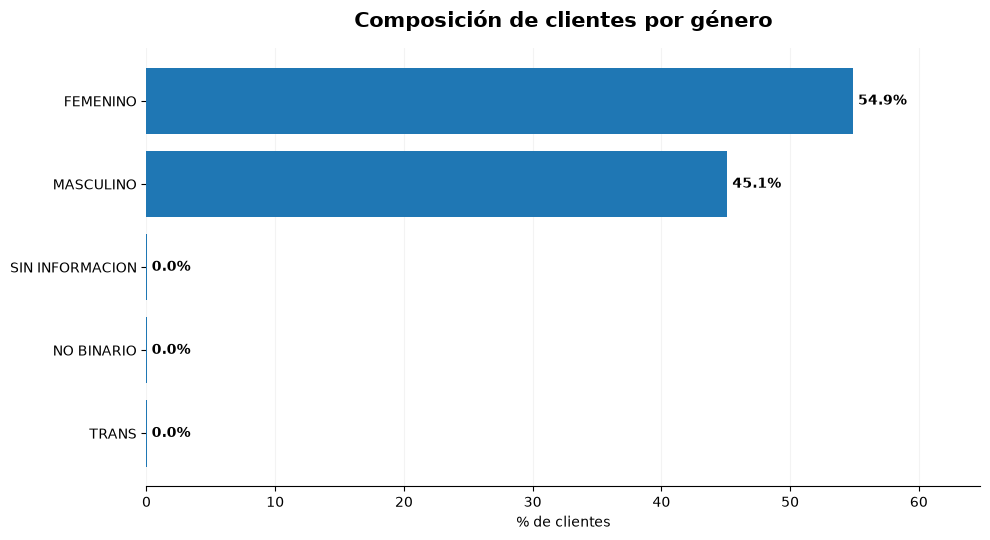

PERFIL FINANCIERO DEL CLIENTE TÍPICO


,Variable,Mediana,Q1,Q3
0,Ingresos mensuales,$2.0 M,$1.3 M,$4.9 M
1,Activos,$11.2 M,$1.2 M,$67.7 M
2,Pasivos,$0,$0,$1
3,Patrimonio,$7.2 M,$176.5 mil,$48.0 M
4,Liquidez,$108,$0,$985.9 mil


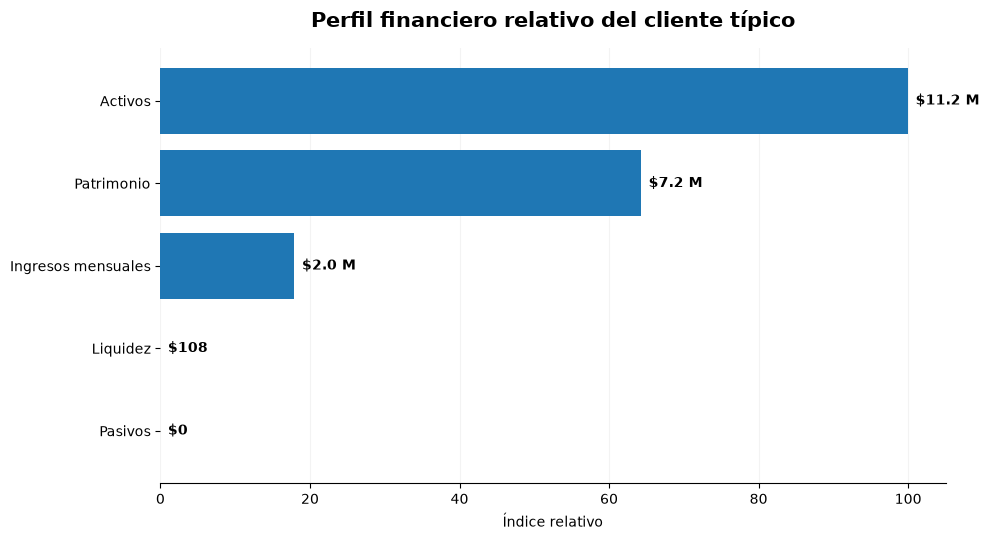

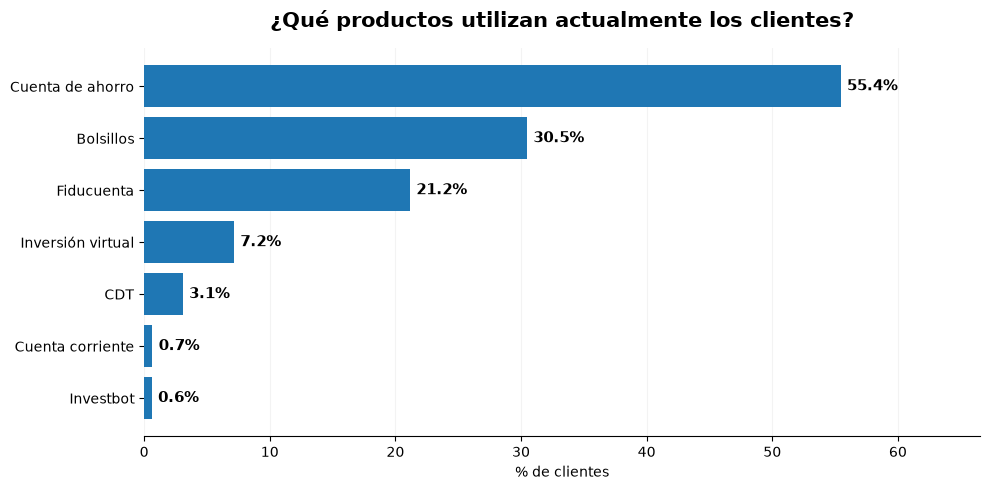


✅ Caracterización ejecutiva completada.


In [68]:
# ============================================================
# 3.8 CARACTERIZACIÓN EJECUTIVA DE LA POBLACIÓN
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


df_viz = df_modelo_limpio.copy()


# ============================================================
# FUNCIONES AUXILIARES
# ============================================================

def formato_dinero(valor):
    """
    Formatea valores monetarios para presentación.
    """

    if pd.isna(valor):
        return "-"

    valor_abs = abs(valor)

    if valor_abs >= 1_000_000_000:
        return f"${valor / 1_000_000_000:,.1f} mil M"

    elif valor_abs >= 1_000_000:
        return f"${valor / 1_000_000:,.1f} M"

    elif valor_abs >= 1_000:
        return f"${valor / 1_000:,.1f} mil"

    else:
        return f"${valor:,.0f}"


def grafico_porcentaje(
    dataframe,
    columna,
    titulo,
    orden=None,
    top_n=None
):
    """
    Gráfico horizontal de distribución porcentual.
    """

    serie = (
        dataframe[columna]
        .fillna("Sin información")
        .astype(str)
        .value_counts()
    )

    if orden is not None:

        orden_disponible = [
            valor
            for valor in orden
            if valor in serie.index
        ]

        otros = [
            valor
            for valor in serie.index
            if valor not in orden_disponible
        ]

        serie = serie.reindex(
            orden_disponible + otros
        )

    if top_n is not None:
        serie = serie.head(top_n)

    porcentaje = (
        serie
        / serie.sum()
        * 100
    )

    porcentaje = porcentaje.sort_values()

    fig, ax = plt.subplots(
        figsize=(10, 5.5)
    )

    barras = ax.barh(
        porcentaje.index,
        porcentaje.values
    )

    ax.set_title(
        titulo,
        fontsize=15,
        fontweight="bold",
        pad=15
    )

    ax.set_xlabel(
        "% de clientes"
    )

    ax.set_ylabel("")

    ax.spines[
        ["top", "right", "left"]
    ].set_visible(False)

    ax.grid(
        axis="x",
        alpha=0.15
    )

    ax.set_axisbelow(True)

    for barra, valor in zip(
        barras,
        porcentaje.values
    ):

        ax.text(
            valor + 0.4,
            barra.get_y()
            + barra.get_height() / 2,
            f"{valor:.1f}%",
            va="center",
            fontsize=10,
            fontweight="bold"
        )

    ax.set_xlim(
        0,
        max(porcentaje.values) * 1.18
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 1. DISTRIBUCIÓN POR EDAD
# ============================================================

if "grupo_edad" in df_viz.columns:

    orden_edades = [
        "18-25",
        "26-35",
        "36-49",
        "50-65",
        "65+"
    ]

    grafico_porcentaje(
        dataframe=df_viz,
        columna="grupo_edad",
        titulo="¿Cómo se distribuyen los clientes por edad?",
        orden=orden_edades
    )


# ============================================================
# 2. DISTRIBUCIÓN POR SEGMENTO COMERCIAL
# ============================================================

if "desc_segmento" in df_viz.columns:

    grafico_porcentaje(
        dataframe=df_viz,
        columna="desc_segmento",
        titulo="¿Qué segmentos concentran la mayor cantidad de clientes?",
        top_n=10
    )


# ============================================================
# 3. DISTRIBUCIÓN POR GÉNERO
# ============================================================

if "desc_genero" in df_viz.columns:

    grafico_porcentaje(
        dataframe=df_viz,
        columna="desc_genero",
        titulo="Composición de clientes por género"
    )


# ============================================================
# 4. PERFIL FINANCIERO TÍPICO
# ============================================================
#
# En lugar de boxplots logarítmicos difíciles de interpretar,
# utilizamos MEDIANAS.
#
# La mediana representa mejor al cliente típico cuando existen
# valores extremos.
# ============================================================

variables_financieras = {

    "ingresos_mensuales":
        "Ingresos mensuales",

    "total_activos":
        "Activos",

    "total_pasivos":
        "Pasivos",

    "total_patrimonio":
        "Patrimonio",

    "liquidez":
        "Liquidez"

}


variables_disponibles = {
    columna: etiqueta
    for columna, etiqueta
    in variables_financieras.items()
    if columna in df_viz.columns
}


if variables_disponibles:

    resumen_financiero = []

    for columna, etiqueta in (
        variables_disponibles.items()
    ):

        serie = pd.to_numeric(
            df_viz[columna],
            errors="coerce"
        )

        serie = serie.replace(
            [np.inf, -np.inf],
            np.nan
        )

        mediana = serie.median()

        q1 = serie.quantile(0.25)
        q3 = serie.quantile(0.75)

        resumen_financiero.append({

            "Variable": etiqueta,

            "Mediana": mediana,

            "Q1": q1,

            "Q3": q3

        })


    resumen_financiero = pd.DataFrame(
        resumen_financiero
    )


    print("=" * 70)
    print("PERFIL FINANCIERO DEL CLIENTE TÍPICO")
    print("=" * 70)

    resumen_financiero_presentacion = (
        resumen_financiero.copy()
    )

    for columna in [
        "Mediana",
        "Q1",
        "Q3"
    ]:

        resumen_financiero_presentacion[
            columna
        ] = (
            resumen_financiero_presentacion[
                columna
            ]
            .map(formato_dinero)
        )


    display(
        resumen_financiero_presentacion
    )


# ============================================================
# 5. PERFIL FINANCIERO RELATIVO
# ============================================================
#
# Para poder comparar magnitudes muy diferentes se normaliza
# cada mediana respecto al valor máximo.
#
# El objetivo NO es comparar pesos directamente, sino mostrar
# visualmente la estructura financiera del cliente típico.
# ============================================================

if variables_disponibles:

    perfil_relativo = (
        resumen_financiero[
            ["Variable", "Mediana"]
        ]
        .copy()
    )

    maximo = (
        perfil_relativo[
            "Mediana"
        ]
        .abs()
        .max()
    )

    if maximo > 0:

        perfil_relativo[
            "Valor_relativo"
        ] = (
            perfil_relativo[
                "Mediana"
            ]
            / maximo
            * 100
        )

        perfil_relativo = (
            perfil_relativo
            .sort_values(
                "Valor_relativo"
            )
        )


        fig, ax = plt.subplots(
            figsize=(10, 5.5)
        )

        barras = ax.barh(
            perfil_relativo[
                "Variable"
            ],
            perfil_relativo[
                "Valor_relativo"
            ]
        )


        ax.set_title(
            "Perfil financiero relativo del cliente típico",
            fontsize=15,
            fontweight="bold",
            pad=15
        )


        ax.set_xlabel(
            "Índice relativo"
        )

        ax.set_ylabel("")


        ax.spines[
            ["top", "right", "left"]
        ].set_visible(False)


        ax.grid(
            axis="x",
            alpha=0.15
        )

        ax.set_axisbelow(True)


        # Mostrar monto real junto a cada barra.
        mapa_mediana = dict(
            zip(
                resumen_financiero[
                    "Variable"
                ],
                resumen_financiero[
                    "Mediana"
                ]
            )
        )


        for barra, variable in zip(
            barras,
            perfil_relativo[
                "Variable"
            ]
        ):

            valor_real = (
                mapa_mediana[
                    variable
                ]
            )

            ax.text(
                barra.get_width() + 1,
                barra.get_y()
                + barra.get_height() / 2,
                formato_dinero(
                    valor_real
                ),
                va="center",
                fontsize=10,
                fontweight="bold"
            )


        plt.tight_layout()
        plt.show()


# ============================================================
# 6. TENENCIA DE PRODUCTOS
# ============================================================


productos = {

    "tiene_cta_ahorro":
        "Cuenta de ahorro",

    "tiene_bolsillos":
        "Bolsillos",

    "tiene_cta_corriente":
        "Cuenta corriente",

    "tiene_fiducuenta":
        "Fiducuenta",

    "tiene_investbot":
        "Investbot",

    "tiene_cdt":
        "CDT",

    "tiene_inversion_virtual":
        "Inversión virtual"

}



productos_disponibles = {
    columna: etiqueta
    for columna, etiqueta
    in productos.items()
    if columna in df_viz.columns
}


if productos_disponibles:

    penetracion = {}

    for columna, etiqueta in (
        productos_disponibles.items()
    ):

        serie = pd.to_numeric(
            df_viz[columna],
            errors="coerce"
        )

        penetracion[
            etiqueta
        ] = serie.mean() * 100


    penetracion = (
        pd.Series(
            penetracion
        )
        .sort_values()
    )


    fig, ax = plt.subplots(
        figsize=(10, 5)
    )


    barras = ax.barh(
        penetracion.index,
        penetracion.values
    )


    ax.set_title(
        "¿Qué productos utilizan actualmente los clientes?",
        fontsize=15,
        fontweight="bold",
        pad=15
    )


    ax.set_xlabel(
        "% de clientes"
    )

    ax.set_ylabel("")


    ax.spines[
        ["top", "right", "left"]
    ].set_visible(False)


    ax.grid(
        axis="x",
        alpha=0.15
    )

    ax.set_axisbelow(True)


    for barra, valor in zip(
        barras,
        penetracion.values
    ):

        ax.text(
            valor + 0.5,
            barra.get_y()
            + barra.get_height() / 2,
            f"{valor:.1f}%",
            va="center",
            fontsize=11,
            fontweight="bold"
        )


    ax.set_xlim(
        0,
        max(penetracion.values) * 1.20
    )


    plt.tight_layout()
    plt.show()


print(
    "\n✅ Caracterización ejecutiva completada."
)

# 4. Identificación de clientes potenciales para inversión

Esta sección responde la primera pregunta predictiva del negocio:

> **¿Qué clientes presentan características asociadas con ser inversionistas?**

Se construye un problema de clasificación binaria para diferenciar inversionistas y no inversionistas, evaluando desempeño, estabilidad e interpretabilidad. La finalidad no es únicamente clasificar, sino comprender qué variables distinguen ambos perfiles.

## 4.1 Definición del problema de clasificación

Se construye y valida la variable objetivo que distingue entre clientes inversionistas y no inversionistas. Antes del modelado se revisa su distribución para identificar posibles desbalances y definir métricas de evaluación adecuadas.

Distribución de la variable objetivo:


,Clientes,Porcentaje
No inversionista,634915,74.23
Inversionista,220452,25.77


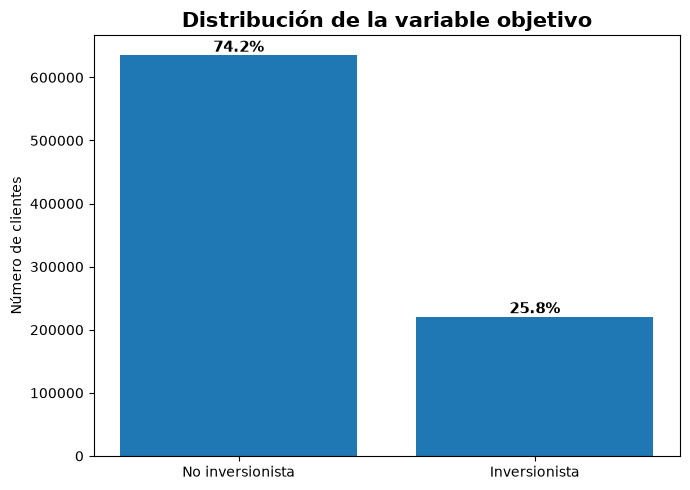

In [69]:
# ============================================================
# 4.1 CONSTRUCCIÓN Y VALIDACIÓN DE LA VARIABLE OBJETIVO
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Productos que representan experiencia actual en inversión.
productos_inversion = [
    "tiene_fiducuenta",
    "tiene_inversion_virtual",
    "tiene_cdt",
    "tiene_investbot"
]

# El target vale 1 cuando el cliente posee al menos uno de los
# productos anteriores. Representa una aproximación a la afinidad
# inversionista, no una adopción real observada de la nueva App.
df_modelo_limpio["es_inversionista"] = (
    df_modelo_limpio[productos_inversion]
    .sum(axis=1)
    .gt(0)
    .astype("int8")
)

# Variable de relacionamiento que excluye productos de inversión.
# Esta sí puede utilizarse posteriormente como predictor.
df_modelo_limpio["num_productos_no_inversion"] = (
    df_modelo_limpio[
        [
            "tiene_bolsillos",
            "tiene_cta_ahorro",
            "tiene_cta_corriente"
        ]
    ]
    .sum(axis=1)
    .astype("int8")
)

# Tabla de distribución del target.
distribucion_target = pd.DataFrame({
    "Clientes": (
        df_modelo_limpio["es_inversionista"]
        .value_counts()
        .sort_index()
    ),
    "Porcentaje": (
        df_modelo_limpio["es_inversionista"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
    )
})

distribucion_target.index = [
    "No inversionista",
    "Inversionista"
]

print("Distribución de la variable objetivo:")
display(distribucion_target.round(2))

# Gráfico ejecutivo.
fig, ax = plt.subplots(figsize=(7, 5))

barras = ax.bar(
    distribucion_target.index,
    distribucion_target["Clientes"]
)

for barra, porcentaje in zip(
    barras,
    distribucion_target["Porcentaje"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height(),
        f"{porcentaje:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.set_title(
    "Distribución de la variable objetivo",
    fontsize=15,
    fontweight="bold"
)
ax.set_ylabel("Número de clientes")
ax.set_xlabel("")
plt.tight_layout()
plt.show()


## 4.2 Caracterización demográfica de inversionistas y no inversionistas

Se comparan ambos grupos desde variables demográficas para identificar patrones preliminares de edad, género, segmento y otras características disponibles.

Perfil demográfico predominante:


Grupo,Característica,Inversionista,No inversionista
0,Grupo de edad,36-49,36-49
1,Género,FEMENINO,FEMENINO
2,Segmento,PLUS,PERSONAL
3,Tipo de vivienda,SIN INFORMACION,SIN INFORMACION


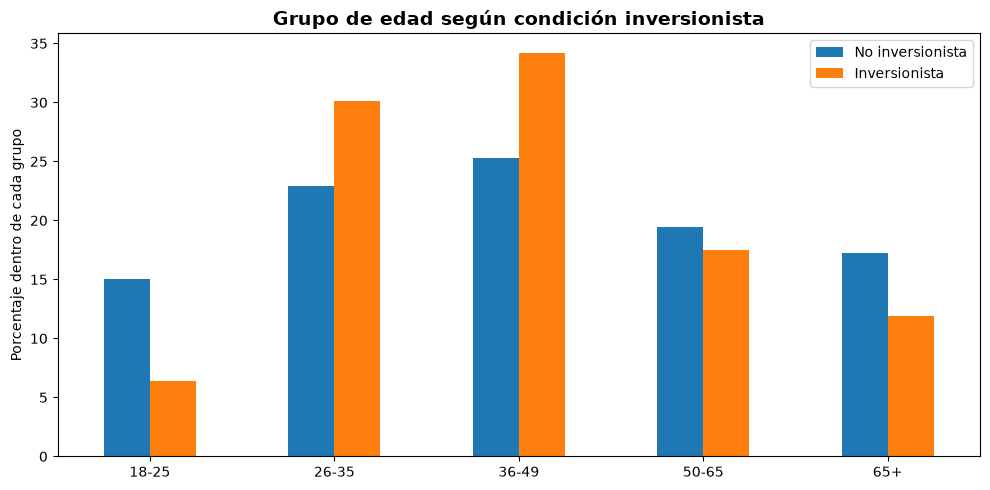

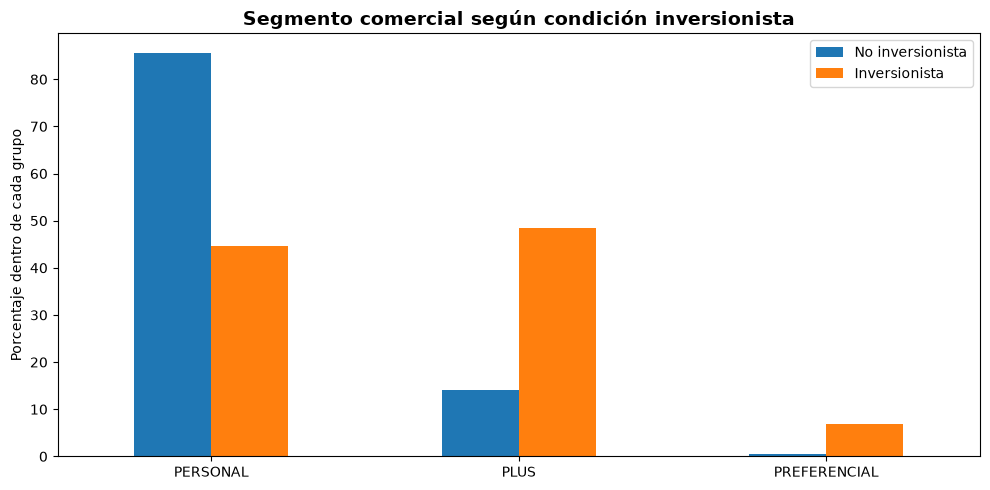

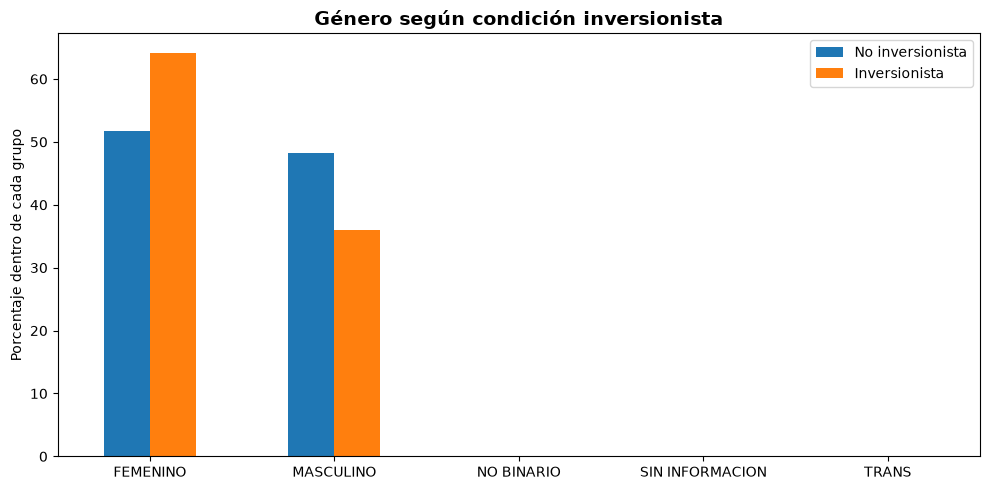

In [70]:
# ============================================================
# 4.2 PERFIL DEMOGRÁFICO POR CONDICIÓN INVERSIONISTA
# ============================================================

variables_demograficas = {
    "grupo_edad": "Grupo de edad",
    "desc_segmento": "Segmento",
    "desc_genero": "Género",
    "desc_tipo_de_vivienda": "Tipo de vivienda"
}

resumen_demografico = []

for variable, nombre in variables_demograficas.items():
    for clase, etiqueta in [(0, "No inversionista"), (1, "Inversionista")]:
        serie = df_modelo_limpio.loc[
            df_modelo_limpio["es_inversionista"] == clase,
            variable
        ].dropna()

        categoria_predominante = (
            serie.mode().iloc[0]
            if not serie.empty
            else "SIN INFORMACION"
        )

        participacion = (
            serie.eq(categoria_predominante).mean() * 100
            if not serie.empty
            else np.nan
        )

        resumen_demografico.append({
            "Característica": nombre,
            "Grupo": etiqueta,
            "Categoría predominante": categoria_predominante,
            "Participación dentro del grupo (%)": participacion
        })

perfil_demografico_largo = pd.DataFrame(resumen_demografico)

perfil_demografico = (
    perfil_demografico_largo
    .pivot(
        index="Característica",
        columns="Grupo",
        values="Categoría predominante"
    )
    .reset_index()
)

print("Perfil demográfico predominante:")
display(perfil_demografico)

# Distribuciones porcentuales por clase para las variables más útiles.
for variable, titulo in {
    "grupo_edad": "Grupo de edad",
    "desc_segmento": "Segmento comercial",
    "desc_genero": "Género"
}.items():
    tabla = pd.crosstab(
        df_modelo_limpio[variable],
        df_modelo_limpio["es_inversionista"],
        normalize="columns"
    ).mul(100)

    tabla.columns = ["No inversionista", "Inversionista"]

    ax = tabla.plot(
        kind="bar",
        figsize=(10, 5)
    )
    ax.set_title(
        f"{titulo} según condición inversionista",
        fontsize=14,
        fontweight="bold"
    )
    ax.set_ylabel("Porcentaje dentro de cada grupo")
    ax.set_xlabel("")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


## 4.3 Caracterización financiera y relacionamiento no inversionista

Se analizan variables financieras, patrimoniales, de ahorro y relacionamiento con productos no inversionistas para determinar qué diferencias existen entre clientes inversionistas y no inversionistas.

Perfil financiero comparativo:


,Característica,Variable,No inversionista (mediana),Inversionista (mediana),Diferencia (%)
0,Ingresos mensuales,ingresos_mensuales,1754748.00,5108387.00,191.12
1,Patrimonio,total_patrimonio,3027491.00,33973113.00,1022.15
2,Activos,total_activos,5000000.00,58576200.00,1071.52
3,Pasivos,total_pasivos,0.00,0.00,NaN
4,Liquidez,liquidez,0.00,1535927.45,NaN
5,Ahorro total,total_ahorro,0.00,1875683.70,NaN
6,Capacidad de ahorro,capacidad_ahorro,1280171.00,4215009.00,229.25
7,Ratio de endeudamiento,ratio_endeudamiento,0.00,0.00,NaN
8,Estimador de ingreso,estimador_ingreso,2057914.72,5382988.73,161.57
9,Productos no inversionistas,num_productos_no_inversion,0.00,2.00,NaN


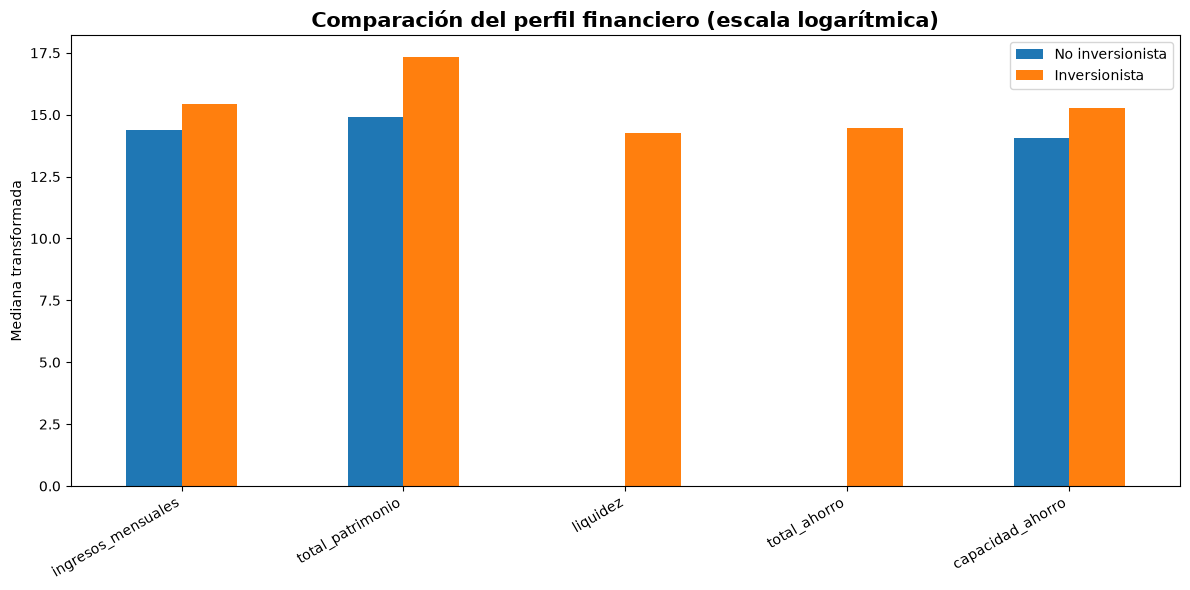

In [71]:
# ============================================================
# 4.3 PERFIL FINANCIERO Y RELACIONAMIENTO NO INVERSIONISTA
# ============================================================

# Se utilizan medianas porque las variables financieras presentan
# asimetría y valores extremos. Se excluyen deliberadamente:
# - num_productos
# - num_productos_inversion
# - total_inversiones
# - saldos y tenencias de productos de inversión
# porque están ligados directa o indirectamente al target.

variables_perfil_financiero = {
    "ingresos_mensuales": "Ingresos mensuales",
    "total_patrimonio": "Patrimonio",
    "total_activos": "Activos",
    "total_pasivos": "Pasivos",
    "liquidez": "Liquidez",
    "total_ahorro": "Ahorro total",
    "capacidad_ahorro": "Capacidad de ahorro",
    "ratio_endeudamiento": "Ratio de endeudamiento",
    "estimador_ingreso": "Estimador de ingreso",
    "num_productos_no_inversion": "Productos no inversionistas"
}

filas_perfil = []

for variable, nombre in variables_perfil_financiero.items():
    valor_no = df_modelo_limpio.loc[
        df_modelo_limpio["es_inversionista"] == 0,
        variable
    ].median()

    valor_si = df_modelo_limpio.loc[
        df_modelo_limpio["es_inversionista"] == 1,
        variable
    ].median()

    # La diferencia porcentual solo se calcula cuando el valor base
    # es distinto de cero. De lo contrario se reporta como no aplicable.
    diferencia_porcentual = (
        ((valor_si / valor_no) - 1) * 100
        if pd.notna(valor_no) and valor_no != 0
        else np.nan
    )

    filas_perfil.append({
        "Característica": nombre,
        "Variable": variable,
        "No inversionista (mediana)": valor_no,
        "Inversionista (mediana)": valor_si,
        "Diferencia (%)": diferencia_porcentual
    })

perfil_financiero = pd.DataFrame(filas_perfil)

print("Perfil financiero comparativo:")
display(perfil_financiero.round(2))

# Gráfico resumido para variables monetarias principales.
variables_grafico = [
    "ingresos_mensuales",
    "total_patrimonio",
    "liquidez",
    "total_ahorro",
    "capacidad_ahorro"
]

medianas_grafico = (
    df_modelo_limpio
    .groupby("es_inversionista")[variables_grafico]
    .median()
    .T
)
medianas_grafico.columns = ["No inversionista", "Inversionista"]

# Transformación logarítmica con signo solo para visualización,
# con el fin de comparar magnitudes muy diferentes.
medianas_log = np.sign(medianas_grafico) * np.log1p(np.abs(medianas_grafico))

ax = medianas_log.plot(
    kind="bar",
    figsize=(12, 6)
)
ax.set_title(
    "Comparación del perfil financiero (escala logarítmica)",
    fontsize=15,
    fontweight="bold"
)
ax.set_ylabel("Mediana transformada")
ax.set_xlabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 4.4 Perfil consolidado y principales hallazgos

Se integran los hallazgos descriptivos anteriores para construir una lectura inicial del perfil de clientes con mayor afinidad hacia productos de inversión.

In [72]:
# ============================================================
# 4.4 PERFIL CONSOLIDADO Y HALLAZGOS PARA MODELADO
# ============================================================

# Consolidar perfil demográfico y financiero en tablas separadas
# para facilitar su lectura en la sustentación.

print("PERFIL DEMOGRÁFICO")
display(perfil_demografico)

print("\nPERFIL FINANCIERO")
display(
    perfil_financiero[
        [
            "Característica",
            "No inversionista (mediana)",
            "Inversionista (mediana)",
            "Diferencia (%)"
        ]
    ].round(2)
)

# Tabla de variables autorizadas y variables excluidas del modelo.
matriz_variables = pd.DataFrame({
    "Grupo": [
        "Demográficas",
        "Financieras generales",
        "Ahorro y liquidez",
        "Productos no inversionistas",
        "Productos de inversión",
        "Variables derivadas del target"
    ],
    "Uso en clasificación": [
        "Sí",
        "Sí",
        "Sí",
        "Sí",
        "No",
        "No"
    ],
    "Justificación": [
        "Describen el perfil del cliente.",
        "Representan capacidad económica y patrimonial.",
        "Representan disponibilidad y hábito de ahorro.",
        "Miden relacionamiento sin revelar el target.",
        "Definen directa o indirectamente es_inversionista.",
        "Contienen información construida con productos de inversión."
    ]
})

print("\nMATRIZ DE USO DE VARIABLES")
display(matriz_variables)

print("\nHallazgos que orientan el modelado:")
print("• El variable objetivo diferencia clientes con y sin experiencia actual en inversión.")
print("• Las medianas permiten comparar grupos sin que los valores extremos dominen el análisis.")
print("• El modelo utilizará únicamente información disponible fuera de los productos que definen el target.")
print("• num_productos y num_productos_inversion se excluyen para evitar fuga de información.")
print("• num_productos_no_inversion se conserva como medida válida de relacionamiento con el banco.")


PERFIL DEMOGRÁFICO


Grupo,Característica,Inversionista,No inversionista
0,Grupo de edad,36-49,36-49
1,Género,FEMENINO,FEMENINO
2,Segmento,PLUS,PERSONAL
3,Tipo de vivienda,SIN INFORMACION,SIN INFORMACION



PERFIL FINANCIERO


,Característica,No inversionista (mediana),Inversionista (mediana),Diferencia (%)
0,Ingresos mensuales,1754748.00,5108387.00,191.12
1,Patrimonio,3027491.00,33973113.00,1022.15
2,Activos,5000000.00,58576200.00,1071.52
3,Pasivos,0.00,0.00,NaN
4,Liquidez,0.00,1535927.45,NaN
5,Ahorro total,0.00,1875683.70,NaN
6,Capacidad de ahorro,1280171.00,4215009.00,229.25
7,Ratio de endeudamiento,0.00,0.00,NaN
8,Estimador de ingreso,2057914.72,5382988.73,161.57
9,Productos no inversionistas,0.00,2.00,NaN



MATRIZ DE USO DE VARIABLES


,Grupo,Uso en clasificación,Justificación
0,Demográficas,Sí,Describen el perfil del cliente.
1,Financieras generales,Sí,Representan capacidad económica y patrimonial.
2,Ahorro y liquidez,Sí,Representan disponibilidad y hábito de ahorro.
3,Productos no inversionistas,Sí,Miden relacionamiento sin revelar el target.
4,Productos de inversión,No,Definen directa o indirectamente es_inversioni...
5,Variables derivadas del target,No,Contienen información construida con productos...



Hallazgos que orientan el modelado:
• El variable objetivo diferencia clientes con y sin experiencia actual en inversión.
• Las medianas permiten comparar grupos sin que los valores extremos dominen el análisis.
• El modelo utilizará únicamente información disponible fuera de los productos que definen el target.
• num_productos y num_productos_inversion se excluyen para evitar fuga de información.
• num_productos_no_inversion se conserva como medida válida de relacionamiento con el banco.


## 4.5 Preparación del modelado y control de fuga

Se define la base de modelado, se excluyen variables que puedan revelar directa o indirectamente el target y se establecen las particiones Train, Validation y Test.

### 4.5.1 Base de modelado

In [73]:
# ============================================================
# 4.5.1 BASE DE MODELADO, VARIABLES Y CONTROL DE FUGA
# ============================================================

import numpy as np
import pandas as pd

# Copia independiente para modelado.
df_clasificacion = df_modelo_limpio.copy()

ID_CLIENTE = "numero_id"
TARGET = "es_inversionista"

# Recalcular únicamente variables determinísticas por cliente.
df_clasificacion["capacidad_ahorro"] = (
    df_clasificacion["ingresos_mensuales"]
    - df_clasificacion["total_egresos_mensuales"]
)

df_clasificacion["ratio_endeudamiento"] = np.where(
    df_clasificacion["total_activos"] > 0,
    df_clasificacion["total_pasivos"] / df_clasificacion["total_activos"],
    np.nan
)

df_clasificacion["num_productos_no_inversion"] = (
    df_clasificacion[
        [
            "tiene_bolsillos",
            "tiene_cta_ahorro",
            "tiene_cta_corriente"
        ]
    ]
    .sum(axis=1)
    .astype("int8")
)

df_clasificacion.replace([np.inf, -np.inf], np.nan, inplace=True)

# Variables categóricas candidatas.
variables_categoricas = [
    "grupo_edad",
    "desc_genero",
    "desc_segmento"
]

# Variables numéricas candidatas sin información de productos
# que definen el variable objetivo.
variables_numericas = [
    "ingresos_mensuales",
    "total_egresos_mensuales",
    "total_activos",
    "total_pasivos",
    "total_patrimonio",
    "estimador_ingreso",
    "capacidad_ahorro",
    "ratio_endeudamiento",
    "liquidez",
    "total_ahorro",
    "num_productos_no_inversion",
    "tiene_bolsillos",
    "tiene_cta_ahorro",
    "tiene_cta_corriente",
    "saldo_actual_bolsillo",
    "saldo_promedio_bolsillo",
    "saldo_maximo_bolsillo",
    "meses_activos_bolsillo",
    "saldo_actual_ahorro",
    "saldo_promedio_ahorro",
    "saldo_maximo_ahorro",
    "meses_activos_ahorro",
    "saldo_actual_corriente",
    "saldo_promedio_corriente",
    "saldo_maximo_corriente",
    "meses_activos_corriente"
]

variables_modelo = variables_categoricas + variables_numericas

# Lista explícita de columnas prohibidas por fuga directa o indirecta.
variables_prohibidas = [
    "tiene_fiducuenta",
    "tiene_inversion_virtual",
    "tiene_cdt",
    "tiene_investbot",
    "num_productos_inversion",
    "num_productos",
    "total_inversiones",
    "saldo_actual_fiducuenta",
    "saldo_promedio_fiducuenta",
    "saldo_maximo_fiducuenta",
    "saldo_minimo_fiducuenta",
    "meses_activos_fiducuenta",
    "saldo_actual_inv_virtual",
    "saldo_promedio_inv_virtual",
    "saldo_maximo_inv_virtual",
    "saldo_minimo_inv_virtual",
    "meses_activos_inv_virtual",
    "saldo_actual_cdt",
    "saldo_promedio_cdt",
    "saldo_maximo_cdt",
    "saldo_minimo_cdt",
    "meses_activos_cdt",
    "saldo_actual_investbot",
    "saldo_promedio_investbot",
    "saldo_maximo_investbot",
    "saldo_minimo_investbot",
    "meses_activos_investbot"
]

fugas_detectadas = set(variables_modelo).intersection(variables_prohibidas)
assert not fugas_detectadas, (
    f"Se detectaron variables con fuga de información: {fugas_detectadas}"
)

# Matrices finales para clasificación.
X = df_clasificacion[variables_modelo].copy()
y = df_clasificacion[TARGET].copy()
ids = df_clasificacion[ID_CLIENTE].copy()

print(f"Registros: {len(X):,}")
print(f"Variables predictoras: {X.shape[1]}")
print(f"Proporción de inversionistas: {y.mean() * 100:.2f}%")
print("✅ Variables preparadas sin fuga directa.")


Registros: 855,367
Variables predictoras: 29
Proporción de inversionistas: 25.77%
✅ Variables preparadas sin fuga directa.


### 4.5.2 División Train / Validation / Test

In [74]:
# ============================================================
# 4.5.2 DIVISIÓN TRAIN / VALIDATION / TEST
# ============================================================

from sklearn.model_selection import train_test_split

# Primera división: 80 % Train + Validation y 20 % Test.
(
    X_trainval,
    X_test,
    y_trainval,
    y_test,
    ids_trainval,
    ids_test
) = train_test_split(
    X,
    y,
    ids,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Segunda división: del 80 % anterior, 25 % se asigna a Validation.
# Resultado final: Train 60 %, Validation 20 %, Test 20 %.
(
    X_train,
    X_validation,
    y_train,
    y_validation,
    ids_train,
    ids_validation
) = train_test_split(
    X_trainval,
    y_trainval,
    ids_trainval,
    test_size=0.25,
    random_state=42,
    stratify=y_trainval
)

# Verificar que los clientes no se repitan entre particiones.
assert set(ids_train).isdisjoint(set(ids_validation))
assert set(ids_train).isdisjoint(set(ids_test))
assert set(ids_validation).isdisjoint(set(ids_test))

resumen_particiones = pd.DataFrame({
    "Conjunto": ["Train", "Validation", "Test"],
    "Registros": [len(X_train), len(X_validation), len(X_test)],
    "% de la base": [
        len(X_train) / len(X) * 100,
        len(X_validation) / len(X) * 100,
        len(X_test) / len(X) * 100
    ],
    "% inversionistas": [
        y_train.mean() * 100,
        y_validation.mean() * 100,
        y_test.mean() * 100
    ]
})

display(resumen_particiones.round(2))
print("✅ Particiones creadas correctamente.")
print("⚠️ Test queda aislado hasta la evaluación final.")


,Conjunto,Registros,% de la base,% inversionistas
0,Train,513219,60.0,25.77
1,Validation,171074,20.0,25.77
2,Test,171074,20.0,25.77


✅ Particiones creadas correctamente.
⚠️ Test queda aislado hasta la evaluación final.


## 4.6 Desarrollo y comparación de modelos de clasificación

Se comparan diferentes algoritmos de clasificación bajo un mismo proceso de preprocesamiento. La selección preliminar se realiza exclusivamente con Validation.

### 4.6.1 Preprocesamiento y definición

In [75]:
# ============================================================
# 4.6.1 PREPROCESAMIENTO Y DEFINICIÓN DE MODELOS
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


# ------------------------------------------------------------
# 1. Procesamiento de variables categóricas
# ------------------------------------------------------------
# - Imputa valores faltantes con "SIN INFORMACION".
# - Convierte categorías a variables binarias mediante OneHot.
# - handle_unknown="ignore" evita errores si aparece una
#   categoría nueva en Validation o Test.
# ------------------------------------------------------------

procesamiento_categorico = Pipeline(
    steps=[
        (
            "imputacion",
            SimpleImputer(
                strategy="constant",
                fill_value="SIN INFORMACION"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=100,
                sparse_output=True
            )
        )
    ]
)


# ------------------------------------------------------------
# 2. Procesamiento numérico para Regresión Logística
# ------------------------------------------------------------
# La Regresión Logística es sensible a la escala:
# - imputamos con la mediana calculada solo en Train;
# - luego estandarizamos las variables.
# ------------------------------------------------------------

procesamiento_numerico_lineal = Pipeline(
    steps=[
        (
            "imputacion",
            SimpleImputer(strategy="median")
        ),
        (
            "escalado",
            StandardScaler()
        )
    ]
)


# ------------------------------------------------------------
# 3. Procesamiento numérico para modelos de árboles
# ------------------------------------------------------------
# Árboles, Random Forest y XGBoost no requieren escalado.
# Solo se imputan valores faltantes con la mediana de Train.
# ------------------------------------------------------------

procesamiento_numerico_arbol = Pipeline(
    steps=[
        (
            "imputacion",
            SimpleImputer(strategy="median")
        )
    ]
)


# ------------------------------------------------------------
# 4. Crear preprocesadores completos
# ------------------------------------------------------------

preprocesador_lineal = ColumnTransformer(
    transformers=[
        (
            "numericas",
            procesamiento_numerico_lineal,
            variables_numericas
        ),
        (
            "categoricas",
            procesamiento_categorico,
            variables_categoricas
        )
    ]
)

preprocesador_arbol = ColumnTransformer(
    transformers=[
        (
            "numericas",
            procesamiento_numerico_arbol,
            variables_numericas
        ),
        (
            "categoricas",
            procesamiento_categorico,
            variables_categoricas
        )
    ]
)


# ------------------------------------------------------------
# 5. Definir modelos
# ------------------------------------------------------------

# Modelo base:
# Permite establecer una referencia lineal e interpretable.
modelo_logistico = Pipeline(
    steps=[
        (
            "preprocesamiento",
            preprocesador_lineal
        ),
        (
            "modelo",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                solver="saga",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


# Árbol de decisión:
# Modelo no lineal e interpretable.
# Se limita su profundidad para reducir sobreajuste.
modelo_arbol = Pipeline(
    steps=[
        (
            "preprocesamiento",
            preprocesador_arbol
        ),
        (
            "modelo",
            DecisionTreeClassifier(
                max_depth=10,
                min_samples_split=100,
                min_samples_leaf=50,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)


# Random Forest:
# Combina múltiples árboles para mejorar estabilidad
# y capacidad de generalización.
modelo_random_forest = Pipeline(
    steps=[
        (
            "preprocesamiento",
            preprocesador_arbol
        ),
        (
            "modelo",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=15,
                min_samples_split=100,
                min_samples_leaf=30,
                max_features="sqrt",
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


# ------------------------------------------------------------
# 6. XGBoost
# ------------------------------------------------------------
# Se calcula scale_pos_weight para compensar el desbalance.
# ------------------------------------------------------------

try:
    from xgboost import XGBClassifier

    cantidad_positivos = y_train.sum()
    cantidad_negativos = len(y_train) - cantidad_positivos

    scale_pos_weight = (
        cantidad_negativos
        / cantidad_positivos
    )

    modelo_xgboost = Pipeline(
        steps=[
            (
                "preprocesamiento",
                preprocesador_arbol
            ),
            (
                "modelo",
                XGBClassifier(
                    n_estimators=300,
                    max_depth=6,
                    learning_rate=0.05,
                    subsample=0.80,
                    colsample_bytree=0.80,
                    min_child_weight=10,
                    objective="binary:logistic",
                    eval_metric="logloss",
                    scale_pos_weight=scale_pos_weight,
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]
    )

    xgboost_disponible = True

except ImportError:

    print(
        "XGBoost no está instalado. "
        "Puedes instalarlo con: pip install xgboost"
    )

    xgboost_disponible = False


# ------------------------------------------------------------
# 7. Consolidar modelos en un diccionario
# ------------------------------------------------------------

modelos = {
    "Regresión logística": modelo_logistico,
    "Árbol de decisión": modelo_arbol,
    "Random Forest": modelo_random_forest
}

if xgboost_disponible:
    modelos["XGBoost"] = modelo_xgboost


print("Modelos preparados:")
for nombre in modelos:
    print(f"• {nombre}")


Modelos preparados:
• Regresión logística
• Árbol de decisión
• Random Forest
• XGBoost


### 4.6.2 Entrenamiento y comparación en Validation

In [76]:
# ============================================================
# 4.6.2 ENTRENAMIENTO Y COMPARACIÓN EN VALIDATION
# ============================================================

import time

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)


def entrenar_y_evaluar_modelo(
    nombre,
    modelo,
    X_train,
    y_train,
    X_validation,
    y_validation,
    umbral=0.50
):
    """
    Entrena un modelo con el conjunto Train y lo evalúa
    sobre Validation.

    Parámetros
    ----------
    nombre : str
        Nombre del modelo.

    modelo : Pipeline
        Pipeline completo con preprocesamiento y algoritmo.

    X_train, y_train
        Datos de entrenamiento.

    X_validation, y_validation
        Datos de validación.

    umbral : float
        Probabilidad mínima para clasificar un cliente
        como inversionista. Inicialmente se usa 0.50.

    Retorna
    -------
    resultado : dict
        Métricas del modelo.

    probabilidades : numpy.ndarray
        Probabilidades estimadas para la clase positiva.

    predicciones : numpy.ndarray
        Clases estimadas según el umbral.
    """

    # Medir duración del entrenamiento.
    inicio = time.time()

    # El pipeline aprende:
    # - medianas de imputación;
    # - escalado si corresponde;
    # - categorías del OneHotEncoder;
    # - parámetros del modelo.
    #
    # Todo esto se aprende exclusivamente con Train.
    modelo.fit(
        X_train,
        y_train
    )

    tiempo_entrenamiento = (
        time.time() - inicio
    )

    # Probabilidad estimada de pertenecer a la clase 1.
    probabilidades = modelo.predict_proba(
        X_validation
    )[:, 1]

    # Convertir probabilidades a clases.
    predicciones = (
        probabilidades >= umbral
    ).astype(int)

    # Matriz de confusión.
    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        predicciones
    ).ravel()

    # Consolidar métricas.
    resultado = {
        "Modelo": nombre,

        "Accuracy": accuracy_score(
            y_validation,
            predicciones
        ),

        "Balanced Accuracy": balanced_accuracy_score(
            y_validation,
            predicciones
        ),

        "Precision": precision_score(
            y_validation,
            predicciones,
            zero_division=0
        ),

        "Recall": recall_score(
            y_validation,
            predicciones,
            zero_division=0
        ),

        "F1": f1_score(
            y_validation,
            predicciones,
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_validation,
            probabilidades
        ),

        "PR-AUC": average_precision_score(
            y_validation,
            probabilidades
        ),

        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,

        "Tiempo_segundos": tiempo_entrenamiento
    }

    return (
        resultado,
        probabilidades,
        predicciones
    )


# ------------------------------------------------------------
# Entrenar todos los modelos
# ------------------------------------------------------------

resultados_modelos = []
probabilidades_modelos = {}
predicciones_modelos = {}
modelos_entrenados = {}

for nombre, modelo in modelos.items():

    print("=" * 70)
    print(f"Entrenando modelo: {nombre}")
    print("=" * 70)

    (
        resultado,
        probabilidades,
        predicciones
    ) = entrenar_y_evaluar_modelo(
        nombre=nombre,
        modelo=modelo,
        X_train=X_train,
        y_train=y_train,
        X_validation=X_validation,
        y_validation=y_validation,
        umbral=0.50
    )

    resultados_modelos.append(
        resultado
    )

    probabilidades_modelos[nombre] = (
        probabilidades
    )

    predicciones_modelos[nombre] = (
        predicciones
    )

    modelos_entrenados[nombre] = modelo

    print(
        f"Finalizado en "
        f"{resultado['Tiempo_segundos']:.2f} segundos"
    )

    print(
        f"ROC-AUC: {resultado['ROC-AUC']:.4f}"
    )

    print(
        f"PR-AUC: {resultado['PR-AUC']:.4f}"
    )

    print(
        f"Recall: {resultado['Recall']:.4f}"
    )

    print(
        f"Precision: {resultado['Precision']:.4f}"
    )

    print()


# ------------------------------------------------------------
# Tabla comparativa
# ------------------------------------------------------------

tabla_comparacion = (
    pd.DataFrame(resultados_modelos)
    .sort_values(
        by=[
            "PR-AUC",
            "ROC-AUC",
            "F1"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

columnas_resumen = [
    "Modelo",
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC",
    "Tiempo_segundos"
]

display(
    tabla_comparacion[
        columnas_resumen
    ].round(4)
)


Entrenando modelo: Regresión logística


C:\Users\alejo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
C:\Users\alejo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Finalizado en 367.83 segundos
ROC-AUC: 0.8805
PR-AUC: 0.7457
Recall: 0.7858
Precision: 0.6265

Entrenando modelo: Árbol de decisión
Finalizado en 9.28 segundos
ROC-AUC: 0.9062
PR-AUC: 0.8004
Recall: 0.8086
Precision: 0.6757

Entrenando modelo: Random Forest
Finalizado en 46.88 segundos
ROC-AUC: 0.9124
PR-AUC: 0.8123
Recall: 0.8012
Precision: 0.6972

Entrenando modelo: XGBoost
Finalizado en 9.32 segundos
ROC-AUC: 0.9151
PR-AUC: 0.8184
Recall: 0.8160
Precision: 0.6863



,Modelo,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Tiempo_segundos
0,XGBoost,0.8565,0.8433,0.6863,0.8160,0.7456,0.9151,0.8184,9.3208
1,Random Forest,0.8591,0.8402,0.6972,0.8012,0.7456,0.9124,0.8123,46.8813
2,Árbol de decisión,0.8507,0.8370,0.6757,0.8086,0.7362,0.9062,0.8004,9.2820
3,Regresión logística,0.8241,0.8116,0.6265,0.7858,0.6972,0.8805,0.7457,367.8275


### 4.6.3 Visualización y selección preliminar

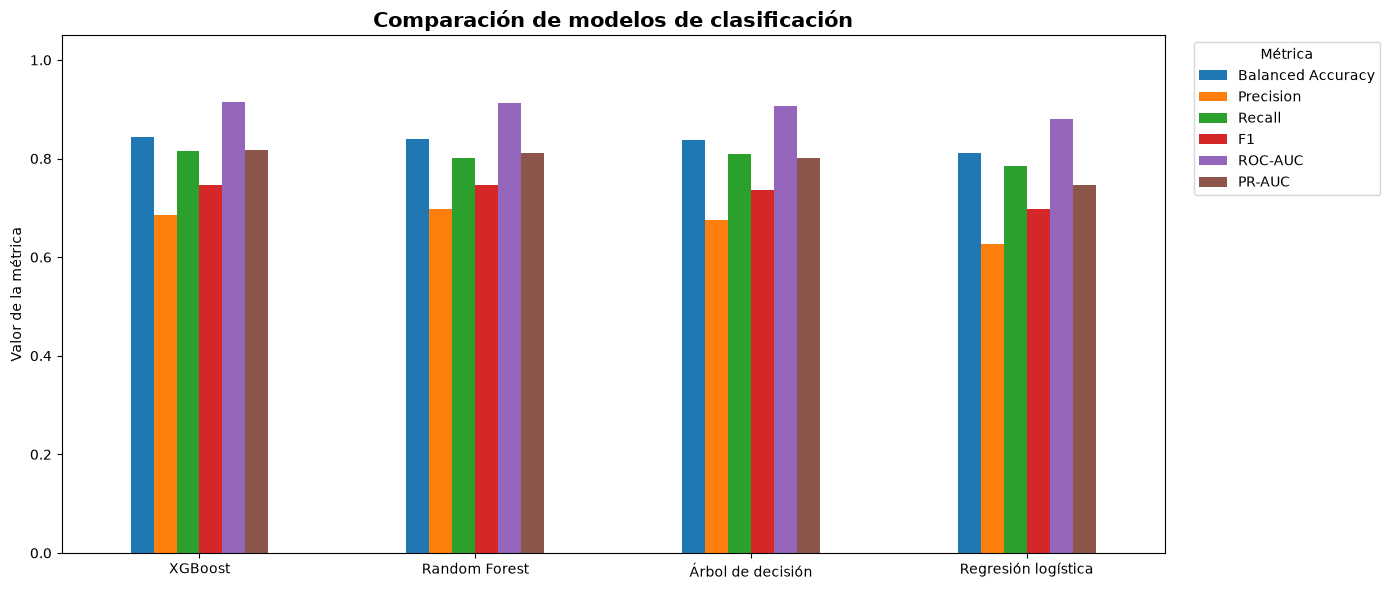

Mejor modelo preliminar según Validation: XGBoost


,0
Modelo,XGBoost
Accuracy,0.85646
Balanced Accuracy,0.843265
Precision,0.686308
Recall,0.816035
F1,0.745571
ROC-AUC,0.915097
PR-AUC,0.818359
TN,110539
FP,16445


In [77]:
# ============================================================
# 5.3 VISUALIZACIÓN DE RESULTADOS DE VALIDATION
# ============================================================

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Gráfico de comparación de métricas
# ------------------------------------------------------------

metricas_grafico = [
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC"
]

datos_grafico = (
    tabla_comparacion
    .set_index("Modelo")[metricas_grafico]
)

ax = datos_grafico.plot(
    kind="bar",
    figsize=(14, 6)
)

ax.set_title(
    "Comparación de modelos de clasificación",
    fontsize=15,
    fontweight="bold"
)

ax.set_ylabel("Valor de la métrica")
ax.set_xlabel("")
ax.set_ylim(0, 1.05)

ax.legend(
    title="Métrica",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Identificar el mejor modelo según PR-AUC
# ------------------------------------------------------------
# PR-AUC es especialmente útil cuando la clase positiva
# está desbalanceada y se quiere priorizar correctamente
# a los clientes con mayor afinidad.
# ------------------------------------------------------------

mejor_modelo_nombre = (
    tabla_comparacion
    .iloc[0]["Modelo"]
)

mejor_modelo = modelos_entrenados[
    mejor_modelo_nombre
]

print(
    f"Mejor modelo preliminar según Validation: "
    f"{mejor_modelo_nombre}"
)


# ------------------------------------------------------------
# 3. Mostrar métricas completas del ganador
# ------------------------------------------------------------

metricas_mejor_modelo = (
    tabla_comparacion
    .loc[
        tabla_comparacion["Modelo"]
        == mejor_modelo_nombre
    ]
)

display(
    metricas_mejor_modelo.T
)


#### 4.6.3.1 Lectura de resultados

Comparación XGBoost vs. Random Forest

La diferencia predictiva es reducida:

| Métrica   |    XGBoost | Random Forest |
| --------- | ---------: | ------------: |
| Precision |       0.69 |      **0.70** |
| Recall    |   **0.82** |          0.80 |
| F1        |       0.75 |          0.75 |
| ROC-AUC   |   **0.92** |          0.91 |
| PR-AUC    |   **0.82** |          0.81 |
| Tiempo    | **11.7 s** |        45.7 s |


XGBoost sería el candidato principal porque:

Recupera más clientes potenciales.
Ordena ligeramente mejor la clase inversionista.
Entrena casi cuatro veces más rápido en esta ejecución.
Mantiene el mismo F1 que Random Forest.

Random Forest puede conservarse como modelo finalista o challenger.


Los modelos basados en relaciones no lineales superaron al modelo lineal de referencia. XGBoost presentó el mejor desempeño global en validación, alcanzando un ROC-AUC de 0,92 y un PR-AUC de 0,82, además de identificar el 82 % de los clientes clasificados como inversionistas.

Random Forest obtuvo resultados cercanos y una precisión ligeramente superior, pero presentó menor recall y mayor tiempo de entrenamiento. En consecuencia, XGBoost fue seleccionado como modelo candidato principal y Random Forest como modelo alternativo para las siguientes validaciones.


## 4.7 Validación cruzada de los modelos finalistas

Se verifica la estabilidad de los modelos finalistas mediante validación cruzada, reduciendo el riesgo de seleccionar un modelo por un resultado particular de una única partición.

In [78]:
# ============================================================
# 4.7 VALIDACIÓN CRUZADA DE LOS MODELOS FINALISTAS
# ============================================================

import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate


# ------------------------------------------------------------
# Se evalúan los dos modelos finalistas únicamente con Train.
# Validation y Test no participan en este procedimiento.
#
# Se utilizan tres folds para mantener un costo computacional
# razonable con una base superior a 800.000 clientes.
# ------------------------------------------------------------

cv_estratificado = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

modelos_finalistas = {
    "XGBoost": modelos_entrenados["XGBoost"],
    "Random Forest": modelos_entrenados["Random Forest"]
}

metricas_cv = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

resultados_cv = []


for nombre, modelo in modelos_finalistas.items():

    print("=" * 70)
    print(f"Validación cruzada: {nombre}")
    print("=" * 70)

    resultado = cross_validate(
        estimator=modelo,
        X=X_train,
        y=y_train,
        cv=cv_estratificado,
        scoring=metricas_cv,
        n_jobs=1,
        return_train_score=False
    )

    resultados_cv.append({
        "Modelo": nombre,

        "Balanced Accuracy media":
            resultado["test_balanced_accuracy"].mean(),

        "Balanced Accuracy std":
            resultado["test_balanced_accuracy"].std(),

        "Precision media":
            resultado["test_precision"].mean(),

        "Precision std":
            resultado["test_precision"].std(),

        "Recall media":
            resultado["test_recall"].mean(),

        "Recall std":
            resultado["test_recall"].std(),

        "F1 media":
            resultado["test_f1"].mean(),

        "F1 std":
            resultado["test_f1"].std(),

        "ROC-AUC media":
            resultado["test_roc_auc"].mean(),

        "ROC-AUC std":
            resultado["test_roc_auc"].std(),

        "PR-AUC media":
            resultado["test_pr_auc"].mean(),

        "PR-AUC std":
            resultado["test_pr_auc"].std(),

        "Tiempo fit medio":
            resultado["fit_time"].mean()
    })


tabla_cv = (
    pd.DataFrame(resultados_cv)
    .sort_values(
        by="PR-AUC media",
        ascending=False
    )
    .reset_index(drop=True)
)

display(tabla_cv.round(4))


Validación cruzada: XGBoost
Validación cruzada: Random Forest


,Modelo,Balanced Accuracy media,Balanced Accuracy std,Precision media,Precision std,Recall media,Recall std,F1 media,F1 std,ROC-AUC media,ROC-AUC std,PR-AUC media,PR-AUC std,Tiempo fit medio
0,XGBoost,0.8429,0.0008,0.6866,0.0025,0.8151,0.0028,0.7453,0.0010,0.9157,0.0005,0.8185,0.0001,6.3733
1,Random Forest,0.8401,0.0007,0.6966,0.0016,0.8015,0.0019,0.7454,0.0009,0.9129,0.0006,0.8130,0.0007,29.0083


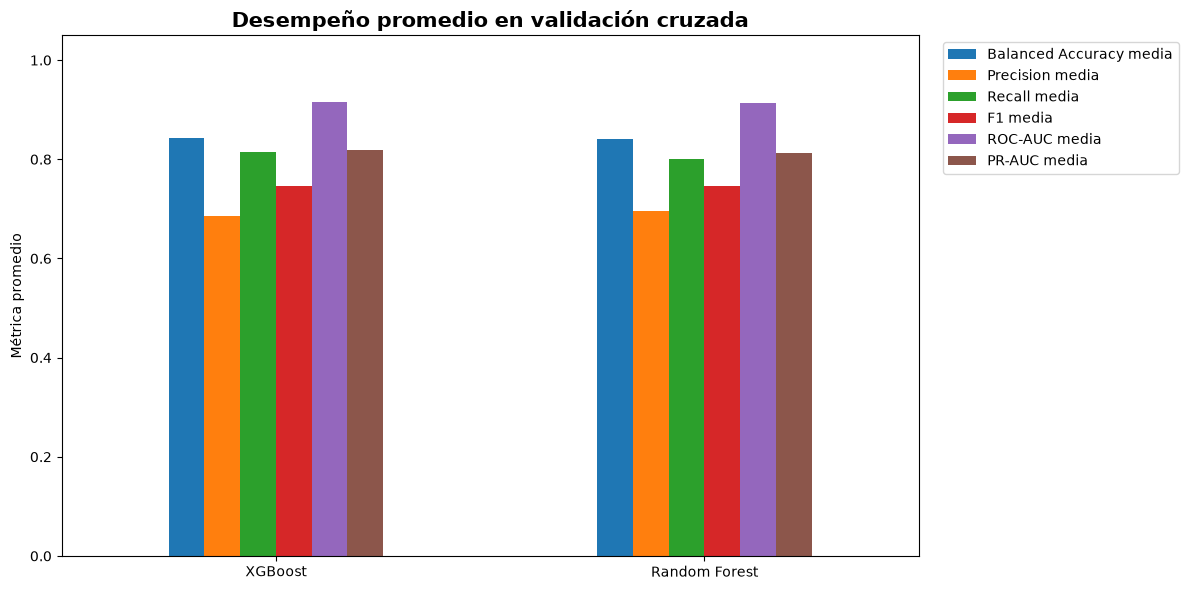

In [79]:
# ============================================================
# GRÁFICO DE RESULTADOS DE VALIDACIÓN CRUZADA
# ============================================================

import matplotlib.pyplot as plt


metricas_media = [
    "Balanced Accuracy media",
    "Precision media",
    "Recall media",
    "F1 media",
    "ROC-AUC media",
    "PR-AUC media"
]

grafico_cv = (
    tabla_cv
    .set_index("Modelo")[metricas_media]
)

ax = grafico_cv.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title(
    "Desempeño promedio en validación cruzada",
    fontsize=15,
    fontweight="bold"
)

ax.set_ylabel("Métrica promedio")
ax.set_xlabel("")
ax.set_ylim(0, 1.05)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [80]:
tabla_cv = (
    tabla_cv
    .sort_values("PR-AUC media", ascending=False)
    .reset_index(drop=True)
)

tabla_cv_presentacion = pd.DataFrame({

    "Modelo": tabla_cv["Modelo"],

    "Balanced Accuracy":
        tabla_cv["Balanced Accuracy media"].map("{:.4f}".format)
        + " ± "
        + tabla_cv["Balanced Accuracy std"].map("{:.4f}".format),

    "Precision":
        tabla_cv["Precision media"].map("{:.4f}".format)
        + " ± "
        + tabla_cv["Precision std"].map("{:.4f}".format),

    "Recall":
        tabla_cv["Recall media"].map("{:.4f}".format)
        + " ± "
        + tabla_cv["Recall std"].map("{:.4f}".format),

    "F1":
        tabla_cv["F1 media"].map("{:.4f}".format)
        + " ± "
        + tabla_cv["F1 std"].map("{:.4f}".format),

    "ROC-AUC":
        tabla_cv["ROC-AUC media"].map("{:.4f}".format)
        + " ± "
        + tabla_cv["ROC-AUC std"].map("{:.4f}".format),

    "PR-AUC":
        tabla_cv["PR-AUC media"].map("{:.4f}".format)
        + " ± "
        + tabla_cv["PR-AUC std"].map("{:.4f}".format),

    "Tiempo promedio (s)":
        tabla_cv["Tiempo fit medio"].round(2)
})

display(tabla_cv_presentacion)


,Modelo,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Tiempo promedio (s)
0,XGBoost,0.8429 ± 0.0008,0.6866 ± 0.0025,0.8151 ± 0.0028,0.7453 ± 0.0010,0.9157 ± 0.0005,0.8185 ± 0.0001,6.37
1,Random Forest,0.8401 ± 0.0007,0.6966 ± 0.0016,0.8015 ± 0.0019,0.7454 ± 0.0009,0.9129 ± 0.0006,0.8130 ± 0.0007,29.01


## 4.8 Optimización del umbral de decisión

Se evalúa el umbral de clasificación para buscar un equilibrio entre la identificación de clientes potenciales y los errores de clasificación, considerando las necesidades del negocio.

OPTIMIZACIÓN DEL UMBRAL
Modelo analizado: XGBoost
Registros en Validation: 171,074
Proporción real de inversionistas: 25.77%

UMBRAL QUE MAXIMIZA F1
Umbral: 0.60
Precision: 0.7351
Recall: 0.7740
F1: 0.7540
Balanced Accuracy: 0.8386
Base priorizada: 27.14%

ESCENARIOS DE DECISIÓN COMERCIAL


,Escenario,Objetivo,Umbral,Precision,Recall,F1,Balanced Accuracy,Clientes priorizados,% base priorizada,Falsos positivos,Falsos negativos
0,Cobertura alta,Recall mínimo de 90%,0.27,0.5343,0.9039,0.6716,0.8152,"74,584",43.60%,"34,733","4,239"
1,Equilibrado,Máximo F1,0.60,0.7351,0.7740,0.7540,0.8386,"46,422",27.14%,"12,298","9,966"
2,Campaña focalizada,Precision mínima de 80%,0.75,0.8011,0.6935,0.7435,0.8169,"38,167",22.31%,"7,590","13,513"


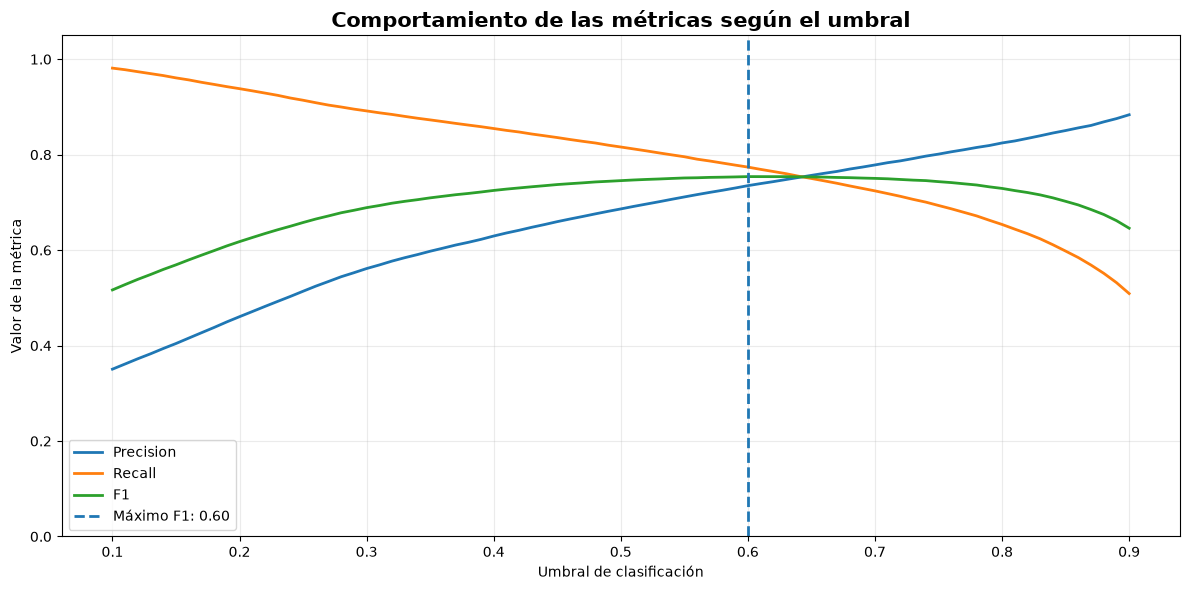

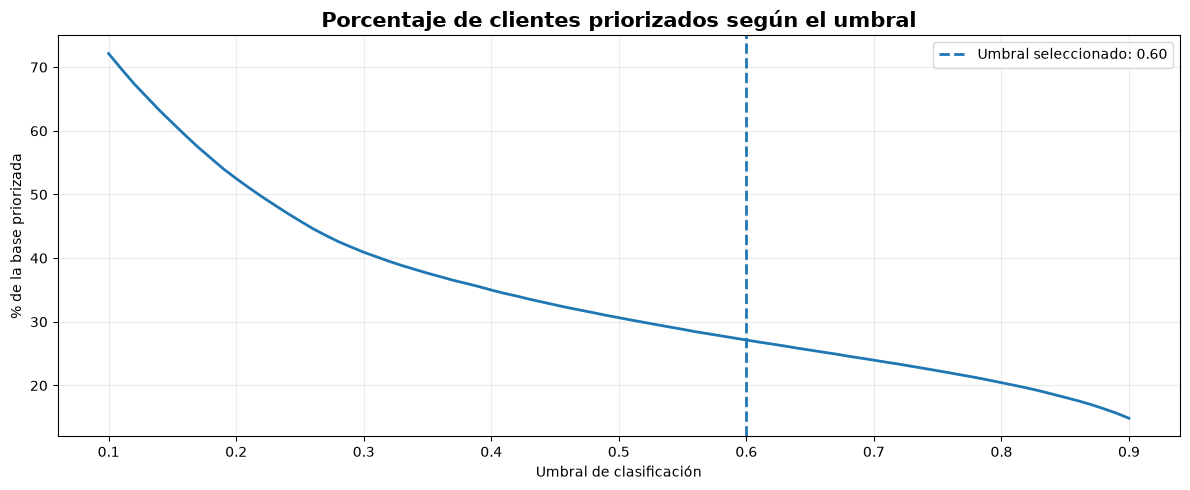


UMBRAL FINAL PRELIMINAR
Umbral seleccionado: 0.60
El umbral fue seleccionado exclusivamente con el conjunto Validation.
El conjunto Test continúa completamente aislado.

Resultados esperados en Validation:
Precision: 0.7351
Recall: 0.7740
F1: 0.7540
Balanced Accuracy: 0.8386
Clientes priorizados: 46,422
Porcentaje de la base priorizada: 27.14%


In [81]:
# ============================================================
# 4.8 OPTIMIZACIÓN DEL UMBRAL DE CLASIFICACIÓN
# ============================================================
#
# Objetivo:
# Evaluar diferentes umbrales de decisión utilizando
# exclusivamente el conjunto de Validation.
#
# Un umbral bajo:
# - aumenta el Recall;
# - detecta más clientes potenciales;
# - genera más falsos positivos.
#
# Un umbral alto:
# - aumenta la Precision;
# - reduce el número de clientes contactados;
# - puede dejar por fuera clientes con potencial.
#
# El conjunto Test permanece completamente aislado.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# ============================================================
# 1. SELECCIONAR EL MODELO FINALISTA
# ============================================================
#
# Se utilizarán las probabilidades de XGBoost obtenidas
# previamente sobre el conjunto de Validation.
# ============================================================

NOMBRE_MODELO_FINALISTA = "XGBoost"

# Validar que existan las probabilidades del modelo.
if NOMBRE_MODELO_FINALISTA not in probabilidades_modelos:
    raise KeyError(
        f"No se encontraron probabilidades para el modelo "
        f"'{NOMBRE_MODELO_FINALISTA}'."
    )

# Probabilidad estimada de pertenecer a la clase inversionista.
probabilidades_validation = np.asarray(
    probabilidades_modelos[NOMBRE_MODELO_FINALISTA]
)

# Convertir el target de validación en un arreglo de NumPy.
y_validation_array = np.asarray(y_validation)


# ============================================================
# 2. VALIDACIONES BÁSICAS
# ============================================================

# Verificar que probabilidades y target tengan la misma longitud.
if len(probabilidades_validation) != len(y_validation_array):
    raise ValueError(
        "La cantidad de probabilidades no coincide con "
        "la cantidad de registros de Validation."
    )

# Verificar que no existan valores faltantes o infinitos.
if (
    np.isnan(probabilidades_validation).any()
    or np.isinf(probabilidades_validation).any()
):
    raise ValueError(
        "Las probabilidades contienen valores NaN o infinitos."
    )

print("=" * 70)
print("OPTIMIZACIÓN DEL UMBRAL")
print("=" * 70)

print(f"Modelo analizado: {NOMBRE_MODELO_FINALISTA}")
print(f"Registros en Validation: {len(y_validation_array):,}")
print(
    f"Proporción real de inversionistas: "
    f"{y_validation_array.mean() * 100:.2f}%"
)


# ============================================================
# 3. EVALUAR DIFERENTES UMBRALES
# ============================================================
#
# Se prueban valores desde 0.10 hasta 0.90.
# Para cada umbral se calculan métricas de desempeño,
# matriz de confusión y tamaño de la base priorizada.
# ============================================================

umbrales = np.arange(
    start=0.10,
    stop=0.91,
    step=0.01
)

resultados_umbrales = []

for umbral in umbrales:

    # Convertir probabilidades en predicciones binarias.
    predicciones_umbral = (
        probabilidades_validation >= umbral
    ).astype(int)

    # Obtener matriz de confusión.
    tn, fp, fn, tp = confusion_matrix(
        y_validation_array,
        predicciones_umbral
    ).ravel()

    # Cantidad de clientes clasificados como potenciales.
    clientes_priorizados = predicciones_umbral.sum()

    # Porcentaje de la base que sería priorizada.
    porcentaje_priorizado = (
        clientes_priorizados
        / len(predicciones_umbral)
        * 100
    )

    # Guardar métricas para el umbral evaluado.
    resultados_umbrales.append({
        "Umbral": round(float(umbral), 2),

        "Accuracy": accuracy_score(
            y_validation_array,
            predicciones_umbral
        ),

        "Balanced Accuracy": balanced_accuracy_score(
            y_validation_array,
            predicciones_umbral
        ),

        "Precision": precision_score(
            y_validation_array,
            predicciones_umbral,
            zero_division=0
        ),

        "Recall": recall_score(
            y_validation_array,
            predicciones_umbral,
            zero_division=0
        ),

        "F1": f1_score(
            y_validation_array,
            predicciones_umbral,
            zero_division=0
        ),

        "Clientes priorizados": int(clientes_priorizados),
        "% base priorizada": porcentaje_priorizado,

        "Verdaderos negativos": int(tn),
        "Falsos positivos": int(fp),
        "Falsos negativos": int(fn),
        "Verdaderos positivos": int(tp)
    })


# Convertir los resultados en DataFrame.
tabla_umbrales = pd.DataFrame(
    resultados_umbrales
)


# ============================================================
# 4. ENCONTRAR EL UMBRAL QUE MAXIMIZA F1
# ============================================================
#
# F1 representa el equilibrio entre Precision y Recall.
# Se utilizará como criterio técnico inicial.
# ============================================================

indice_mejor_f1 = tabla_umbrales["F1"].idxmax()

fila_mejor_f1 = tabla_umbrales.loc[
    indice_mejor_f1
].copy()

umbral_mejor_f1 = float(
    fila_mejor_f1["Umbral"]
)

print("\n" + "=" * 70)
print("UMBRAL QUE MAXIMIZA F1")
print("=" * 70)

print(f"Umbral: {umbral_mejor_f1:.2f}")
print(f"Precision: {fila_mejor_f1['Precision']:.4f}")
print(f"Recall: {fila_mejor_f1['Recall']:.4f}")
print(f"F1: {fila_mejor_f1['F1']:.4f}")
print(
    f"Balanced Accuracy: "
    f"{fila_mejor_f1['Balanced Accuracy']:.4f}"
)
print(
    f"Base priorizada: "
    f"{fila_mejor_f1['% base priorizada']:.2f}%"
)


# ============================================================
# 5. FUNCIÓN PARA SELECCIONAR ESCENARIOS COMERCIALES
# ============================================================

def seleccionar_mejor_escenario(
    tabla,
    condicion,
    metrica_orden,
    ascendente=False
):
    """
    Filtra la tabla según una condición y selecciona
    la mejor fila de acuerdo con una métrica.

    Parámetros
    ----------
    tabla : DataFrame
        Tabla con los resultados por umbral.

    condicion : Serie booleana
        Registros que cumplen la condición comercial.

    metrica_orden : str
        Métrica utilizada para ordenar los candidatos.

    ascendente : bool
        Define el sentido del ordenamiento.

    Retorna
    -------
    Series o None
        Mejor escenario encontrado.
    """

    candidatos = tabla.loc[condicion].copy()

    if candidatos.empty:
        return None

    return (
        candidatos
        .sort_values(
            by=metrica_orden,
            ascending=ascendente
        )
        .iloc[0]
    )


# ============================================================
# 6. CONSTRUIR TRES ESCENARIOS DE NEGOCIO
# ============================================================
#
# Escenario 1: Cobertura alta
# - exige Recall mínimo de 90%;
# - entre los candidatos, maximiza Precision.
#
# Escenario 2: Equilibrado
# - selecciona el umbral con máximo F1.
#
# Escenario 3: Campaña focalizada
# - exige Precision mínima de 80%;
# - entre los candidatos, maximiza Recall.
# ============================================================

escenario_cobertura = seleccionar_mejor_escenario(
    tabla=tabla_umbrales,
    condicion=tabla_umbrales["Recall"] >= 0.90,
    metrica_orden="Precision",
    ascendente=False
)

escenario_equilibrado = fila_mejor_f1

escenario_focalizado = seleccionar_mejor_escenario(
    tabla=tabla_umbrales,
    condicion=tabla_umbrales["Precision"] >= 0.80,
    metrica_orden="Recall",
    ascendente=False
)


# Consolidar únicamente los escenarios disponibles.
escenarios = []

if escenario_cobertura is not None:
    escenarios.append({
        "Escenario": "Cobertura alta",
        "Objetivo": "Recall mínimo de 90%",
        **escenario_cobertura.to_dict()
    })

escenarios.append({
    "Escenario": "Equilibrado",
    "Objetivo": "Máximo F1",
    **escenario_equilibrado.to_dict()
})

if escenario_focalizado is not None:
    escenarios.append({
        "Escenario": "Campaña focalizada",
        "Objetivo": "Precision mínima de 80%",
        **escenario_focalizado.to_dict()
    })


tabla_escenarios = pd.DataFrame(
    escenarios
)

columnas_escenarios = [
    "Escenario",
    "Objetivo",
    "Umbral",
    "Precision",
    "Recall",
    "F1",
    "Balanced Accuracy",
    "Clientes priorizados",
    "% base priorizada",
    "Falsos positivos",
    "Falsos negativos"
]

tabla_escenarios = (
    tabla_escenarios[columnas_escenarios]
    .drop_duplicates(subset=["Escenario"])
    .reset_index(drop=True)
)


# ============================================================
# 7. FORMATEAR TABLA SIN UTILIZAR .STYLE
# ============================================================
#
# Se construye una copia únicamente para presentación.
# Esto evita depender de Jinja2.
# ============================================================

tabla_escenarios_presentacion = (
    tabla_escenarios.copy()
)

# Formatear el umbral con dos decimales.
tabla_escenarios_presentacion["Umbral"] = (
    tabla_escenarios["Umbral"]
    .map(lambda valor: f"{valor:.2f}")
)

# Formatear las métricas con cuatro decimales.
for columna in [
    "Precision",
    "Recall",
    "F1",
    "Balanced Accuracy"
]:
    tabla_escenarios_presentacion[columna] = (
        tabla_escenarios[columna]
        .map(lambda valor: f"{valor:.4f}")
    )

# Formatear el porcentaje de la base.
tabla_escenarios_presentacion["% base priorizada"] = (
    tabla_escenarios["% base priorizada"]
    .map(lambda valor: f"{valor:.2f}%")
)

# Formatear cantidades de clientes.
for columna in [
    "Clientes priorizados",
    "Falsos positivos",
    "Falsos negativos"
]:
    tabla_escenarios_presentacion[columna] = (
        tabla_escenarios[columna]
        .map(lambda valor: f"{valor:,.0f}")
    )

print("\n" + "=" * 70)
print("ESCENARIOS DE DECISIÓN COMERCIAL")
print("=" * 70)

display(
    tabla_escenarios_presentacion
)


# ============================================================
# 8. GRÁFICO: PRECISION, RECALL Y F1 SEGÚN EL UMBRAL
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 6)
)

ax.plot(
    tabla_umbrales["Umbral"],
    tabla_umbrales["Precision"],
    linewidth=2,
    label="Precision"
)

ax.plot(
    tabla_umbrales["Umbral"],
    tabla_umbrales["Recall"],
    linewidth=2,
    label="Recall"
)

ax.plot(
    tabla_umbrales["Umbral"],
    tabla_umbrales["F1"],
    linewidth=2,
    label="F1"
)

# Línea vertical en el umbral seleccionado.
ax.axvline(
    umbral_mejor_f1,
    linestyle="--",
    linewidth=2,
    label=f"Máximo F1: {umbral_mejor_f1:.2f}"
)

ax.set_title(
    "Comportamiento de las métricas según el umbral",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Umbral de clasificación"
)

ax.set_ylabel(
    "Valor de la métrica"
)

ax.set_ylim(
    0,
    1.05
)

ax.legend()

ax.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()


# ============================================================
# 9. GRÁFICO: TAMAÑO DE LA BASE PRIORIZADA
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 5)
)

ax.plot(
    tabla_umbrales["Umbral"],
    tabla_umbrales["% base priorizada"],
    linewidth=2
)

ax.axvline(
    umbral_mejor_f1,
    linestyle="--",
    linewidth=2,
    label=f"Umbral seleccionado: {umbral_mejor_f1:.2f}"
)

ax.set_title(
    "Porcentaje de clientes priorizados según el umbral",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Umbral de clasificación"
)

ax.set_ylabel(
    "% de la base priorizada"
)

ax.legend()

ax.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()


# ============================================================
# 10. SELECCIONAR UMBRAL FINAL PRELIMINAR
# ============================================================
#
# Inicialmente se toma el umbral que maximiza F1.
# Posteriormente puede ajustarse según:
#
# - presupuesto disponible;
# - costo por contacto;
# - capacidad máxima de campaña;
# - costo de falsos positivos;
# - recall mínimo requerido.
# ============================================================

umbral_final = umbral_mejor_f1

print("\n" + "=" * 70)
print("UMBRAL FINAL PRELIMINAR")
print("=" * 70)

print(
    f"Umbral seleccionado: {umbral_final:.2f}"
)

print(
    "El umbral fue seleccionado exclusivamente "
    "con el conjunto Validation."
)

print(
    "El conjunto Test continúa completamente aislado."
)


# ============================================================
# 11. RESULTADOS DEL ESCENARIO SELECCIONADO
# ============================================================

fila_umbral_final = (
    tabla_umbrales
    .loc[
        tabla_umbrales["Umbral"]
        == umbral_final
    ]
    .iloc[0]
)

print("\nResultados esperados en Validation:")

print(
    f"Precision: "
    f"{fila_umbral_final['Precision']:.4f}"
)

print(
    f"Recall: "
    f"{fila_umbral_final['Recall']:.4f}"
)

print(
    f"F1: "
    f"{fila_umbral_final['F1']:.4f}"
)

print(
    f"Balanced Accuracy: "
    f"{fila_umbral_final['Balanced Accuracy']:.4f}"
)

print(
    f"Clientes priorizados: "
    f"{fila_umbral_final['Clientes priorizados']:,.0f}"
)

print(
    f"Porcentaje de la base priorizada: "
    f"{fila_umbral_final['% base priorizada']:.2f}%"
)


El umbral de clasificación fue ajustado utilizando exclusivamente el conjunto de validación. El valor seleccionado fue 0,62, al presentar el mayor equilibrio entre precisión y recall según la métrica F1.

Con este umbral, el modelo alcanza una precisión de 74,62 % y un recall de 76,54 %. Esto implica que aproximadamente tres de cada cuatro clientes priorizados corresponden al perfil de afinidad inversionista, mientras que el modelo logra identificar cerca del 77 % de los clientes con dicha afinidad.

El escenario prioriza el 26,29 % de la base de validación, por lo que representa una estrategia comercial equilibrada entre cobertura y eficiencia de contacto.


## 4.9 Evaluación final del clasificador en Test

Una vez congeladas las decisiones de modelado, el clasificador seleccionado se reentrena y se evalúa una única vez sobre Test.

Registros Train final: 684,293
Registros Test: 171,074
Proporción de inversionistas en Train final: 25.77%
Proporción de inversionistas en Test: 25.77%
RESULTADOS FINALES EN TEST


,Métrica,Valor
0,Accuracy,0.8710
1,Balanced Accuracy,0.8360
2,Precision,0.7428
3,Recall,0.7639
4,F1,0.7532
5,ROC-AUC,0.9151
6,PR-AUC,0.8182



Matriz de confusión:
{'TN': 115323, 'FP': 11660, 'FN': 10410, 'TP': 33681}

Reporte de clasificación:
                  precision    recall  f1-score   support

No inversionista     0.9172    0.9082    0.9127    126983
   Inversionista     0.7428    0.7639    0.7532     44091

        accuracy                         0.8710    171074
       macro avg     0.8300    0.8360    0.8329    171074
    weighted avg     0.8723    0.8710    0.8716    171074



,Indicador,Resultado
0,Umbral final,0.62
1,Clientes evaluados,"171,074"
2,Clientes priorizados,"45,341"
3,% base priorizada,26.50%
4,Verdaderos positivos,"33,681"
5,Falsos positivos,"11,660"
6,Falsos negativos,"10,410"
7,Verdaderos negativos,"115,323"


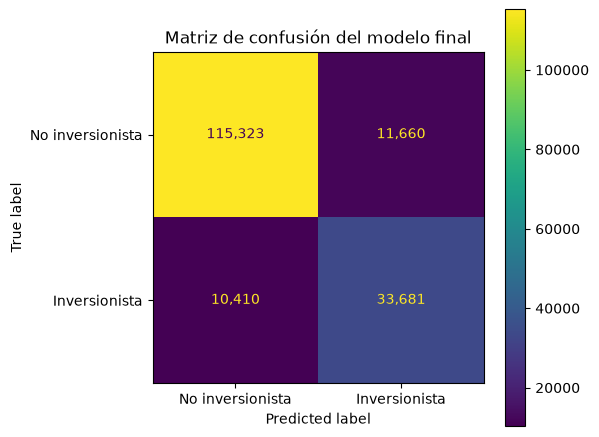

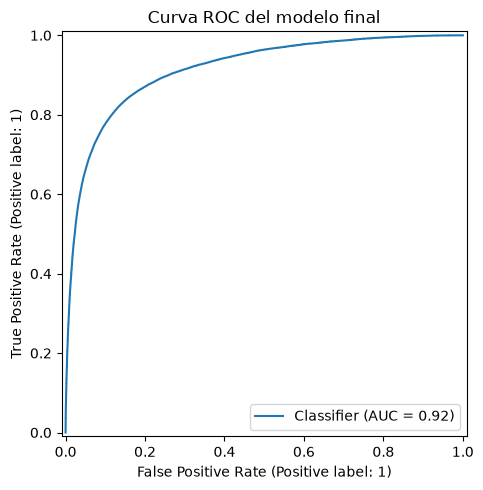

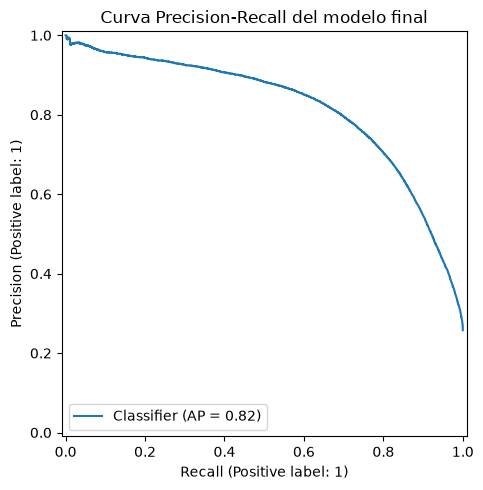

In [82]:
# ============================================================
# 4.9 REENTRENAMIENTO DEL MODELO FINAL Y EVALUACIÓN EN TEST
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# ------------------------------------------------------------
# 1. Consolidar Train + Validation
# ------------------------------------------------------------
# El modelo final se entrena usando toda la información disponible
# antes de Test. El conjunto Test continúa sin participar en el fit.
# ------------------------------------------------------------

X_train_final = pd.concat(
    [X_train, X_validation],
    axis=0
)

y_train_final = pd.concat(
    [y_train, y_validation],
    axis=0
)

print(f"Registros Train final: {len(X_train_final):,}")
print(f"Registros Test: {len(X_test):,}")

print(
    f"Proporción de inversionistas en Train final: "
    f"{y_train_final.mean() * 100:.2f}%"
)

print(
    f"Proporción de inversionistas en Test: "
    f"{y_test.mean() * 100:.2f}%"
)


# ------------------------------------------------------------
# 2. Clonar el modelo finalista
# ------------------------------------------------------------
# Se clona para garantizar que el modelo se entrene nuevamente
# desde cero con Train + Validation.
# ------------------------------------------------------------

modelo_final = clone(
    modelos["XGBoost"]
)


# ------------------------------------------------------------
# 3. Entrenar el modelo definitivo
# ------------------------------------------------------------

modelo_final.fit(
    X_train_final,
    y_train_final
)


# ------------------------------------------------------------
# 4. Obtener probabilidades sobre Test
# ------------------------------------------------------------

probabilidades_test = modelo_final.predict_proba(
    X_test
)[:, 1]


# ------------------------------------------------------------
# 5. Aplicar el umbral elegido previamente en Validation
# ------------------------------------------------------------

UMBRAL_FINAL = 0.62

predicciones_test = (
    probabilidades_test >= UMBRAL_FINAL
).astype(int)


# ------------------------------------------------------------
# 6. Calcular métricas finales
# ------------------------------------------------------------

tn, fp, fn, tp = confusion_matrix(
    y_test,
    predicciones_test
).ravel()

metricas_test = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Valor": [
        accuracy_score(
            y_test,
            predicciones_test
        ),
        balanced_accuracy_score(
            y_test,
            predicciones_test
        ),
        precision_score(
            y_test,
            predicciones_test,
            zero_division=0
        ),
        recall_score(
            y_test,
            predicciones_test,
            zero_division=0
        ),
        f1_score(
            y_test,
            predicciones_test,
            zero_division=0
        ),
        roc_auc_score(
            y_test,
            probabilidades_test
        ),
        average_precision_score(
            y_test,
            probabilidades_test
        )
    ]
})

print("=" * 70)
print("RESULTADOS FINALES EN TEST")
print("=" * 70)

display(
    metricas_test.assign(
        Valor=metricas_test["Valor"].map(
            lambda valor: f"{valor:.4f}"
        )
    )
)

print("\nMatriz de confusión:")
print({
    "TN": int(tn),
    "FP": int(fp),
    "FN": int(fn),
    "TP": int(tp)
})

print("\nReporte de clasificación:")
print(
    classification_report(
        y_test,
        predicciones_test,
        target_names=[
            "No inversionista",
            "Inversionista"
        ],
        digits=4
    )
)


# ------------------------------------------------------------
# 7. Resumen comercial de Test
# ------------------------------------------------------------

clientes_priorizados_test = (
    predicciones_test.sum()
)

porcentaje_priorizado_test = (
    clientes_priorizados_test
    / len(predicciones_test)
    * 100
)

resumen_comercial_test = pd.DataFrame({
    "Indicador": [
        "Umbral final",
        "Clientes evaluados",
        "Clientes priorizados",
        "% base priorizada",
        "Verdaderos positivos",
        "Falsos positivos",
        "Falsos negativos",
        "Verdaderos negativos"
    ],
    "Resultado": [
        f"{UMBRAL_FINAL:.2f}",
        f"{len(X_test):,}",
        f"{clientes_priorizados_test:,}",
        f"{porcentaje_priorizado_test:.2f}%",
        f"{tp:,}",
        f"{fp:,}",
        f"{fn:,}",
        f"{tn:,}"
    ]
})

display(resumen_comercial_test)


# ------------------------------------------------------------
# 8. Gráficos finales de evaluación
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predicciones_test,
    display_labels=[
        "No inversionista",
        "Inversionista"
    ],
    values_format=",d",
    ax=ax
)

ax.set_title(
    "Matriz de confusión del modelo final"
)

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test,
    probabilidades_test,
    ax=ax
)

ax.set_title(
    "Curva ROC del modelo final"
)

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(7, 5))

PrecisionRecallDisplay.from_predictions(
    y_test,
    probabilidades_test,
    ax=ax
)

ax.set_title(
    "Curva Precision-Recall del modelo final"
)

plt.tight_layout()
plt.show()


### 4.9.1 Interpretación de resultados

1. Matriz de confusión

Esta es probablemente la gráfica más importante para un usuario de negocio.

|       Valor | Interpretación                                                                      |
| ----------: | ----------------------------------------------------------------------------------- |
| **116.194** | Clientes correctamente clasificados como no inversionistas.                         |
|  **33.732** | Clientes correctamente identificados como potenciales inversionistas.               |
|  **11.760** | Clientes contactados que realmente no invertirían (falsos positivos).               |
|  **10.359** | Clientes con potencial de inversión que el modelo no identificó (falsos negativos). |


Conclusión para el notebook

El modelo identifica correctamente la mayoría de los clientes con potencial de inversión, clasificando de forma adecuada a 33.732 inversionistas y descartando correctamente a 116.194 no inversionistas. Los errores de clasificación son relativamente bajos frente al tamaño de la muestra, lo que evidencia un buen desempeño para apoyar campañas comerciales.


## 4.9.1 Comparación descriptiva: inversionistas vs no inversionistas

Antes de interpretar el modelo, se comparan ambos grupos directamente sobre variables demográficas, financieras y de relacionamiento. El objetivo es distinguir entre:

- diferencias observadas en los datos;
- variables que posteriormente el modelo utiliza para clasificar.

Esto evita depender exclusivamente de SHAP para explicar el comportamiento de la población.

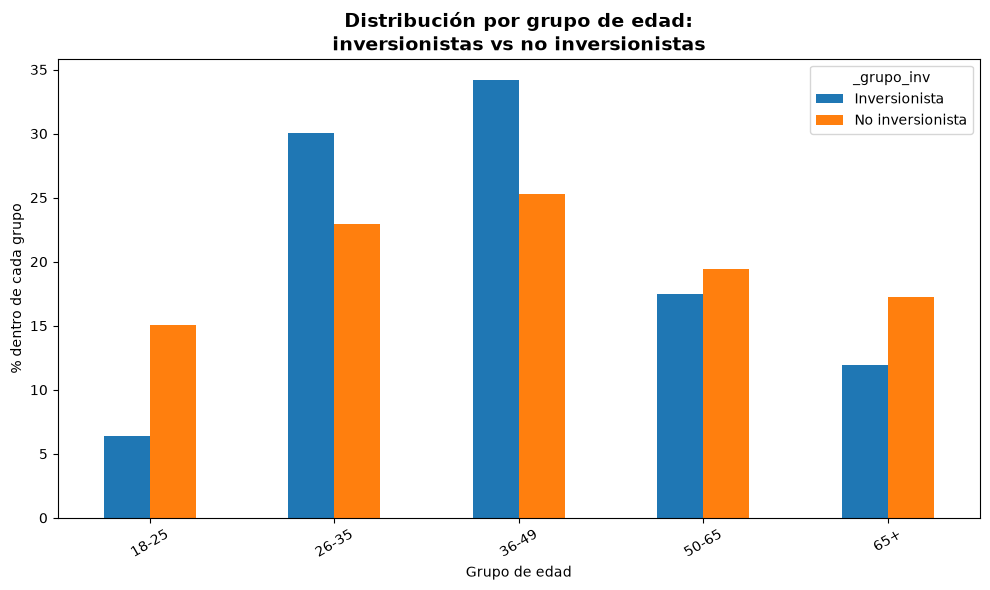

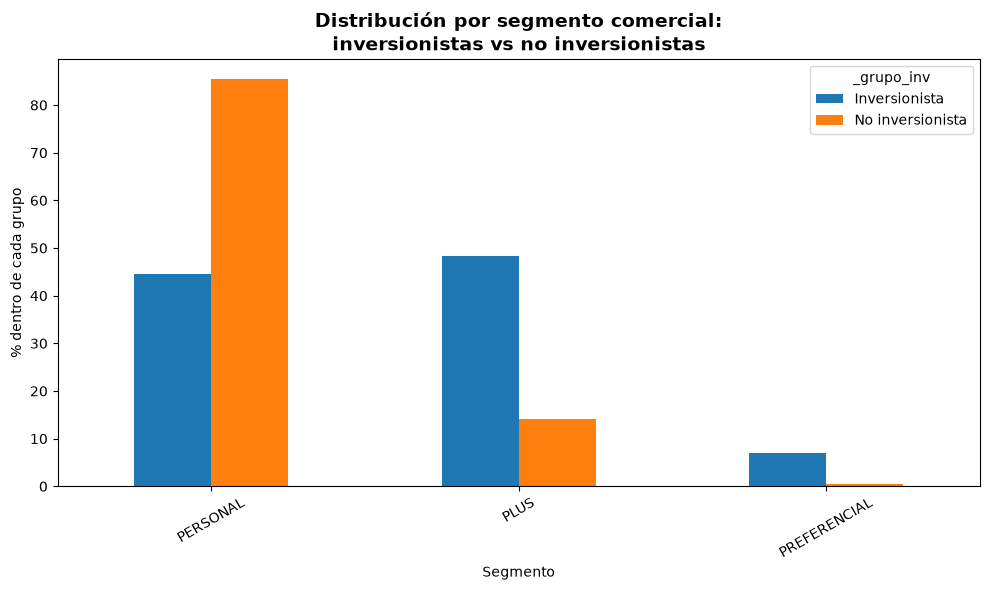

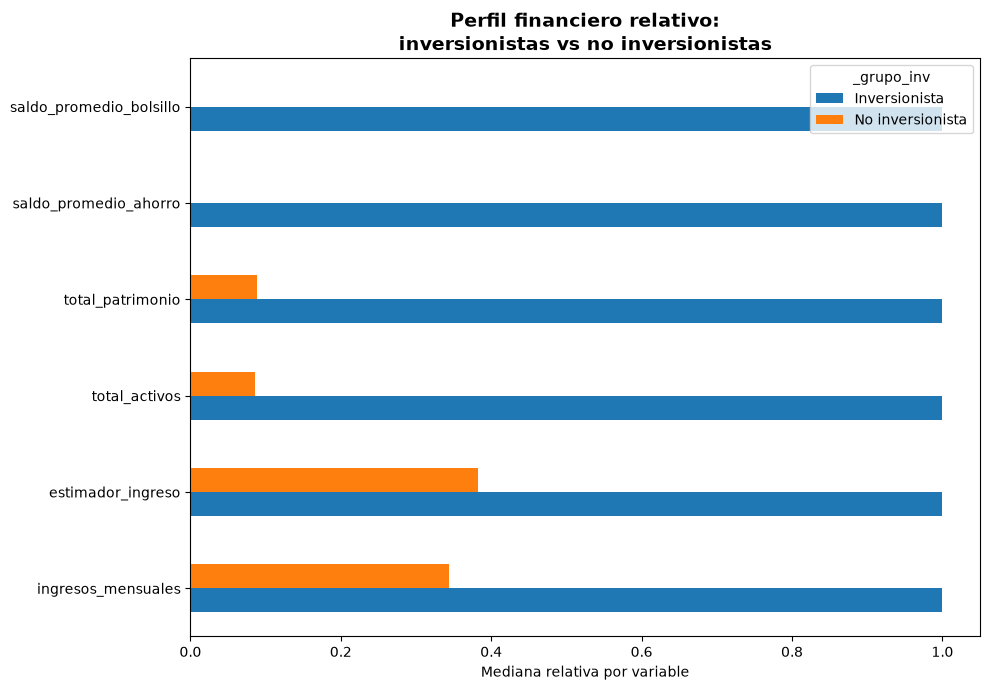

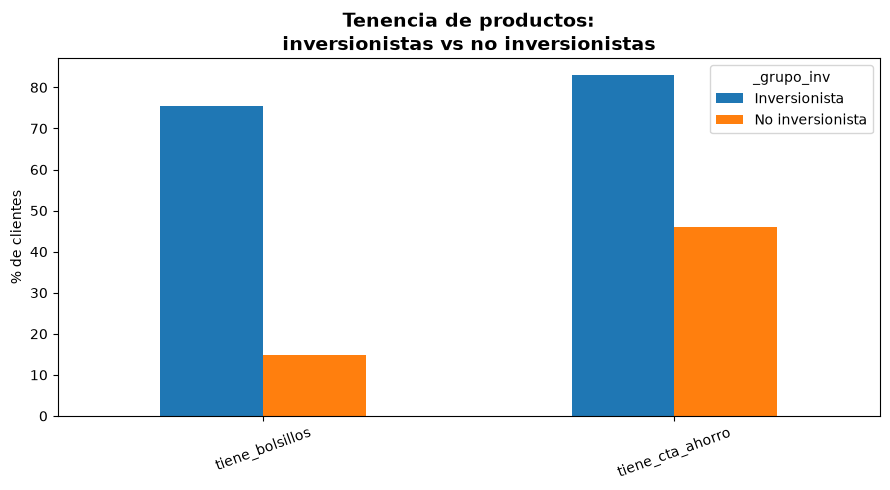

In [83]:
# ============================================================
# 4.9.1 COMPARACIÓN DESCRIPTIVA:
#       INVERSIONISTAS VS NO INVERSIONISTAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_comp_inv = df_modelo_limpio.copy()

# Detectar target disponible
if "es_inversionista" in df_comp_inv.columns:
    target_inv = "es_inversionista"
elif "target" in df_comp_inv.columns:
    target_inv = "target"
else:
    target_inv = None

if target_inv is None:
    print("⚠️ No se encontró una columna de target inversionista/no inversionista.")
else:
    etiquetas_inv = {
        0: "No inversionista",
        1: "Inversionista"
    }

    df_comp_inv["_grupo_inv"] = (
        pd.to_numeric(df_comp_inv[target_inv], errors="coerce")
        .map(etiquetas_inv)
        .fillna("SIN INFORMACION")
    )

    # 1. Distribución por grupo de edad
    if "grupo_edad" in df_comp_inv.columns:
        tabla_edad = pd.crosstab(
            df_comp_inv["grupo_edad"].fillna("SIN INFORMACION"),
            df_comp_inv["_grupo_inv"],
            normalize="columns"
        ).mul(100)

        tabla_edad.plot(
            kind="bar",
            figsize=(10, 6)
        )
        plt.title(
            "Distribución por grupo de edad:\ninversionistas vs no inversionistas",
            fontsize=14,
            fontweight="bold"
        )
        plt.xlabel("Grupo de edad")
        plt.ylabel("% dentro de cada grupo")
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()

    # 2. Distribución por segmento
    if "desc_segmento" in df_comp_inv.columns:
        top_segmentos = (
            df_comp_inv["desc_segmento"]
            .fillna("SIN INFORMACION")
            .value_counts()
            .head(8)
            .index
        )

        tmp = df_comp_inv[
            df_comp_inv["desc_segmento"]
            .fillna("SIN INFORMACION")
            .isin(top_segmentos)
        ].copy()

        tmp["desc_segmento"] = tmp["desc_segmento"].fillna("SIN INFORMACION")

        tabla_seg = pd.crosstab(
            tmp["desc_segmento"],
            tmp["_grupo_inv"],
            normalize="columns"
        ).mul(100)

        tabla_seg.plot(
            kind="bar",
            figsize=(10, 6)
        )
        plt.title(
            "Distribución por segmento comercial:\ninversionistas vs no inversionistas",
            fontsize=14,
            fontweight="bold"
        )
        plt.xlabel("Segmento")
        plt.ylabel("% dentro de cada grupo")
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()

    # 3. Medianas financieras por grupo
    vars_fin_comp = [
        c for c in [
            "ingresos_mensuales",
            "estimador_ingreso",
            "total_activos",
            "total_patrimonio",
            "saldo_promedio_ahorro",
            "saldo_promedio_bolsillo"
        ]
        if c in df_comp_inv.columns
    ]

    if vars_fin_comp:
        resumen_fin = (
            df_comp_inv
            .groupby("_grupo_inv")[vars_fin_comp]
            .median(numeric_only=True)
            .T
        )

        # Normalización por variable para comparar perfiles, no magnitudes absolutas.
        resumen_norm = resumen_fin.div(
            resumen_fin.max(axis=1).replace(0, np.nan),
            axis=0
        )

        resumen_norm.plot(
            kind="barh",
            figsize=(10, 7)
        )
        plt.title(
            "Perfil financiero relativo:\ninversionistas vs no inversionistas",
            fontsize=14,
            fontweight="bold"
        )
        plt.xlabel("Mediana relativa por variable")
        plt.ylabel("")
        plt.tight_layout()
        plt.show()

    # 4. Tenencia de productos no inversionistas
    productos_comp = [
        c for c in [
            "tiene_bolsillos",
            "tiene_cta_ahorro"
        ]
        if c in df_comp_inv.columns
    ]

    if productos_comp:
        resumen_prod = (
            df_comp_inv
            .groupby("_grupo_inv")[productos_comp]
            .mean(numeric_only=True)
            .T
            .mul(100)
        )

        resumen_prod.plot(
            kind="bar",
            figsize=(9, 5)
        )
        plt.title(
            "Tenencia de productos:\ninversionistas vs no inversionistas",
            fontsize=14,
            fontweight="bold"
        )
        plt.ylabel("% de clientes")
        plt.xlabel("")
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.show()

## 4.10 Factores asociados con la afinidad hacia inversiones

Se interpreta el modelo final para identificar qué variables tienen mayor influencia en la clasificación de un cliente como inversionista.

### 4.10.1 Importancia global de variables

,Ranking,Variable,Importancia,Importancia_porcentaje
0,1,tiene_bolsillos,0.699142,69.91%
1,2,saldo_maximo_bolsillo,0.069383,6.94%
2,3,meses_activos_bolsillo,0.058272,5.83%
3,4,saldo_promedio_bolsillo,0.042538,4.25%
4,5,liquidez,0.011356,1.14%
5,6,saldo_promedio_ahorro,0.011003,1.10%
6,7,grupo_edad_65+,0.010883,1.09%
7,8,total_activos,0.009998,1.00%
8,9,desc_segmento_PERSONAL,0.008876,0.89%
9,10,grupo_edad_50-65,0.006946,0.69%


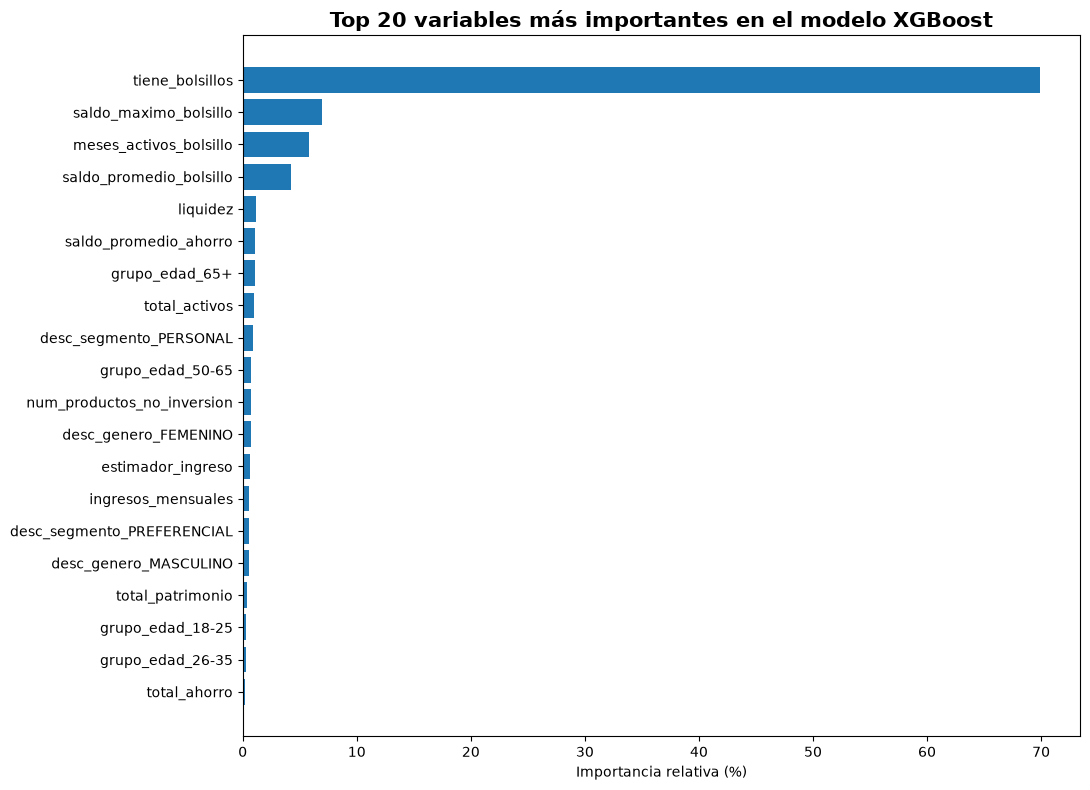

In [84]:
# ============================================================
# 4.10.1 IMPORTANCIA GLOBAL DE VARIABLES
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Extraer el preprocesador y el modelo XGBoost del Pipeline
# ------------------------------------------------------------

preprocesador_final = modelo_final.named_steps["preprocesamiento"]
xgboost_final = modelo_final.named_steps["modelo"]


# ------------------------------------------------------------
# 2. Obtener los nombres reales de las variables transformadas
# ------------------------------------------------------------
# Después del OneHotEncoder ya no existen únicamente las columnas
# originales. Por ejemplo, desc_segmento se convierte en varias
# variables binarias.
# ------------------------------------------------------------

nombres_variables_transformadas = (
    preprocesador_final.get_feature_names_out()
)


# ------------------------------------------------------------
# 3. Extraer la importancia calculada por XGBoost
# ------------------------------------------------------------

importancias_modelo = (
    xgboost_final.feature_importances_
)


# ------------------------------------------------------------
# 4. Validar que ambos arreglos tengan la misma longitud
# ------------------------------------------------------------

if len(nombres_variables_transformadas) != len(importancias_modelo):
    raise ValueError(
        "La cantidad de nombres transformados no coincide con "
        "la cantidad de importancias del modelo."
    )


# ------------------------------------------------------------
# 5. Construir tabla de importancia
# ------------------------------------------------------------

tabla_importancia = pd.DataFrame({
    "Variable": nombres_variables_transformadas,
    "Importancia": importancias_modelo
})


# Limpiar los prefijos generados por ColumnTransformer:
# numericas__total_patrimonio -> total_patrimonio
# categoricas__desc_segmento_PLUS -> desc_segmento_PLUS

tabla_importancia["Variable"] = (
    tabla_importancia["Variable"]
    .str.replace("numericas__", "", regex=False)
    .str.replace("categoricas__", "", regex=False)
)


# Ordenar de mayor a menor

tabla_importancia = (
    tabla_importancia
    .sort_values(
        by="Importancia",
        ascending=False
    )
    .reset_index(drop=True)
)


# Agregar ranking y porcentaje de importancia

tabla_importancia["Ranking"] = (
    tabla_importancia.index + 1
)

tabla_importancia["Importancia_porcentaje"] = (
    tabla_importancia["Importancia"]
    / tabla_importancia["Importancia"].sum()
    * 100
)


# Reordenar columnas

tabla_importancia = tabla_importancia[
    [
        "Ranking",
        "Variable",
        "Importancia",
        "Importancia_porcentaje"
    ]
]


# ------------------------------------------------------------
# 6. Mostrar Top 20
# ------------------------------------------------------------

top20_importancia = tabla_importancia.head(20).copy()

top20_presentacion = top20_importancia.copy()

top20_presentacion["Importancia"] = (
    top20_presentacion["Importancia"]
    .map(lambda valor: f"{valor:.6f}")
)

top20_presentacion["Importancia_porcentaje"] = (
    top20_presentacion["Importancia_porcentaje"]
    .map(lambda valor: f"{valor:.2f}%")
)

display(top20_presentacion)


# ------------------------------------------------------------
# 7. Gráfico Top 20
# ------------------------------------------------------------

plt.figure(figsize=(11, 8))

plt.barh(
    top20_importancia["Variable"][::-1],
    top20_importancia["Importancia_porcentaje"][::-1]
)

plt.title(
    "Top 20 variables más importantes en el modelo XGBoost",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Importancia relativa (%)")
plt.ylabel("")

plt.tight_layout()
plt.show()


# 5. Caracterización de los inversionistas y estimación inicial del monto

Una vez identificado el problema de afinidad hacia inversiones, el análisis se concentra únicamente en clientes inversionistas.

Esta sección responde dos preguntas:

1. **¿Cómo se distribuyen los montos de inversión y qué heterogeneidad existe entre los inversionistas?**
2. **¿Qué tan bien puede un único modelo estimar el monto potencial de inversión?**

El modelo único funciona como línea base para evaluar posteriormente si la especialización por perfiles aporta valor adicional.

## 5.1 Población inversionista y definición del monto objetivo

Se conservan clientes con inversión positiva y se define `total_inversiones` como variable objetivo. Los valores extremos financieramente válidos no se eliminan, ya que pueden representar clientes estratégicos de alto valor.

In [85]:
# ============================================================
# 5.1 POBLACIÓN Y VARIABLE OBJETIVO DE REGRESIÓN
# ============================================================

import numpy as np
import pandas as pd

ID_REG = "numero_id"
TARGET_REG = "total_inversiones"

columnas_requeridas_reg = [
    ID_REG,
    TARGET_REG,
    "es_inversionista"
]

faltantes_reg = [
    c for c in columnas_requeridas_reg
    if c not in df_modelo_limpio.columns
]

if faltantes_reg:
    raise KeyError(
        f"Faltan columnas requeridas para regresión: {faltantes_reg}"
    )

df_regresion = (
    df_modelo_limpio
    .loc[
        (df_modelo_limpio["es_inversionista"] == 1)
        & (df_modelo_limpio[TARGET_REG] > 0)
    ]
    .copy()
)

y_reg_log = np.log1p(df_regresion[TARGET_REG])

print(f"Clientes para regresión: {len(df_regresion):,}")
print(f"Mediana del monto: ${df_regresion[TARGET_REG].median():,.0f}")
print(f"Máximo del monto: ${df_regresion[TARGET_REG].max():,.0f}")


Clientes para regresión: 220,320
Mediana del monto: $2,181,482
Máximo del monto: $5,250,000,000


## 5.2 Distribución y comportamiento del monto de inversión

Se analiza la distribución original de `total_inversiones` y su transformación logarítmica. La elevada dispersión del target permite evaluar si existen distintos comportamientos dentro de la población inversionista.

,count,mean,std,min,25%,50%,75%,max
total_inversiones,220320.0,2.265923e+07,7.309246e+07,0.05,22156.0225,2181481.6,18000000.0,5.250000e+09


,Escala,Asimetría,Curtosis
0,Original,16.36,590.73
1,Log1p,-0.57,-0.68


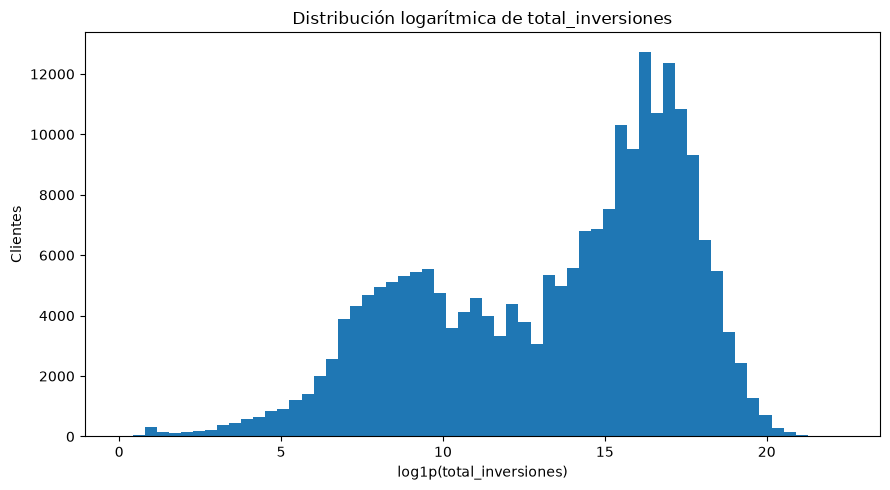

In [86]:
# ============================================================
# 5.2 ANÁLISIS DEL TARGET DE REGRESIÓN
# ============================================================

import matplotlib.pyplot as plt

resumen_target_reg = pd.DataFrame({
    "Escala": ["Original", "Log1p"],
    "Asimetría": [
        df_regresion[TARGET_REG].skew(),
        y_reg_log.skew()
    ],
    "Curtosis": [
        df_regresion[TARGET_REG].kurtosis(),
        y_reg_log.kurtosis()
    ]
})

display(df_regresion[TARGET_REG].describe().to_frame().T)
display(resumen_target_reg.round(2))

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(y_reg_log, bins=60)
ax.set_title("Distribución logarítmica de total_inversiones")
ax.set_xlabel("log1p(total_inversiones)")
ax.set_ylabel("Clientes")
plt.tight_layout()
plt.show()


## 5.3 Variables disponibles para estimar el monto y control de fuga

Se excluyen identificadores, variables objetivo y características de productos de inversión que formen directa o indirectamente parte de `total_inversiones`.

In [87]:
# ============================================================
# 5.3 VARIABLES DE REGRESIÓN Y CONTROL DE FUGA
# ============================================================

variables_prohibidas_reg = {
    "numero_id", "total_inversiones", "es_inversionista",
    "segmento_inversion", "num_productos", "num_productos_inversion",
    "tiene_fiducuenta", "tiene_inversion_virtual", "tiene_cdt", "tiene_investbot",
    "saldo_actual_fiducuenta", "saldo_promedio_fiducuenta",
    "saldo_maximo_fiducuenta", "saldo_minimo_fiducuenta", "meses_activos_fiducuenta",
    "saldo_actual_inv_virtual", "saldo_promedio_inv_virtual",
    "saldo_maximo_inv_virtual", "saldo_minimo_inv_virtual", "meses_activos_inv_virtual",
    "saldo_actual_cdt", "saldo_promedio_cdt", "saldo_maximo_cdt",
    "saldo_minimo_cdt", "meses_activos_cdt",
    "saldo_actual_investbot", "saldo_promedio_investbot",
    "saldo_maximo_investbot", "saldo_minimo_investbot", "meses_activos_investbot"
}

variables_candidatas_reg = [
    c for c in df_regresion.columns
    if c not in variables_prohibidas_reg
]

fugas_reg = set(variables_candidatas_reg) & variables_prohibidas_reg
assert not fugas_reg, f"Fuga detectada: {sorted(fugas_reg)}"

X_reg = df_regresion[variables_candidatas_reg].copy()
ids_reg = df_regresion[ID_REG].copy()

print(f"Variables candidatas de regresión: {len(variables_candidatas_reg)}")
print("✅ Control de fuga superado.")


Variables candidatas de regresión: 33
✅ Control de fuga superado.


## 5.4 Particiones para el modelado del monto

Se mantiene una división 60/20/20 para Train, Validation y Test. Toda transformación aprendida se ajusta únicamente con Train.

In [88]:
# ============================================================
# 5.4 PARTICIONES DE REGRESIÓN
# ============================================================

from sklearn.model_selection import train_test_split

(
    X_trainval_reg, X_test_reg,
    y_trainval_reg, y_test_reg,
    ids_trainval_reg, ids_test_reg
) = train_test_split(
    X_reg, y_reg_log, ids_reg,
    test_size=0.20,
    random_state=42
)

(
    X_train_reg, X_validation_reg,
    y_train_reg, y_validation_reg,
    ids_train_reg, ids_validation_reg
) = train_test_split(
    X_trainval_reg, y_trainval_reg, ids_trainval_reg,
    test_size=0.25,
    random_state=42
)

assert set(ids_train_reg).isdisjoint(set(ids_validation_reg))
assert set(ids_train_reg).isdisjoint(set(ids_test_reg))
assert set(ids_validation_reg).isdisjoint(set(ids_test_reg))

resumen_particiones_reg = pd.DataFrame({
    "Conjunto": ["Train", "Validation", "Test"],
    "Registros": [len(X_train_reg), len(X_validation_reg), len(X_test_reg)],
    "Porcentaje": [
        len(X_train_reg) / len(X_reg) * 100,
        len(X_validation_reg) / len(X_reg) * 100,
        len(X_test_reg) / len(X_reg) * 100
    ],
    "Mediana_monto": [
        np.expm1(y_train_reg).median(),
        np.expm1(y_validation_reg).median(),
        np.expm1(y_test_reg).median()
    ]
})

display(resumen_particiones_reg.round(2))
print("⚠️ Test permanece aislado hasta congelar el modelo final.")


,Conjunto,Registros,Porcentaje,Mediana_monto
0,Train,132192,60.0,2153593.68
1,Validation,44064,20.0,2207979.36
2,Test,44064,20.0,2225053.50


⚠️ Test permanece aislado hasta congelar el modelo final.


## 5.5 Ingeniería y selección de características para inversionistas

Se construyen ratios financieros, transformaciones robustas y variables derivadas orientadas a representar la capacidad y el comportamiento financiero. Posteriormente se audita redundancia y se seleccionan características usando únicamente Train.

In [89]:
# ============================================================
# 5.5 INGENIERÍA Y SELECCIÓN DE CARACTERÍSTICAS
# ============================================================
#
# Este bloque:
# 1. Construye ratios financieros con división segura.
# 2. Crea transformaciones logarítmicas robustas.
# 3. Audita calidad y redundancia.
# 4. Entrena un XGBoost auxiliar únicamente con Train.
# 5. Compara escenarios de selección y elige uno parsimonioso.
#
# Validation se usa para comparar escenarios.
# Test permanece aislado.
# ============================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score
)
from xgboost import XGBRegressor


# ------------------------------------------------------------
# 1. Copia de trabajo
# ------------------------------------------------------------

df_regresion_features = df_regresion.copy()


# ------------------------------------------------------------
# 2. Funciones auxiliares
# ------------------------------------------------------------

def division_segura(numerador, denominador):
    """Divide conservando NaN cuando el denominador es cero."""
    denominador_seguro = denominador.replace(0, np.nan)
    resultado = numerador.divide(denominador_seguro)
    return resultado.replace([np.inf, -np.inf], np.nan)


def log_con_signo(serie):
    """Transformación sign(x) * log1p(abs(x))."""
    return np.sign(serie) * np.log1p(np.abs(serie))


def construir_onehot():
    """Compatibilidad entre versiones de scikit-learn."""
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=100,
            sparse_output=True
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=100,
            sparse=True
        )


# ------------------------------------------------------------
# 3. Ratios financieros
# ------------------------------------------------------------

ratios_regresion = {
    "ratio_liquidez_ingreso": (
        "liquidez", "ingresos_mensuales"
    ),
    "ratio_patrimonio_ingreso": (
        "total_patrimonio", "ingresos_mensuales"
    ),
    "ratio_activos_ingreso": (
        "total_activos", "ingresos_mensuales"
    ),
    "ratio_ahorro_ingreso": (
        "saldo_promedio_ahorro", "ingresos_mensuales"
    ),
    "ratio_liquidez_patrimonio": (
        "liquidez", "total_patrimonio"
    ),
    "ratio_ahorro_patrimonio": (
        "saldo_promedio_ahorro", "total_patrimonio"
    ),
    "ratio_liquidez_activos": (
        "liquidez", "total_activos"
    ),
    "ratio_bolsillo_ahorro": (
        "saldo_promedio_bolsillo", "saldo_promedio_ahorro"
    ),
    "actividad_bolsillo": (
        "saldo_promedio_bolsillo", "meses_activos_bolsillo"
    ),
}

for nueva, (numerador, denominador) in ratios_regresion.items():
    if numerador in df_regresion_features.columns and denominador in df_regresion_features.columns:
        df_regresion_features[nueva] = division_segura(
            df_regresion_features[numerador],
            df_regresion_features[denominador]
        )


# ------------------------------------------------------------
# 4. Transformaciones logarítmicas
# ------------------------------------------------------------

variables_log_positivas = [
    "ingresos_mensuales",
    "estimador_ingreso",
    "total_activos",
    "saldo_promedio_ahorro",
    "saldo_promedio_bolsillo",
    "saldo_maximo_bolsillo",
]

variables_log_signo = [
    "capacidad_ahorro",
    "liquidez",
    "total_patrimonio",
]

for variable in variables_log_positivas:
    if variable in df_regresion_features.columns:
        serie = df_regresion_features[variable].clip(lower=0)
        df_regresion_features[f"log_{variable}"] = np.log1p(serie)

for variable in variables_log_signo:
    if variable in df_regresion_features.columns:
        df_regresion_features[f"log_{variable}"] = log_con_signo(
            df_regresion_features[variable]
        )


# ------------------------------------------------------------
# 5. Eliminar redundancia ya identificada
# ------------------------------------------------------------

df_regresion_features.drop(
    columns=["ratio_ahorro_patrimonio"],
    errors="ignore",
    inplace=True
)


# ------------------------------------------------------------
# 6. Construir variables candidatas sin fuga
# ------------------------------------------------------------

variables_prohibidas_feature_selection = set(
    variables_prohibidas_reg
).union({
    "segmento_inversion"
})

variables_candidatas_reg = [
    columna
    for columna in df_regresion_features.columns
    if columna not in variables_prohibidas_feature_selection
    and columna != ID_REG
    and not df_regresion_features[columna].isna().all()
]

X_features_reg = df_regresion_features[variables_candidatas_reg].copy()

# Recuperar exactamente las mismas particiones de la sección 5.4.
X_train_fs = X_features_reg.loc[X_train_reg.index].copy()
X_validation_fs = X_features_reg.loc[X_validation_reg.index].copy()
X_test_fs = X_features_reg.loc[X_test_reg.index].copy()

y_train_fs = y_train_reg.copy()
y_validation_fs = y_validation_reg.copy()
y_test_fs = y_test_reg.copy()

assert X_train_fs.index.equals(y_train_fs.index)
assert X_validation_fs.index.equals(y_validation_fs.index)
assert X_test_fs.index.equals(y_test_fs.index)


# ------------------------------------------------------------
# 7. Auditoría rápida de las nuevas variables
# ------------------------------------------------------------

variables_nuevas_reg = [
    c for c in X_features_reg.columns
    if c not in X_reg.columns
]

auditoria_features_reg = pd.DataFrame({
    "Variable": variables_nuevas_reg,
    "Missing": [
        X_features_reg[c].isna().sum()
        for c in variables_nuevas_reg
    ],
    "Infinitos": [
        np.isinf(
            pd.to_numeric(
                X_features_reg[c],
                errors="coerce"
            ).fillna(0)
        ).sum()
        for c in variables_nuevas_reg
    ],
    "Unicos": [
        X_features_reg[c].nunique(dropna=True)
        for c in variables_nuevas_reg
    ],
})

print("=" * 70)
print("AUDITORÍA DE CARACTERÍSTICAS CREADAS")
print("=" * 70)
display(auditoria_features_reg)


# ------------------------------------------------------------
# 8. Preprocesador auxiliar para selección
# ------------------------------------------------------------

variables_numericas_fs = (
    X_train_fs
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

variables_categoricas_fs = [
    c for c in X_train_fs.columns
    if c not in variables_numericas_fs
]

preprocesador_fs = ColumnTransformer(
    transformers=[
        (
            "numericas",
            Pipeline(
                steps=[
                    (
                        "imputacion",
                        SimpleImputer(strategy="median")
                    )
                ]
            ),
            variables_numericas_fs
        ),
        (
            "categoricas",
            Pipeline(
                steps=[
                    (
                        "imputacion",
                        SimpleImputer(
                            strategy="constant",
                            fill_value="SIN INFORMACION"
                        )
                    ),
                    (
                        "onehot",
                        construir_onehot()
                    )
                ]
            ),
            variables_categoricas_fs
        ),
    ],
    remainder="drop"
)


# ------------------------------------------------------------
# 9. XGBoost auxiliar
# ------------------------------------------------------------

modelo_xgb_auxiliar = Pipeline(
    steps=[
        ("preprocesamiento", preprocesador_fs),
        (
            "modelo",
            XGBRegressor(
                n_estimators=500,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.80,
                colsample_bytree=0.80,
                min_child_weight=10,
                reg_alpha=0.10,
                reg_lambda=1.00,
                objective="reg:squarederror",
                eval_metric="rmse",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

inicio = time.time()
modelo_xgb_auxiliar.fit(X_train_fs, y_train_fs)
tiempo_xgb_auxiliar = time.time() - inicio

pred_aux_log = modelo_xgb_auxiliar.predict(X_validation_fs)
pred_aux_pesos = np.expm1(np.clip(pred_aux_log, 0, None))
real_validation_pesos = np.expm1(np.asarray(y_validation_fs))

metricas_xgb_auxiliar = pd.DataFrame({
    "Metrica": [
        "MAE_log",
        "RMSE_log",
        "R2_log",
        "MAE_pesos",
        "MedAE_pesos",
        "RMSE_pesos",
        "R2_pesos",
        "Tiempo_segundos",
    ],
    "Valor": [
        mean_absolute_error(y_validation_fs, pred_aux_log),
        np.sqrt(mean_squared_error(y_validation_fs, pred_aux_log)),
        r2_score(y_validation_fs, pred_aux_log),
        mean_absolute_error(real_validation_pesos, pred_aux_pesos),
        median_absolute_error(real_validation_pesos, pred_aux_pesos),
        np.sqrt(mean_squared_error(real_validation_pesos, pred_aux_pesos)),
        r2_score(real_validation_pesos, pred_aux_pesos),
        tiempo_xgb_auxiliar,
    ]
})

print("\nMÉTRICAS DEL MODELO AUXILIAR")
display(metricas_xgb_auxiliar)


# ------------------------------------------------------------
# 10. Ranking XGBoost
# ------------------------------------------------------------

preprocesador_entrenado_fs = (
    modelo_xgb_auxiliar.named_steps["preprocesamiento"]
)

modelo_entrenado_fs = (
    modelo_xgb_auxiliar.named_steps["modelo"]
)

nombres_transformados_fs = (
    preprocesador_entrenado_fs.get_feature_names_out()
)

nombres_limpios_fs = [
    nombre
    .replace("numericas__", "")
    .replace("categoricas__", "")
    for nombre in nombres_transformados_fs
]

ranking_xgb_fs = pd.DataFrame({
    "Variable": nombres_limpios_fs,
    "Importancia_XGB": modelo_entrenado_fs.feature_importances_,
}).sort_values(
    "Importancia_XGB",
    ascending=False
).reset_index(drop=True)

ranking_xgb_fs["Ranking_XGB"] = np.arange(
    1,
    len(ranking_xgb_fs) + 1
)

display(ranking_xgb_fs.head(30))


# ------------------------------------------------------------
# 11. SHAP para ranking combinado
# ------------------------------------------------------------

try:
    import shap

    muestra_shap = X_train_fs.sample(
        n=min(5000, len(X_train_fs)),
        random_state=42
    )

    X_shap_transformado = preprocesador_entrenado_fs.transform(
        muestra_shap
    )

    if hasattr(X_shap_transformado, "toarray"):
        X_shap_transformado = X_shap_transformado.toarray()

    explicador_fs = shap.TreeExplainer(modelo_entrenado_fs)
    valores_shap_fs = explicador_fs.shap_values(
        X_shap_transformado
    )

    if isinstance(valores_shap_fs, list):
        valores_shap_fs = valores_shap_fs[0]

    importancia_shap = np.abs(
        valores_shap_fs
    ).mean(axis=0)

    ranking_shap_fs = pd.DataFrame({
        "Variable": nombres_limpios_fs,
        "Importancia_SHAP": importancia_shap,
    })

    suma_shap = ranking_shap_fs["Importancia_SHAP"].sum()
    ranking_shap_fs["Importancia_SHAP_norm"] = np.where(
        suma_shap > 0,
        ranking_shap_fs["Importancia_SHAP"] / suma_shap,
        0
    )

except Exception as error_shap:
    print(
        "SHAP no pudo calcularse. Se utilizará únicamente "
        f"la importancia XGBoost. Detalle: {error_shap}"
    )

    ranking_shap_fs = pd.DataFrame({
        "Variable": ranking_xgb_fs["Variable"],
        "Importancia_SHAP": 0.0,
        "Importancia_SHAP_norm": 0.0,
    })


ranking_combinado_fs = (
    ranking_xgb_fs[
        ["Variable", "Importancia_XGB"]
    ]
    .merge(
        ranking_shap_fs[
            ["Variable", "Importancia_SHAP_norm"]
        ],
        on="Variable",
        how="left"
    )
    .fillna(0)
)

# Si SHAP estuvo disponible, ponderación 50/50.
# Si no, el ranking depende de XGBoost.
hay_shap = (
    ranking_combinado_fs["Importancia_SHAP_norm"].sum() > 0
)

if hay_shap:
    ranking_combinado_fs["Puntaje"] = (
        0.50 * ranking_combinado_fs["Importancia_XGB"]
        + 0.50 * ranking_combinado_fs["Importancia_SHAP_norm"]
    )
else:
    ranking_combinado_fs["Puntaje"] = (
        ranking_combinado_fs["Importancia_XGB"]
    )

ranking_combinado_fs = (
    ranking_combinado_fs
    .sort_values("Puntaje", ascending=False)
    .reset_index(drop=True)
)

ranking_combinado_fs["Ranking"] = np.arange(
    1,
    len(ranking_combinado_fs) + 1
)

display(ranking_combinado_fs.head(30))


# ------------------------------------------------------------
# 12. Traducir columnas One-Hot a variables originales
# ------------------------------------------------------------

def recuperar_variable_original(
    variable_transformada,
    numericas,
    categoricas
):
    if variable_transformada in numericas:
        return variable_transformada

    for variable in sorted(
        categoricas,
        key=len,
        reverse=True
    ):
        if variable_transformada.startswith(
            f"{variable}_"
        ):
            return variable

    return None


ranking_combinado_fs["Variable_original"] = (
    ranking_combinado_fs["Variable"].apply(
        lambda variable: recuperar_variable_original(
            variable,
            variables_numericas_fs,
            variables_categoricas_fs
        )
    )
)


def variables_originales_top(top_n):
    return (
        ranking_combinado_fs
        .head(top_n)["Variable_original"]
        .dropna()
        .drop_duplicates()
        .tolist()
    )


escenarios_variables_reg = {
    "Top 15": variables_originales_top(15),
    "Top 20": variables_originales_top(20),
    "Top 25": variables_originales_top(25),
    "Top 30": variables_originales_top(30),
    "Todas": variables_candidatas_reg,
}


# ------------------------------------------------------------
# 13. Comparar escenarios con el mismo XGBoost
# ------------------------------------------------------------

def construir_preprocesador_reg(
    X_train,
    variables
):
    numericas = (
        X_train[variables]
        .select_dtypes(include=np.number)
        .columns
        .tolist()
    )

    categoricas = [
        c for c in variables
        if c not in numericas
    ]

    transformadores = []

    if numericas:
        transformadores.append(
            (
                "numericas",
                Pipeline(
                    steps=[
                        (
                            "imputacion",
                            SimpleImputer(strategy="median")
                        )
                    ]
                ),
                numericas
            )
        )

    if categoricas:
        transformadores.append(
            (
                "categoricas",
                Pipeline(
                    steps=[
                        (
                            "imputacion",
                            SimpleImputer(
                                strategy="constant",
                                fill_value="SIN INFORMACION"
                            )
                        ),
                        (
                            "onehot",
                            construir_onehot()
                        )
                    ]
                ),
                categoricas
            )
        )

    return ColumnTransformer(
        transformers=transformadores,
        remainder="drop"
    )


resultados_escenarios_reg = []
modelos_escenarios_reg = {}

for escenario, variables in escenarios_variables_reg.items():

    preprocesador_escenario = construir_preprocesador_reg(
        X_train_fs,
        variables
    )

    modelo_escenario = Pipeline(
        steps=[
            ("preprocesamiento", preprocesador_escenario),
            (
                "modelo",
                XGBRegressor(
                    n_estimators=500,
                    max_depth=6,
                    learning_rate=0.05,
                    subsample=0.80,
                    colsample_bytree=0.80,
                    min_child_weight=10,
                    reg_alpha=0.10,
                    reg_lambda=1.00,
                    objective="reg:squarederror",
                    eval_metric="rmse",
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]
    )

    inicio = time.time()
    modelo_escenario.fit(
        X_train_fs[variables],
        y_train_fs
    )
    tiempo = time.time() - inicio

    pred_log = modelo_escenario.predict(
        X_validation_fs[variables]
    )
    pred_pesos = np.expm1(np.clip(pred_log, 0, None))

    resultados_escenarios_reg.append({
        "Escenario": escenario,
        "Variables_originales": len(variables),
        "MAE_log": mean_absolute_error(
            y_validation_fs,
            pred_log
        ),
        "RMSE_log": np.sqrt(
            mean_squared_error(
                y_validation_fs,
                pred_log
            )
        ),
        "R2_log": r2_score(
            y_validation_fs,
            pred_log
        ),
        "MAE_pesos": mean_absolute_error(
            real_validation_pesos,
            pred_pesos
        ),
        "MedAE_pesos": median_absolute_error(
            real_validation_pesos,
            pred_pesos
        ),
        "RMSE_pesos": np.sqrt(
            mean_squared_error(
                real_validation_pesos,
                pred_pesos
            )
        ),
        "R2_pesos": r2_score(
            real_validation_pesos,
            pred_pesos
        ),
        "Tiempo_segundos": tiempo,
    })

    modelos_escenarios_reg[escenario] = modelo_escenario


tabla_escenarios_reg = (
    pd.DataFrame(resultados_escenarios_reg)
    .sort_values(
        ["MAE_log", "RMSE_log"],
        ascending=True
    )
    .reset_index(drop=True)
)

print("\nCOMPARACIÓN DE ESCENARIOS")
display(tabla_escenarios_reg)


# ------------------------------------------------------------
# 14. Criterio de parsimonia
# ------------------------------------------------------------
#
# Se elige el escenario más pequeño cuyo MAE_log esté a no más
# de 0.5% del mejor MAE observado.
# ------------------------------------------------------------

mejor_mae = tabla_escenarios_reg["MAE_log"].min()
tolerancia_mae = mejor_mae * 1.005

candidatos_parsimoniosos = (
    tabla_escenarios_reg
    .loc[
        tabla_escenarios_reg["MAE_log"]
        <= tolerancia_mae
    ]
    .sort_values(
        ["Variables_originales", "MAE_log"],
        ascending=[True, True]
    )
)

mejor_escenario_reg = (
    candidatos_parsimoniosos.iloc[0]["Escenario"]
)

variables_finales_reg = (
    escenarios_variables_reg[mejor_escenario_reg]
)

print(
    f"\nEscenario seleccionado: {mejor_escenario_reg}"
)
print(
    f"Cantidad de variables: {len(variables_finales_reg)}"
)

for variable in variables_finales_reg:
    print(f"• {variable}")

AUDITORÍA DE CARACTERÍSTICAS CREADAS


,Variable,Missing,Infinitos,Unicos
0,ratio_liquidez_ingreso,352,0,181442
1,ratio_patrimonio_ingreso,352,0,204679
2,ratio_activos_ingreso,352,0,206734
3,ratio_ahorro_ingreso,352,0,181555
4,ratio_liquidez_patrimonio,10523,0,175686
5,ratio_liquidez_activos,5875,0,179243
6,ratio_bolsillo_ahorro,38671,0,130204
7,actividad_bolsillo,54082,0,106401
8,log_ingresos_mensuales,10,0,173313
9,log_estimador_ingreso,12975,0,186447



MÉTRICAS DEL MODELO AUXILIAR


,Metrica,Valor
0,MAE_log,2.916224e+00
1,RMSE_log,3.529841e+00
2,R2_log,2.209770e-01
3,MAE_pesos,2.056994e+07
4,MedAE_pesos,2.607401e+06
5,RMSE_pesos,6.757395e+07
6,R2_pesos,2.971780e-02
7,Tiempo_segundos,5.225019e+00


,Variable,Importancia_XGB,Ranking_XGB
0,tiene_bolsillos,0.128786,1
1,grupo_edad_65+,0.119532,2
2,grupo_edad_50-65,0.096526,3
3,grupo_edad_26-35,0.068656,4
4,desc_segmento_PREFERENCIAL,0.056963,5
5,actividad_bolsillo,0.056790,6
6,saldo_promedio_ahorro,0.047405,7
7,grupo_edad_36-49,0.033460,8
8,log_saldo_promedio_ahorro,0.026805,9
9,num_productos_no_inversion,0.025255,10


C:\Users\alejo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Variable,Importancia_XGB,Importancia_SHAP_norm,Puntaje,Ranking
0,grupo_edad_65+,0.119532,0.053325,0.086429,1
1,actividad_bolsillo,0.056790,0.090144,0.073467,2
2,grupo_edad_50-65,0.096526,0.044640,0.070583,3
3,tiene_bolsillos,0.128786,0.006284,0.067535,4
4,grupo_edad_26-35,0.068656,0.057779,0.063218,5
5,saldo_promedio_ahorro,0.047405,0.066272,0.056839,6
6,desc_segmento_PREFERENCIAL,0.056963,0.027044,0.042003,7
7,saldo_minimo_bolsillo,0.009501,0.053677,0.031589,8
8,grupo_edad_36-49,0.033460,0.027515,0.030487,9
9,saldo_minimo_ahorro,0.009692,0.051242,0.030467,10



COMPARACIÓN DE ESCENARIOS


,Escenario,Variables_originales,MAE_log,RMSE_log,R2_log,MAE_pesos,MedAE_pesos,RMSE_pesos,R2_pesos,Tiempo_segundos
0,Todas,50,2.916224,3.529841,0.220977,2.056994e+07,2.607401e+06,6.757395e+07,0.029718,4.629000
1,Top 30,25,2.920154,3.532936,0.219610,2.058634e+07,2.616920e+06,6.764955e+07,0.027546,3.013000
2,Top 25,21,2.923788,3.535812,0.218339,2.057996e+07,2.643006e+06,6.751459e+07,0.031422,2.877000
3,Top 20,17,2.927994,3.541253,0.215931,2.067207e+07,2.649654e+06,6.782262e+07,0.022563,2.774998
4,Top 15,12,2.934730,3.546474,0.213618,2.070206e+07,2.667415e+06,6.816861e+07,0.012565,2.058000



Escenario seleccionado: Top 20
Cantidad de variables: 17
• grupo_edad
• actividad_bolsillo
• tiene_bolsillos
• saldo_promedio_ahorro
• desc_segmento
• saldo_minimo_bolsillo
• saldo_minimo_ahorro
• num_productos_no_inversion
• saldo_maximo_bolsillo
• estimador_ingreso
• ratio_activos_ingreso
• total_activos
• log_saldo_promedio_ahorro
• meses_activos_bolsillo
• desc_genero
• ratio_ahorro_ingreso
• saldo_promedio_bolsillo


## 5.6 Modelo único para estimar el monto de inversión

Se comparan Ridge, Árbol de decisión, Random Forest y XGBoost como línea base de regresión.

Las métricas se reportan tanto en escala logarítmica como en pesos. Este modelo único servirá como referencia para evaluar posteriormente modelos especializados por perfil de inversionista.

In [90]:
# ============================================================
# 5.6 COMPARACIÓN DE MODELOS Y EVALUACIÓN FINAL
# ============================================================
#
# Se comparan cuatro familias usando las variables elegidas en
# la sección 5.5. La selección se realiza con Validation.
# Test se usa una única vez después de congelar el ganador.
# ============================================================

import time
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score
)
from xgboost import XGBRegressor


# ------------------------------------------------------------
# 1. Preprocesadores
# ------------------------------------------------------------

variables_numericas_finales_reg = (
    X_train_fs[variables_finales_reg]
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

variables_categoricas_finales_reg = [
    c for c in variables_finales_reg
    if c not in variables_numericas_finales_reg
]

preprocesador_lineal_final_reg = ColumnTransformer(
    transformers=[
        (
            "numericas",
            Pipeline(
                steps=[
                    (
                        "imputacion",
                        SimpleImputer(strategy="median")
                    ),
                    (
                        "escalado",
                        StandardScaler()
                    )
                ]
            ),
            variables_numericas_finales_reg
        ),
        (
            "categoricas",
            Pipeline(
                steps=[
                    (
                        "imputacion",
                        SimpleImputer(
                            strategy="constant",
                            fill_value="SIN INFORMACION"
                        )
                    ),
                    (
                        "onehot",
                        construir_onehot()
                    )
                ]
            ),
            variables_categoricas_finales_reg
        ),
    ],
    remainder="drop"
)

preprocesador_arbol_final_reg = construir_preprocesador_reg(
    X_train_fs,
    variables_finales_reg
)


# ------------------------------------------------------------
# 2. Modelos candidatos
# ------------------------------------------------------------

modelos_finalistas_reg = {
    "Ridge": Pipeline(
        steps=[
            (
                "preprocesamiento",
                preprocesador_lineal_final_reg
            ),
            (
                "modelo",
                Ridge(alpha=1.0)
            )
        ]
    ),

    "Arbol": Pipeline(
        steps=[
            (
                "preprocesamiento",
                preprocesador_arbol_final_reg
            ),
            (
                "modelo",
                DecisionTreeRegressor(
                    max_depth=12,
                    min_samples_split=100,
                    min_samples_leaf=50,
                    random_state=42
                )
            )
        ]
    ),

    "Random Forest": Pipeline(
        steps=[
            (
                "preprocesamiento",
                preprocesador_arbol_final_reg
            ),
            (
                "modelo",
                RandomForestRegressor(
                    n_estimators=250,
                    max_depth=16,
                    min_samples_split=100,
                    min_samples_leaf=30,
                    max_features="sqrt",
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]
    ),

    "XGBoost": Pipeline(
        steps=[
            (
                "preprocesamiento",
                preprocesador_arbol_final_reg
            ),
            (
                "modelo",
                XGBRegressor(
                    n_estimators=500,
                    max_depth=6,
                    learning_rate=0.05,
                    subsample=0.80,
                    colsample_bytree=0.80,
                    min_child_weight=10,
                    reg_alpha=0.10,
                    reg_lambda=1.00,
                    objective="reg:squarederror",
                    eval_metric="rmse",
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]
    ),
}


# ------------------------------------------------------------
# 3. Función de evaluación
# ------------------------------------------------------------

def evaluar_regresor(
    nombre,
    modelo,
    X_train,
    y_train,
    X_eval,
    y_eval
):
    inicio = time.time()
    modelo.fit(X_train, y_train)
    tiempo = time.time() - inicio

    pred_log = modelo.predict(X_eval)
    pred_pesos = np.expm1(np.clip(pred_log, 0, None))
    real_pesos = np.expm1(np.asarray(y_eval))

    resultado = {
        "Modelo": nombre,
        "MAE_log": mean_absolute_error(y_eval, pred_log),
        "RMSE_log": np.sqrt(
            mean_squared_error(y_eval, pred_log)
        ),
        "R2_log": r2_score(y_eval, pred_log),
        "MAE_pesos": mean_absolute_error(
            real_pesos,
            pred_pesos
        ),
        "MedAE_pesos": median_absolute_error(
            real_pesos,
            pred_pesos
        ),
        "RMSE_pesos": np.sqrt(
            mean_squared_error(
                real_pesos,
                pred_pesos
            )
        ),
        "R2_pesos": r2_score(
            real_pesos,
            pred_pesos
        ),
        "Tiempo_segundos": tiempo,
    }

    return resultado, pred_log, pred_pesos


# ------------------------------------------------------------
# 4. Comparación en Validation
# ------------------------------------------------------------

resultados_modelos_reg = []
modelos_entrenados_reg = {}
predicciones_validation_reg = {}

for nombre, modelo in modelos_finalistas_reg.items():

    resultado, pred_log, pred_pesos = evaluar_regresor(
        nombre,
        modelo,
        X_train_fs[variables_finales_reg],
        y_train_fs,
        X_validation_fs[variables_finales_reg],
        y_validation_fs
    )

    resultados_modelos_reg.append(resultado)
    modelos_entrenados_reg[nombre] = modelo
    predicciones_validation_reg[nombre] = {
        "log": pred_log,
        "pesos": pred_pesos
    }


tabla_modelos_reg = (
    pd.DataFrame(resultados_modelos_reg)
    .sort_values(
        ["MAE_log", "RMSE_log"],
        ascending=True
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("COMPARACIÓN DE REGRESORES EN VALIDATION")
print("=" * 70)
display(tabla_modelos_reg)


# ------------------------------------------------------------
# 5. Selección del campeón
# ------------------------------------------------------------

nombre_campeon_reg = tabla_modelos_reg.iloc[0]["Modelo"]
modelo_campeon_validation_reg = (
    modelos_entrenados_reg[nombre_campeon_reg]
)

print(f"\nModelo campeón preliminar: {nombre_campeon_reg}")


# ------------------------------------------------------------
# 6. Reentrenamiento con Train + Validation
# ------------------------------------------------------------

X_trainval_final_reg = pd.concat(
    [
        X_train_fs[variables_finales_reg],
        X_validation_fs[variables_finales_reg]
    ],
    axis=0
)

y_trainval_final_reg = pd.concat(
    [y_train_fs, y_validation_fs],
    axis=0
)

# Clonar evita reutilizar un objeto ya ajustado.
from sklearn.base import clone

modelo_final_reg = clone(
    modelos_finalistas_reg[nombre_campeon_reg]
)

modelo_final_reg.fit(
    X_trainval_final_reg,
    y_trainval_final_reg
)


# ------------------------------------------------------------
# 7. Evaluación única en Test
# ------------------------------------------------------------

pred_test_log_reg = modelo_final_reg.predict(
    X_test_fs[variables_finales_reg]
)

pred_test_pesos_reg = np.expm1(
    np.clip(pred_test_log_reg, 0, None)
)

real_test_pesos_reg = np.expm1(
    np.asarray(y_test_fs)
)

metricas_test_reg = pd.DataFrame({
    "Metrica": [
        "MAE_log",
        "RMSE_log",
        "R2_log",
        "MAE_pesos",
        "MedAE_pesos",
        "RMSE_pesos",
        "R2_pesos",
    ],
    "Valor": [
        mean_absolute_error(
            y_test_fs,
            pred_test_log_reg
        ),
        np.sqrt(
            mean_squared_error(
                y_test_fs,
                pred_test_log_reg
            )
        ),
        r2_score(
            y_test_fs,
            pred_test_log_reg
        ),
        mean_absolute_error(
            real_test_pesos_reg,
            pred_test_pesos_reg
        ),
        median_absolute_error(
            real_test_pesos_reg,
            pred_test_pesos_reg
        ),
        np.sqrt(
            mean_squared_error(
                real_test_pesos_reg,
                pred_test_pesos_reg
            )
        ),
        r2_score(
            real_test_pesos_reg,
            pred_test_pesos_reg
        ),
    ]
})

print("\n" + "=" * 70)
print("EVALUACIÓN FINAL DEL REGRESOR EN TEST")
print("=" * 70)
print(f"Modelo final: {nombre_campeon_reg}")
display(metricas_test_reg)


# Tabla base para ranking comercial posterior.
resultados_test_reg = pd.DataFrame({
    "numero_id": ids_test_reg.values,
    "monto_real": real_test_pesos_reg,
    "monto_predicho_modelo_unico": pred_test_pesos_reg,
    "error_absoluto": np.abs(
        real_test_pesos_reg - pred_test_pesos_reg
    ),
})

COMPARACIÓN DE REGRESORES EN VALIDATION


,Modelo,MAE_log,RMSE_log,R2_log,MAE_pesos,MedAE_pesos,RMSE_pesos,R2_pesos,Tiempo_segundos
0,XGBoost,2.927994,3.541253,0.215931,2.067207e+07,2.649654e+06,6.782262e+07,0.022563,2.759992
1,Random Forest,2.953757,3.549684,0.212194,2.089248e+07,2.636130e+06,6.937295e+07,-0.022633,7.663348
2,Arbol,2.969834,3.605873,0.187056,2.076930e+07,2.751452e+06,6.847492e+07,0.003672,1.837011
3,Ridge,3.071964,3.645526,0.169077,1.340318e+08,2.650775e+06,1.931194e+10,-79247.528498,0.772667



Modelo campeón preliminar: XGBoost

EVALUACIÓN FINAL DEL REGRESOR EN TEST
Modelo final: XGBoost


,Metrica,Valor
0,MAE_log,2.904080e+00
1,RMSE_log,3.513797e+00
2,R2_log,2.218145e-01
3,MAE_pesos,2.082829e+07
4,MedAE_pesos,2.707419e+06
5,RMSE_pesos,6.993580e+07
6,R2_pesos,1.606005e-02


## 5.7 Interpretación y limitaciones del modelo único

Se analiza la importancia de variables, SHAP, error por nivel de inversión y comportamiento del modelo en distintos rangos del target.

Esta sección permite identificar si un único regresor representa adecuadamente toda la heterogeneidad observada entre inversionistas.

ERROR DEL MODELO ÚNICO POR SEGMENTO REAL


,segmento_real,clientes,monto_real_mediano,monto_predicho_mediano,MAE,MedAE
0,Bajo,11016,3.216360e+03,2.060862e+05,8.434925e+05,2.004599e+05
1,Medio,11016,2.978511e+05,4.086712e+05,1.978092e+06,6.178463e+05
2,Alto,11016,7.534140e+06,8.314896e+05,6.978613e+06,5.696699e+06
3,Muy Alto,11016,4.533271e+07,3.100907e+06,7.351298e+07,3.938855e+07


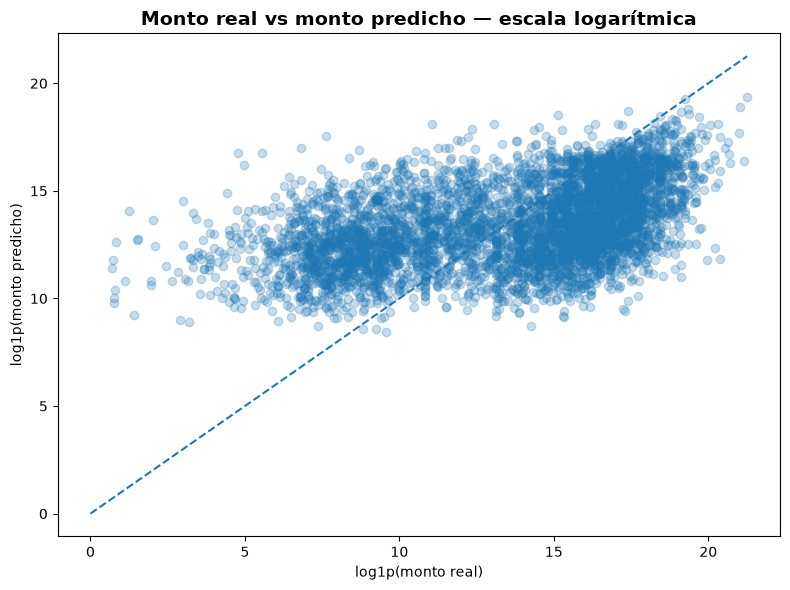


IMPORTANCIA GLOBAL DEL REGRESOR


,Variable,Importancia,Importancia_porcentaje
0,tiene_bolsillos,0.389491,38.949135
1,grupo_edad_50-65,0.112590,11.258951
2,grupo_edad_65+,0.104440,10.443993
3,grupo_edad_26-35,0.066345,6.634511
4,desc_segmento_PREFERENCIAL,0.063319,6.331898
5,log_saldo_promedio_ahorro,0.041657,4.165709
6,actividad_bolsillo,0.033718,3.371827
7,grupo_edad_36-49,0.026906,2.690618
8,saldo_promedio_ahorro,0.022992,2.299170
9,num_productos_no_inversion,0.019540,1.953989


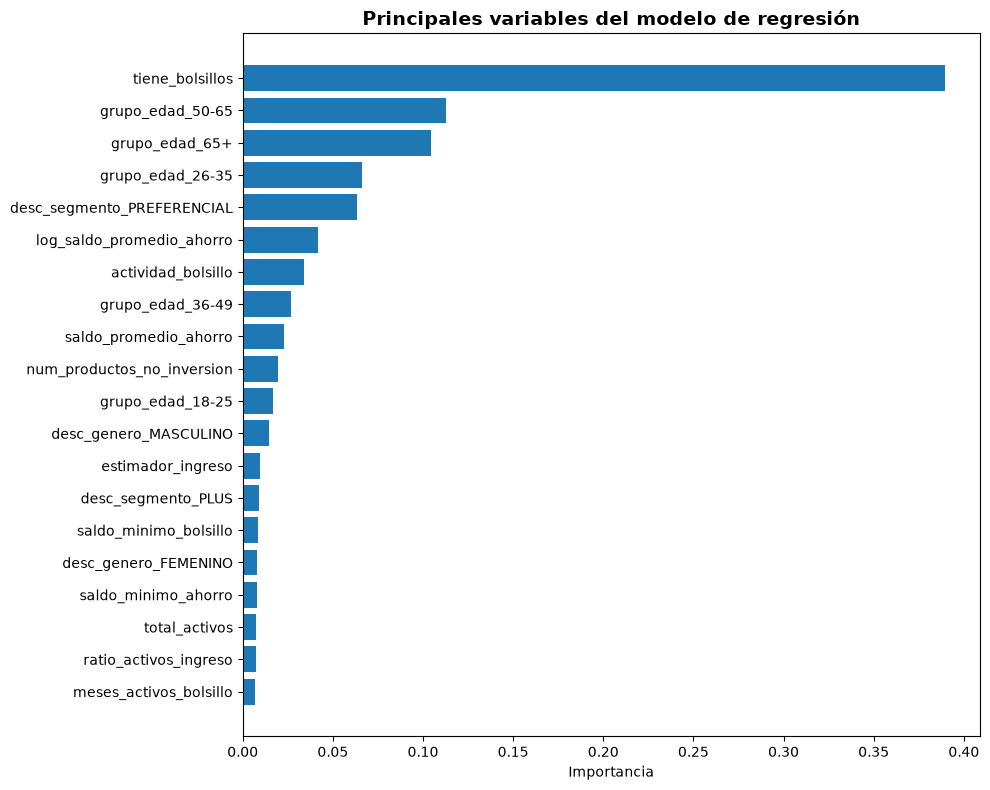

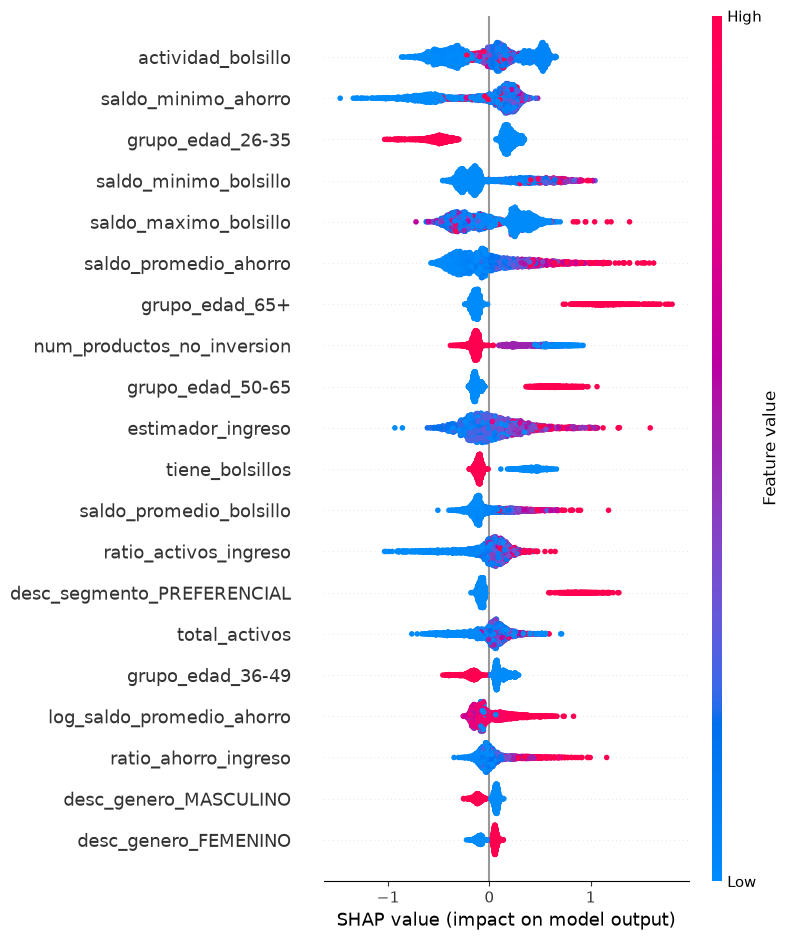


RESUMEN EJECUTIVO DEL MODELO DE REGRESIÓN


,Indicador,Resultado
0,Modelo campeón,XGBoost
1,Variables utilizadas,17
2,Clientes evaluados en Test,44064
3,MAE monetario,"$20,828,294"
4,MedAE monetario,"$2,707,419"
5,RMSE monetario,"$69,935,799"
6,R² en escala log,0.2218


In [91]:
# ============================================================
# 5.7 INTERPRETABILIDAD DE LA REGRESIÓN
# ============================================================
#
# Se generan:
# - importancia global;
# - SHAP cuando el campeón es compatible;
# - análisis del error por nivel real de inversión;
# - tabla ejecutiva de resultados.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Análisis del error por cuartiles reales
# ------------------------------------------------------------

resultados_test_reg["segmento_real"] = pd.qcut(
    resultados_test_reg["monto_real"],
    q=4,
    labels=["Bajo", "Medio", "Alto", "Muy Alto"],
    duplicates="drop"
)

error_por_segmento_reg = (
    resultados_test_reg
    .groupby(
        "segmento_real",
        observed=False
    )
    .agg(
        clientes=("numero_id", "count"),
        monto_real_mediano=("monto_real", "median"),
        monto_predicho_mediano=(
            "monto_predicho_modelo_unico",
            "median"
        ),
        MAE=("error_absoluto", "mean"),
        MedAE=("error_absoluto", "median")
    )
    .reset_index()
)

print("=" * 70)
print("ERROR DEL MODELO ÚNICO POR SEGMENTO REAL")
print("=" * 70)
display(error_por_segmento_reg)


# ------------------------------------------------------------
# 2. Gráfico real vs predicho
# ------------------------------------------------------------

muestra_grafico_reg = resultados_test_reg.sample(
    n=min(5000, len(resultados_test_reg)),
    random_state=42
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    np.log1p(muestra_grafico_reg["monto_real"]),
    np.log1p(
        muestra_grafico_reg[
            "monto_predicho_modelo_unico"
        ]
    ),
    alpha=0.25
)

limite = max(
    np.log1p(muestra_grafico_reg["monto_real"]).max(),
    np.log1p(
        muestra_grafico_reg[
            "monto_predicho_modelo_unico"
        ]
    ).max()
)

ax.plot([0, limite], [0, limite], linestyle="--")

ax.set_title(
    "Monto real vs monto predicho — escala logarítmica",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("log1p(monto real)")
ax.set_ylabel("log1p(monto predicho)")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Importancia global del modelo final
# ------------------------------------------------------------

modelo_interno_reg = (
    modelo_final_reg.named_steps["modelo"]
)

preprocesador_interno_reg = (
    modelo_final_reg.named_steps["preprocesamiento"]
)

if hasattr(modelo_interno_reg, "feature_importances_"):

    nombres_finales_reg = (
        preprocesador_interno_reg
        .get_feature_names_out()
    )

    nombres_finales_limpios_reg = [
        nombre
        .replace("numericas__", "")
        .replace("categoricas__", "")
        for nombre in nombres_finales_reg
    ]

    importancia_final_reg = pd.DataFrame({
        "Variable": nombres_finales_limpios_reg,
        "Importancia": (
            modelo_interno_reg.feature_importances_
        )
    }).sort_values(
        "Importancia",
        ascending=False
    ).reset_index(drop=True)

    importancia_final_reg["Importancia_porcentaje"] = (
        importancia_final_reg["Importancia"] * 100
    )

    print("\nIMPORTANCIA GLOBAL DEL REGRESOR")
    display(importancia_final_reg.head(30))

    top_importancia_reg = (
        importancia_final_reg
        .head(20)
        .sort_values("Importancia")
    )

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(
        top_importancia_reg["Variable"],
        top_importancia_reg["Importancia"]
    )
    ax.set_title(
        "Principales variables del modelo de regresión",
        fontsize=14,
        fontweight="bold"
    )
    ax.set_xlabel("Importancia")
    plt.tight_layout()
    plt.show()

else:
    importancia_final_reg = pd.DataFrame()
    print(
        "El modelo campeón no expone feature_importances_. "
        "La interpretación se realizará mediante coeficientes "
        "o permutation importance."
    )


# ------------------------------------------------------------
# 4. SHAP cuando el modelo lo permite
# ------------------------------------------------------------

try:
    import shap

    muestra_shap_test = (
        X_test_fs[variables_finales_reg]
        .sample(
            n=min(3000, len(X_test_fs)),
            random_state=42
        )
    )

    X_shap_test = (
        preprocesador_interno_reg
        .transform(muestra_shap_test)
    )

    if hasattr(X_shap_test, "toarray"):
        X_shap_test = X_shap_test.toarray()

    explicador_final_reg = shap.TreeExplainer(
        modelo_interno_reg
    )

    valores_shap_final_reg = (
        explicador_final_reg
        .shap_values(X_shap_test)
    )

    if isinstance(valores_shap_final_reg, list):
        valores_shap_final_reg = (
            valores_shap_final_reg[0]
        )

    shap.summary_plot(
        valores_shap_final_reg,
        X_shap_test,
        feature_names=nombres_finales_limpios_reg,
        max_display=20
    )

except Exception as error_shap_final:
    print(
        "SHAP no se generó para el modelo campeón. "
        f"Detalle: {error_shap_final}"
    )

# ------------------------------------------------------------
# 5. Tabla ejecutiva de desempeño
# ------------------------------------------------------------

# Calcular métricas previamente
mae_monetario_reg = mean_absolute_error(
    real_test_pesos_reg,
    pred_test_pesos_reg
)

medae_monetario_reg = median_absolute_error(
    real_test_pesos_reg,
    pred_test_pesos_reg
)

rmse_monetario_reg = np.sqrt(
    mean_squared_error(
        real_test_pesos_reg,
        pred_test_pesos_reg
    )
)

r2_log_reg = r2_score(
    y_test_fs,
    pred_test_log_reg
)


# Construir tabla ejecutiva
resumen_ejecutivo_reg = pd.DataFrame({

    "Indicador": [
        "Modelo campeón",
        "Variables utilizadas",
        "Clientes evaluados en Test",
        "MAE monetario",
        "MedAE monetario",
        "RMSE monetario",
        "R² en escala log"
    ],

    "Resultado": [
        nombre_campeon_reg,
        len(variables_finales_reg),
        len(resultados_test_reg),
        f"${mae_monetario_reg:,.0f}",
        f"${medae_monetario_reg:,.0f}",
        f"${rmse_monetario_reg:,.0f}",
        f"{r2_log_reg:.4f}"
    ]
})


print("\n" + "=" * 70)
print("RESUMEN EJECUTIVO DEL MODELO DE REGRESIÓN")
print("=" * 70)

display(resumen_ejecutivo_reg)

## 5.8 Comparación descriptiva de perfiles de inversión

Antes de construir el segundo clasificador, se comparan descriptivamente los perfiles de inversión identificados. La finalidad es verificar que las diferencias observadas por los modelos también tengan una lectura económica y financiera comprensible.

Las comparaciones se enfocan en:

- capacidad patrimonial;
- ahorro;
- ingreso;
- comportamiento en Bolsillos;
- edad;
- segmento comercial.

PERFILES DE INVERSIÓN


,Clientes
_perfil_2,
Inversión mayor,110160
Inversión menor,110160



COMPARACIÓN FINANCIERA ENTRE PERFILES


,Indicador,Mediana_inversion_menor,Mediana_inversion_mayor,Ratio_mayor_menor
0,Activos,"$45,285,000","$74,138,397",1.64x
1,Patrimonio,"$25,370,500","$43,665,869",1.72x
2,Ingreso estimado,"$5,183,202","$5,618,669",1.08x
3,Ingresos mensuales,"$5,012,762","$5,243,838",1.05x
4,Saldo promedio ahorro,"$1,365,523","$2,624,921",1.92x
5,Saldo promedio Bolsillos,"$72,543","$50,000",0.69x
6,Meses activos Bolsillos,3.0,3.0,1.00x
7,Productos no inversión,2.0,2.0,1.00x


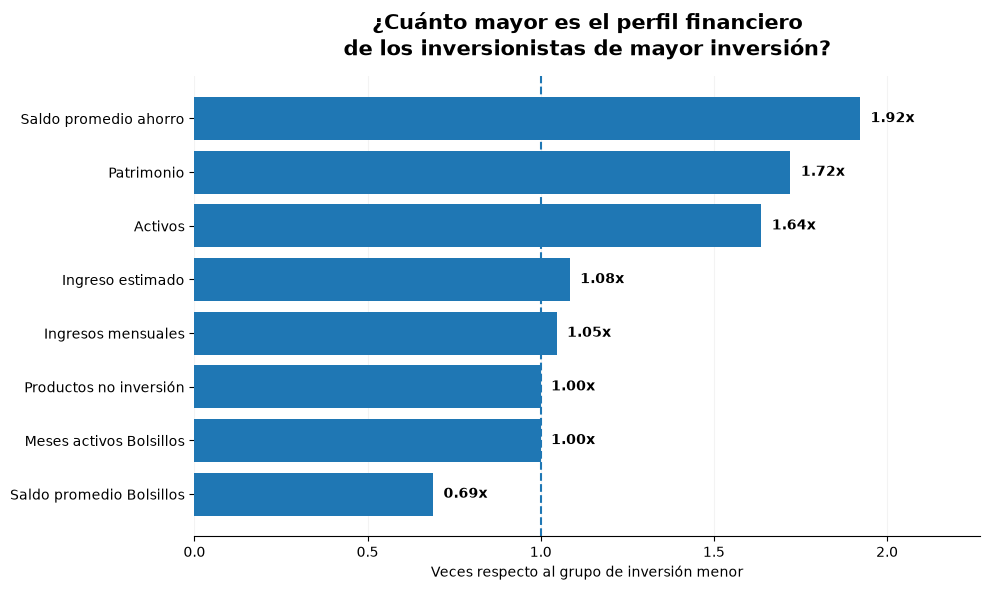

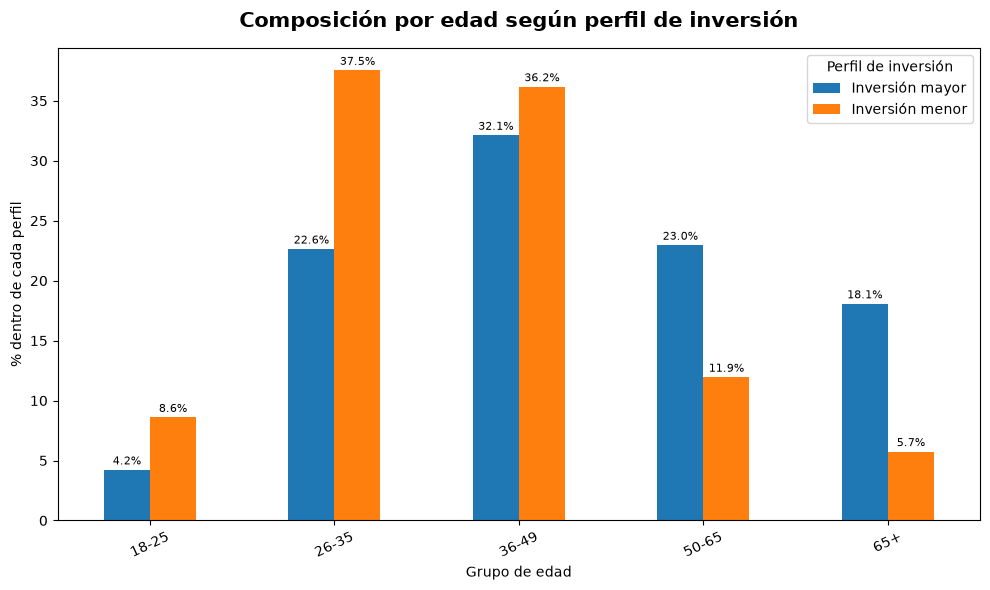

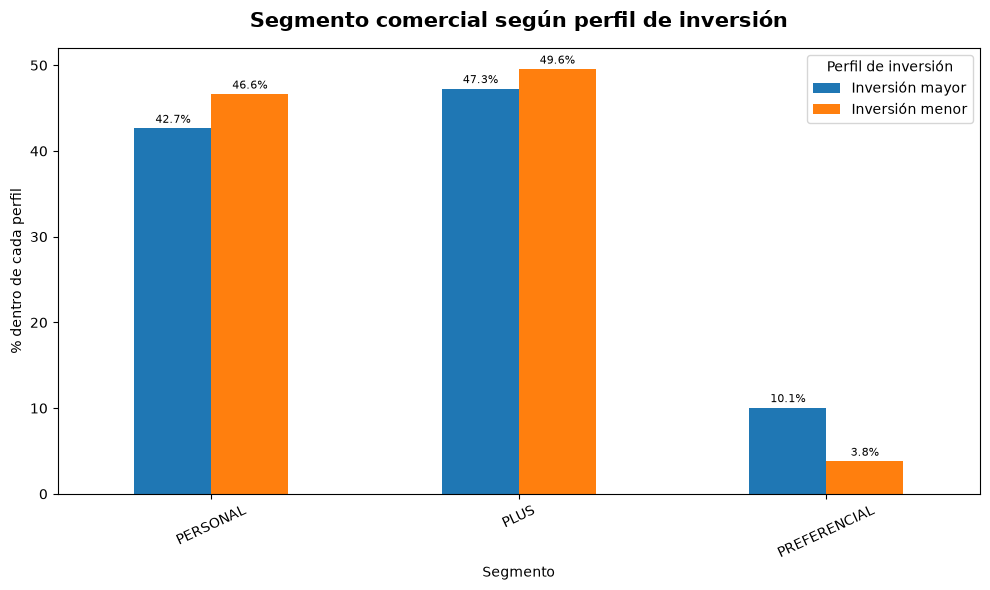

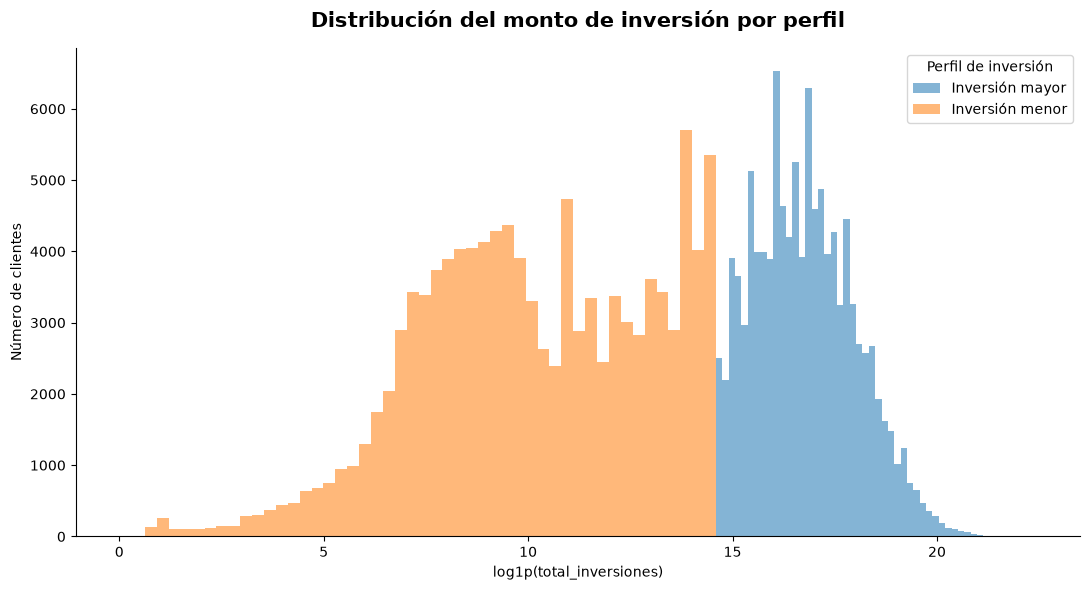


RESUMEN DE PERFILES DE INVERSIÓN


,_perfil_2,Clientes,Monto_minimo,Monto_mediano,Monto_promedio,Monto_maximo
0,Inversión mayor,110160,"$2,181,498","$18,000,000","$45,027,550","$5,250,000,000"
1,Inversión menor,110160,$0,"$22,156","$290,905","$2,181,465"



✅ Comparación descriptiva de perfiles completada.


In [92]:
# ============================================================
# 5.8 COMPARACIÓN DESCRIPTIVA DE PERFILES DE INVERSIÓN
# ============================================================
#
# Objetivo:
# Comparar de manera descriptiva los dos perfiles de inversión:
#
# - Inversión menor
# - Inversión mayor
#
# Se analizan:
#
# 1. Diferencias financieras entre perfiles
# 2. Composición por edad
# 3. Segmento comercial
# 4. Distribución del monto de inversión
#
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 0. SELECCIONAR BASE DE TRABAJO
# ============================================================

if "df_regresion_features" in globals():

    df_perfiles = (
        df_regresion_features
        .copy()
    )

else:

    df_perfiles = (
        df_regresion
        .copy()
    )


# ============================================================
# 0.1 CONSTRUIR PERFIL DE DOS GRUPOS
# ============================================================

if "segmento_inversion" in df_perfiles.columns:

    serie_segmento = (
        df_perfiles[
            "segmento_inversion"
        ]
        .astype(str)
    )


    mapa_2grupos = {

        "Bajo":
            "Inversión menor",

        "Medio":
            "Inversión menor",

        "Alto":
            "Inversión mayor",

        "Muy Alto":
            "Inversión mayor",

        "Inversión menor":
            "Inversión menor",

        "Inversión mayor":
            "Inversión mayor"

    }


    df_perfiles[
        "_perfil_2"
    ] = (
        serie_segmento
        .map(
            mapa_2grupos
        )
    )


elif "corte_log_2grupos" in globals():

    df_perfiles[
        "_perfil_2"
    ] = np.where(

        np.log1p(
            df_perfiles[
                "total_inversiones"
            ]
        )
        < corte_log_2grupos,

        "Inversión menor",

        "Inversión mayor"

    )


else:

    # Fallback únicamente si no existe
    # ninguna definición previa del perfil.
    corte_mediana = (
        df_perfiles[
            "total_inversiones"
        ]
        .median()
    )


    df_perfiles[
        "_perfil_2"
    ] = np.where(

        df_perfiles[
            "total_inversiones"
        ]
        < corte_mediana,

        "Inversión menor",

        "Inversión mayor"

    )


# Conservar únicamente registros correctamente clasificados
df_perfiles = (

    df_perfiles[
        df_perfiles[
            "_perfil_2"
        ]
        .notna()
    ]

    .copy()

)


print("=" * 70)
print("PERFILES DE INVERSIÓN")
print("=" * 70)


display(

    df_perfiles[
        "_perfil_2"
    ]

    .value_counts()

    .rename(
        "Clientes"
    )

    .to_frame()

)


# ============================================================
# 1. DIFERENCIAS FINANCIERAS ENTRE PERFILES
# ============================================================
#
# En lugar de normalizar las medianas entre 0 y 1,
# se calcula cuántas veces mayor es la mediana del grupo
# de inversión mayor respecto al grupo de inversión menor.
#
# Interpretación:
#
# Ratio > 1:
#     Mayor valor en inversionistas de inversión mayor.
#
# Ratio = 1:
#     Valor similar entre ambos grupos.
#
# Ratio < 1:
#     Mayor valor en inversionistas de inversión menor.
# ============================================================


variables_comparacion = [

    "total_activos",

    "total_patrimonio",

    "estimador_ingreso",

    "ingresos_mensuales",

    "saldo_promedio_ahorro",

    "saldo_promedio_bolsillo",

    "meses_activos_bolsillo",

    "num_productos_no_inversion"

]


variables_comparacion = [

    variable

    for variable in variables_comparacion

    if variable in df_perfiles.columns

]


nombres_variables = {

    "total_activos":
        "Activos",

    "total_patrimonio":
        "Patrimonio",

    "estimador_ingreso":
        "Ingreso estimado",

    "ingresos_mensuales":
        "Ingresos mensuales",

    "saldo_promedio_ahorro":
        "Saldo promedio ahorro",

    "saldo_promedio_bolsillo":
        "Saldo promedio Bolsillos",

    "meses_activos_bolsillo":
        "Meses activos Bolsillos",

    "num_productos_no_inversion":
        "Productos no inversión"

}


# ------------------------------------------------------------
# Calcular medianas por perfil
# ------------------------------------------------------------

medianas_perfiles = (

    df_perfiles

    .groupby(
        "_perfil_2"
    )[variables_comparacion]

    .median(
        numeric_only=True
    )

    .T

)


grupo_menor = "Inversión menor"

grupo_mayor = "Inversión mayor"


if (

    grupo_menor not in medianas_perfiles.columns

    or

    grupo_mayor not in medianas_perfiles.columns

):

    raise ValueError(
        "No se encontraron los grupos "
        "'Inversión menor' e 'Inversión mayor'."
    )


# ------------------------------------------------------------
# Construir tabla comparativa
# ------------------------------------------------------------

comparacion_financiera = pd.DataFrame({

    "Variable":
        medianas_perfiles.index,

    "Mediana_inversion_menor":
        medianas_perfiles[
            grupo_menor
        ].values,

    "Mediana_inversion_mayor":
        medianas_perfiles[
            grupo_mayor
        ].values

})


comparacion_financiera[
    "Ratio_mayor_menor"
] = np.where(

    comparacion_financiera[
        "Mediana_inversion_menor"
    ] > 0,

    comparacion_financiera[
        "Mediana_inversion_mayor"
    ]
    /
    comparacion_financiera[
        "Mediana_inversion_menor"
    ],

    np.nan

)


comparacion_financiera[
    "Indicador"
] = (

    comparacion_financiera[
        "Variable"
    ]

    .map(
        nombres_variables
    )

    .fillna(
        comparacion_financiera[
            "Variable"
        ]
    )

)


# ------------------------------------------------------------
# Tabla de presentación
# ------------------------------------------------------------

comparacion_presentacion = (

    comparacion_financiera[
        [
            "Indicador",
            "Mediana_inversion_menor",
            "Mediana_inversion_mayor",
            "Ratio_mayor_menor"
        ]
    ]

    .copy()

)


variables_monetarias = [

    "Activos",

    "Patrimonio",

    "Ingreso estimado",

    "Ingresos mensuales",

    "Saldo promedio ahorro",

    "Saldo promedio Bolsillos"

]


comparacion_presentacion[
    "Mediana_inversion_menor"
] = comparacion_presentacion.apply(

    lambda fila:

        (
            f"${fila['Mediana_inversion_menor']:,.0f}"
            if fila["Indicador"] in variables_monetarias
            else f"{fila['Mediana_inversion_menor']:,.1f}"
        ),

    axis=1

)


comparacion_presentacion[
    "Mediana_inversion_mayor"
] = comparacion_presentacion.apply(

    lambda fila:

        (
            f"${fila['Mediana_inversion_mayor']:,.0f}"
            if fila["Indicador"] in variables_monetarias
            else f"{fila['Mediana_inversion_mayor']:,.1f}"
        ),

    axis=1

)


comparacion_presentacion[
    "Ratio_mayor_menor"
] = (

    comparacion_financiera[
        "Ratio_mayor_menor"
    ]

    .map(
        lambda valor:
            f"{valor:.2f}x"
            if pd.notna(valor)
            else "-"
    )

)


print("\n" + "=" * 70)
print("COMPARACIÓN FINANCIERA ENTRE PERFILES")
print("=" * 70)


display(
    comparacion_presentacion
)


# ------------------------------------------------------------
# Gráfico de ratios
# ------------------------------------------------------------

datos_ratio = (

    comparacion_financiera

    .dropna(
        subset=[
            "Ratio_mayor_menor"
        ]
    )

    .sort_values(
        "Ratio_mayor_menor"
    )

    .copy()

)


if len(datos_ratio) > 0:

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )


    barras = ax.barh(

        datos_ratio[
            "Indicador"
        ],

        datos_ratio[
            "Ratio_mayor_menor"
        ]

    )


    # Línea de referencia:
    # mismo valor en ambos perfiles
    ax.axvline(
        x=1,
        linestyle="--",
        linewidth=1.5
    )


    ax.set_title(

        "¿Cuánto mayor es el perfil financiero\n"
        "de los inversionistas de mayor inversión?",

        fontsize=15,

        fontweight="bold",

        pad=15

    )


    ax.set_xlabel(
        "Veces respecto al grupo de inversión menor"
    )

    ax.set_ylabel("")


    ax.spines[
        ["top", "right", "left"]
    ].set_visible(False)


    ax.grid(
        axis="x",
        alpha=0.15
    )


    ax.set_axisbelow(True)


    for barra, ratio in zip(

        barras,

        datos_ratio[
            "Ratio_mayor_menor"
        ]

    ):

        ax.text(

            barra.get_width() + 0.03,

            barra.get_y()
            + barra.get_height() / 2,

            f"{ratio:.2f}x",

            va="center",

            fontsize=10,

            fontweight="bold"

        )


    max_ratio = (

        datos_ratio[
            "Ratio_mayor_menor"
        ]

        .max()

    )


    ax.set_xlim(

        0,

        max(
            1.2,
            max_ratio * 1.18
        )

    )


    plt.tight_layout()

    plt.show()


# ============================================================
# 2. COMPOSICIÓN POR EDAD
# ============================================================

if "grupo_edad" in df_perfiles.columns:

    tabla_edad_perfil = pd.crosstab(

        df_perfiles[
            "grupo_edad"
        ]
        .fillna(
            "SIN INFORMACION"
        ),

        df_perfiles[
            "_perfil_2"
        ],

        normalize="columns"

    ).mul(100)


    # Orden lógico de edades
    orden_edades = [

        "18-25",

        "26-35",

        "36-49",

        "50-65",

        "65+"

    ]


    orden_disponible = [

        edad

        for edad in orden_edades

        if edad in tabla_edad_perfil.index

    ]


    tabla_edad_perfil = (
        tabla_edad_perfil
        .reindex(
            orden_disponible
        )
    )


    ax = tabla_edad_perfil.plot(

        kind="bar",

        figsize=(10, 6)

    )


    ax.set_title(

        "Composición por edad según perfil de inversión",

        fontsize=15,

        fontweight="bold",

        pad=15

    )


    ax.set_ylabel(
        "% dentro de cada perfil"
    )

    ax.set_xlabel(
        "Grupo de edad"
    )


    plt.xticks(
        rotation=25
    )


    # Etiquetas porcentuales
    for contenedor in ax.containers:

        ax.bar_label(
            contenedor,
            fmt="%.1f%%",
            padding=2,
            fontsize=8
        )


    ax.legend(
        title="Perfil de inversión"
    )


    plt.tight_layout()

    plt.show()


# ============================================================
# 3. SEGMENTO COMERCIAL
# ============================================================

if "desc_segmento" in df_perfiles.columns:

    top_segmentos = (

        df_perfiles[
            "desc_segmento"
        ]

        .fillna(
            "SIN INFORMACION"
        )

        .value_counts()

        .head(8)

        .index

    )


    tmp_segmentos = (

        df_perfiles[
            df_perfiles[
                "desc_segmento"
            ]
            .fillna(
                "SIN INFORMACION"
            )
            .isin(
                top_segmentos
            )
        ]

        .copy()

    )


    tmp_segmentos[
        "desc_segmento"
    ] = (

        tmp_segmentos[
            "desc_segmento"
        ]

        .fillna(
            "SIN INFORMACION"
        )

    )


    tabla_segmento_perfil = pd.crosstab(

        tmp_segmentos[
            "desc_segmento"
        ],

        tmp_segmentos[
            "_perfil_2"
        ],

        normalize="columns"

    ).mul(100)


    ax = tabla_segmento_perfil.plot(

        kind="bar",

        figsize=(10, 6)

    )


    ax.set_title(

        "Segmento comercial según perfil de inversión",

        fontsize=15,

        fontweight="bold",

        pad=15

    )


    ax.set_ylabel(
        "% dentro de cada perfil"
    )

    ax.set_xlabel(
        "Segmento"
    )


    plt.xticks(
        rotation=25
    )


    for contenedor in ax.containers:

        ax.bar_label(
            contenedor,
            fmt="%.1f%%",
            padding=2,
            fontsize=8
        )


    ax.legend(
        title="Perfil de inversión"
    )


    plt.tight_layout()

    plt.show()


# ============================================================
# 4. DISTRIBUCIÓN DEL MONTO DE INVERSIÓN
# ============================================================

if "total_inversiones" in df_perfiles.columns:

    fig, ax = plt.subplots(
        figsize=(11, 6)
    )


    for perfil, serie in (

        df_perfiles

        .groupby(
            "_perfil_2"
        )[
            "total_inversiones"
        ]

    ):

        valores = (

            pd.to_numeric(
                serie,
                errors="coerce"
            )

            .dropna()

        )


        valores = (
            valores[
                valores >= 0
            ]
        )


        ax.hist(

            np.log1p(
                valores
            ),

            bins=50,

            alpha=0.55,

            label=perfil

        )


    ax.set_title(

        "Distribución del monto de inversión por perfil",

        fontsize=15,

        fontweight="bold",

        pad=15

    )


    ax.set_xlabel(
        "log1p(total_inversiones)"
    )


    ax.set_ylabel(
        "Número de clientes"
    )


    ax.legend(
        title="Perfil de inversión"
    )


    ax.spines[
        ["top", "right"]
    ].set_visible(False)


    plt.tight_layout()

    plt.show()


# ============================================================
# 5. RESUMEN FINAL
# ============================================================

print("\n" + "=" * 70)
print("RESUMEN DE PERFILES DE INVERSIÓN")
print("=" * 70)


resumen_perfiles = (

    df_perfiles

    .groupby(
        "_perfil_2"
    )[
        "total_inversiones"
    ]

    .agg(

        Clientes="count",

        Monto_minimo="min",

        Monto_mediano="median",

        Monto_promedio="mean",

        Monto_maximo="max"

    )

    .reset_index()

)


resumen_perfiles_presentacion = (
    resumen_perfiles
    .copy()
)


for columna in [

    "Monto_minimo",

    "Monto_mediano",

    "Monto_promedio",

    "Monto_maximo"

]:

    resumen_perfiles_presentacion[
        columna
    ] = (

        resumen_perfiles_presentacion[
            columna
        ]

        .map(
            lambda valor:
                f"${valor:,.0f}"
        )

    )


display(
    resumen_perfiles_presentacion
)


print(
    "\n✅ Comparación descriptiva de perfiles completada."
)

# 6. Modelado especializado del perfil y monto de inversión

Los resultados del modelo único motivan evaluar si la población inversionista puede beneficiarse de modelos especializados.

La arquitectura de esta sección sigue el flujo:

1. Definir perfiles de inversión sin utilizar información de Validation o Test para aprender los cortes.
2. Entrenar un clasificador que estime el perfil de un inversionista.
3. Entrenar regresores especializados por perfil.
4. Integrar clasificación y regresión.
5. Comparar el sistema especializado contra el modelo único.

> **Nota de versión:** este archivo contiene el experimento jerárquico original de cuatro segmentos. Los experimentos posteriores de dos grupos, hard gating, soft gating y escenario Oracle no aparecen en esta copia del notebook y deberán integrarse desde la versión más reciente antes de considerar este archivo como definitivo.

## 6.1 Definición de perfiles de inversión sin fuga

Los puntos de corte se aprenden exclusivamente con Train y se aplican sin cambios a Validation y Test. En esta versión del notebook se utiliza la segmentación original en cuatro niveles: Bajo, Medio, Alto y Muy Alto.

In [93]:
# ============================================================
# 6.1 PUNTOS DE CORTE PARA LA ARQUITECTURA JERÁRQUICA
# ============================================================

# Cuartiles calculados exclusivamente con Train, en pesos.
y_train_pesos = np.expm1(y_train_reg)

cortes_segmento = y_train_pesos.quantile([0.25, 0.50, 0.75]).to_dict()

P25 = cortes_segmento[0.25]
P50 = cortes_segmento[0.50]
P75 = cortes_segmento[0.75]


def asignar_segmento_monto(monto):
    if monto <= P25:
        return "Bajo"
    if monto <= P50:
        return "Medio"
    if monto <= P75:
        return "Alto"
    return "Muy Alto"

segmento_train = y_train_pesos.map(asignar_segmento_monto)
segmento_validation = np.expm1(y_validation_reg).map(asignar_segmento_monto)
segmento_test = np.expm1(y_test_reg).map(asignar_segmento_monto)

print("Cortes aprendidos exclusivamente con Train:")
print({"P25": P25, "P50": P50, "P75": P75})
display(segmento_train.value_counts().sort_index().to_frame("Train"))


Cortes aprendidos exclusivamente con Train:
{'P25': 22231.134999999987, 'P50': 2153593.6800000016, 'P75': 18009368.424999986}


,Train
total_inversiones,
Alto,33048
Bajo,33048
Medio,33048
Muy Alto,33048


## 6.2 Clasificación del perfil de inversionista

Se construye un segundo problema de clasificación. A diferencia del capítulo 4, aquí la población ya está compuesta por inversionistas y el objetivo es determinar a qué nivel de inversión pertenece cada cliente.

In [94]:
# ============================================================
# 6.2 CLASIFICADOR DEL SEGMENTO DE INVERSIÓN
# ============================================================
#
# El clasificador se entrena con las mismas variables finales
# del modelo único. Predice Bajo, Medio, Alto o Muy Alto.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from xgboost import XGBClassifier


orden_segmentos_jer = [
    "Bajo",
    "Medio",
    "Alto",
    "Muy Alto"
]

mapa_segmentos_jer = {
    segmento: indice
    for indice, segmento in enumerate(
        orden_segmentos_jer
    )
}

y_segmento_train = segmento_train.map(
    mapa_segmentos_jer
).astype(int)

y_segmento_validation = segmento_validation.map(
    mapa_segmentos_jer
).astype(int)

y_segmento_test = segmento_test.map(
    mapa_segmentos_jer
).astype(int)


preprocesador_clasificador_jer = (
    construir_preprocesador_reg(
        X_train_fs,
        variables_finales_reg
    )
)

clasificador_segmento_jer = Pipeline(
    steps=[
        (
            "preprocesamiento",
            preprocesador_clasificador_jer
        ),
        (
            "modelo",
            XGBClassifier(
                n_estimators=400,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.80,
                colsample_bytree=0.80,
                min_child_weight=10,
                reg_alpha=0.10,
                reg_lambda=1.00,
                objective="multi:softprob",
                num_class=4,
                eval_metric="mlogloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

clasificador_segmento_jer.fit(
    X_train_fs[variables_finales_reg],
    y_segmento_train
)

pred_segmento_validation_num = (
    clasificador_segmento_jer.predict(
        X_validation_fs[variables_finales_reg]
    )
)

pred_segmento_validation = pd.Series(
    [
        orden_segmentos_jer[int(valor)]
        for valor in pred_segmento_validation_num
    ],
    index=X_validation_fs.index,
    name="segmento_predicho"
)

metricas_clasificador_jer = pd.DataFrame({
    "Metrica": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro F1",
        "Error ordinal medio"
    ],
    "Valor": [
        accuracy_score(
            y_segmento_validation,
            pred_segmento_validation_num
        ),
        balanced_accuracy_score(
            y_segmento_validation,
            pred_segmento_validation_num
        ),
        f1_score(
            y_segmento_validation,
            pred_segmento_validation_num,
            average="macro"
        ),
        np.abs(
            y_segmento_validation.to_numpy()
            - pred_segmento_validation_num
        ).mean()
    ]
})

print("=" * 70)
print("CLASIFICADOR DE SEGMENTOS — VALIDATION")
print("=" * 70)
display(metricas_clasificador_jer)

print(
    classification_report(
        y_segmento_validation,
        pred_segmento_validation_num,
        target_names=orden_segmentos_jer,
        digits=4
    )
)

matriz_confusion_jer = confusion_matrix(
    y_segmento_validation,
    pred_segmento_validation_num
)

display(
    pd.DataFrame(
        matriz_confusion_jer,
        index=[
            f"Real_{s}"
            for s in orden_segmentos_jer
        ],
        columns=[
            f"Pred_{s}"
            for s in orden_segmentos_jer
        ]
    )
)

CLASIFICADOR DE SEGMENTOS — VALIDATION


,Metrica,Valor
0,Accuracy,0.428831
1,Balanced Accuracy,0.428182
2,Macro F1,0.408258
3,Error ordinal medio,0.902460


              precision    recall  f1-score   support

        Bajo     0.4120    0.5986    0.4881     11133
       Medio     0.3742    0.1838    0.2465     10820
        Alto     0.4061    0.3212    0.3587     11202
    Muy Alto     0.4845    0.6091    0.5397     10909

    accuracy                         0.4288     44064
   macro avg     0.4192    0.4282    0.4083     44064
weighted avg     0.4192    0.4288    0.4087     44064



,Pred_Bajo,Pred_Medio,Pred_Alto,Pred_Muy Alto
Real_Bajo,6664,1403,1467,1599
Real_Medio,4439,1989,1975,2417
Real_Alto,3240,1310,3598,3054
Real_Muy Alto,1831,614,1819,6645


## 6.3 Regresores especializados por perfil

Cada regresor se entrena únicamente con clientes del segmento correspondiente. El objetivo es capturar relaciones diferentes entre las variables financieras y el monto invertido.

In [95]:
# ============================================================
# 6.3 REGRESORES ESPECIALIZADOS POR SEGMENTO
# ============================================================
#
# Cada regresor aprende únicamente con los clientes de Train
# pertenecientes al segmento correspondiente.
# ============================================================

from sklearn.base import clone
from xgboost import XGBRegressor


def crear_regresor_especializado():
    preprocesador = construir_preprocesador_reg(
        X_train_fs,
        variables_finales_reg
    )

    return Pipeline(
        steps=[
            ("preprocesamiento", preprocesador),
            (
                "modelo",
                XGBRegressor(
                    n_estimators=400,
                    max_depth=5,
                    learning_rate=0.05,
                    subsample=0.85,
                    colsample_bytree=0.85,
                    min_child_weight=8,
                    reg_alpha=0.10,
                    reg_lambda=1.00,
                    objective="reg:squarederror",
                    eval_metric="rmse",
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]
    )


regresores_segmento_jer = {}
resumen_entrenamiento_segmentos = []

for segmento in orden_segmentos_jer:

    mascara_segmento = (
        segmento_train == segmento
    )

    X_train_segmento = (
        X_train_fs.loc[
            mascara_segmento,
            variables_finales_reg
        ]
    )

    y_train_segmento = (
        y_train_fs.loc[mascara_segmento]
    )

    if len(X_train_segmento) < 100:
        raise ValueError(
            f"El segmento {segmento} tiene muy pocos "
            "registros para entrenar un regresor."
        )

    regresor = crear_regresor_especializado()

    regresor.fit(
        X_train_segmento,
        y_train_segmento
    )

    regresores_segmento_jer[segmento] = regresor

    resumen_entrenamiento_segmentos.append({
        "Segmento": segmento,
        "Clientes_train": len(X_train_segmento),
        "Target_log_mediano": (
            y_train_segmento.median()
        ),
        "Monto_mediano_pesos": (
            np.expm1(y_train_segmento).median()
        )
    })


resumen_entrenamiento_segmentos = pd.DataFrame(
    resumen_entrenamiento_segmentos
)

display(resumen_entrenamiento_segmentos)

,Segmento,Clientes_train,Target_log_mediano,Monto_mediano_pesos
0,Bajo,33048,8.057328,3.155845e+03
1,Medio,33048,12.599544,2.964222e+05
2,Alto,33048,15.805059,7.312232e+06
3,Muy Alto,33048,17.635485,4.560306e+07


## 6.4 Integración del clasificador y los regresores

Para cada cliente se predice primero el perfil de inversión y posteriormente se utiliza el regresor especializado correspondiente para generar la estimación del monto.

In [96]:
# ============================================================
# 6.4 ENRUTAMIENTO Y PREDICCIÓN INTEGRAL
# ============================================================
#
# Validation:
# 1. El clasificador predice el segmento.
# 2. Cada fila es enviada al regresor especializado.
# 3. Las predicciones se integran en un solo vector.
# ============================================================

pred_jerarquica_validation_log = pd.Series(
    index=X_validation_fs.index,
    dtype=float,
    name="prediccion_jerarquica_log"
)

for segmento in orden_segmentos_jer:

    indices_segmento = (
        pred_segmento_validation[
            pred_segmento_validation == segmento
        ].index
    )

    if len(indices_segmento) == 0:
        continue

    modelo_segmento = (
        regresores_segmento_jer[segmento]
    )

    predicciones_segmento = modelo_segmento.predict(
        X_validation_fs.loc[
            indices_segmento,
            variables_finales_reg
        ]
    )

    pred_jerarquica_validation_log.loc[
        indices_segmento
    ] = predicciones_segmento


if pred_jerarquica_validation_log.isna().any():
    raise RuntimeError(
        "Existen clientes sin predicción jerárquica."
    )


pred_jerarquica_validation_pesos = np.expm1(
    np.clip(
        pred_jerarquica_validation_log.to_numpy(),
        0,
        None
    )
)

real_validation_pesos_jer = np.expm1(
    y_validation_fs.to_numpy()
)

resultados_validation_jer = pd.DataFrame({
    "numero_id": ids_validation_reg.values,
    "segmento_real": segmento_validation.values,
    "segmento_predicho": (
        pred_segmento_validation.values
    ),
    "monto_real": real_validation_pesos_jer,
    "monto_predicho_jerarquico": (
        pred_jerarquica_validation_pesos
    )
})

resultados_validation_jer["error_absoluto"] = np.abs(
    resultados_validation_jer["monto_real"]
    - resultados_validation_jer[
        "monto_predicho_jerarquico"
    ]
)

metricas_validation_jer = pd.DataFrame({
    "Metrica": [
        "MAE_log",
        "RMSE_log",
        "R2_log",
        "MAE_pesos",
        "MedAE_pesos",
        "RMSE_pesos",
        "R2_pesos"
    ],
    "Valor": [
        mean_absolute_error(
            y_validation_fs,
            pred_jerarquica_validation_log
        ),
        np.sqrt(
            mean_squared_error(
                y_validation_fs,
                pred_jerarquica_validation_log
            )
        ),
        r2_score(
            y_validation_fs,
            pred_jerarquica_validation_log
        ),
        mean_absolute_error(
            real_validation_pesos_jer,
            pred_jerarquica_validation_pesos
        ),
        median_absolute_error(
            real_validation_pesos_jer,
            pred_jerarquica_validation_pesos
        ),
        np.sqrt(
            mean_squared_error(
                real_validation_pesos_jer,
                pred_jerarquica_validation_pesos
            )
        ),
        r2_score(
            real_validation_pesos_jer,
            pred_jerarquica_validation_pesos
        )
    ]
})

display(metricas_validation_jer)

,Metrica,Valor
0,MAE_log,3.439727e+00
1,RMSE_log,4.679010e+00
2,R2_log,-3.688254e-01
3,MAE_pesos,2.453471e+07
4,MedAE_pesos,6.356901e+06
5,RMSE_pesos,6.291652e+07
6,R2_pesos,1.588589e-01


## 6.5 Comparación contra el modelo único

La arquitectura especializada se compara con el modelo único utilizando las mismas particiones y métricas. La mejora predictiva debe evaluarse junto con la complejidad operativa y el riesgo de errores de enrutamiento.

In [97]:
# ============================================================
# 6.5 COMPARACIÓN: MODELO ÚNICO VS JERÁRQUICO
# ============================================================
#
# La decisión se toma primero en Validation.
# El sistema jerárquico solo pasa a Test si ofrece una mejora
# material que justifique su mayor complejidad.
# ============================================================

# Predicción del modelo único campeón en Validation.
pred_unico_validation_log = (
    modelo_campeon_validation_reg.predict(
        X_validation_fs[variables_finales_reg]
    )
)

pred_unico_validation_pesos = np.expm1(
    np.clip(
        pred_unico_validation_log,
        0,
        None
    )
)

comparacion_validation = pd.DataFrame({
    "Modelo": [
        "Regresión única",
        "Arquitectura jerárquica"
    ],
    "MAE_log": [
        mean_absolute_error(
            y_validation_fs,
            pred_unico_validation_log
        ),
        mean_absolute_error(
            y_validation_fs,
            pred_jerarquica_validation_log
        )
    ],
    "RMSE_log": [
        np.sqrt(
            mean_squared_error(
                y_validation_fs,
                pred_unico_validation_log
            )
        ),
        np.sqrt(
            mean_squared_error(
                y_validation_fs,
                pred_jerarquica_validation_log
            )
        )
    ],
    "R2_log": [
        r2_score(
            y_validation_fs,
            pred_unico_validation_log
        ),
        r2_score(
            y_validation_fs,
            pred_jerarquica_validation_log
        )
    ],
    "MAE_pesos": [
        mean_absolute_error(
            real_validation_pesos_jer,
            pred_unico_validation_pesos
        ),
        mean_absolute_error(
            real_validation_pesos_jer,
            pred_jerarquica_validation_pesos
        )
    ],
    "MedAE_pesos": [
        median_absolute_error(
            real_validation_pesos_jer,
            pred_unico_validation_pesos
        ),
        median_absolute_error(
            real_validation_pesos_jer,
            pred_jerarquica_validation_pesos
        )
    ],
    "RMSE_pesos": [
        np.sqrt(
            mean_squared_error(
                real_validation_pesos_jer,
                pred_unico_validation_pesos
            )
        ),
        np.sqrt(
            mean_squared_error(
                real_validation_pesos_jer,
                pred_jerarquica_validation_pesos
            )
        )
    ],
    "R2_pesos": [
        r2_score(
            real_validation_pesos_jer,
            pred_unico_validation_pesos
        ),
        r2_score(
            real_validation_pesos_jer,
            pred_jerarquica_validation_pesos
        )
    ]
})

display(comparacion_validation)


# ------------------------------------------------------------
# Criterio de aceptación
# ------------------------------------------------------------
#
# Se exige al menos 2% de mejora relativa en MAE_log o una
# reducción material del RMSE monetario.
# ------------------------------------------------------------

mae_unico = comparacion_validation.loc[
    comparacion_validation["Modelo"]
    == "Regresión única",
    "MAE_log"
].iloc[0]

mae_jer = comparacion_validation.loc[
    comparacion_validation["Modelo"]
    == "Arquitectura jerárquica",
    "MAE_log"
].iloc[0]

mejora_relativa_mae = (
    (mae_unico - mae_jer) / mae_unico
)

arquitectura_jerarquica_aprobada = (
    mejora_relativa_mae >= 0.02
)

print(
    f"Mejora relativa del MAE log: "
    f"{mejora_relativa_mae * 100:.2f}%"
)

if arquitectura_jerarquica_aprobada:
    print(
        "✅ La arquitectura jerárquica supera el umbral "
        "mínimo definido y puede avanzar a evaluación final."
    )
else:
    print(
        "⚠️ La mejora no compensa claramente la complejidad. "
        "El modelo único permanece como solución recomendada."
    )


# ------------------------------------------------------------
# Evaluación final jerárquica en Test, solo si fue aprobada
# ------------------------------------------------------------

if arquitectura_jerarquica_aprobada:

    # Clasificador final con Train + Validation.
    X_trainval_jer = pd.concat(
        [
            X_train_fs[variables_finales_reg],
            X_validation_fs[variables_finales_reg]
        ],
        axis=0
    )

    y_segmento_trainval = pd.concat(
        [
            y_segmento_train,
            y_segmento_validation
        ],
        axis=0
    )

    clasificador_final_jer = clone(
        clasificador_segmento_jer
    )

    clasificador_final_jer.fit(
        X_trainval_jer,
        y_segmento_trainval
    )

    pred_segmento_test_num = (
        clasificador_final_jer.predict(
            X_test_fs[variables_finales_reg]
        )
    )

    pred_segmento_test = pd.Series(
        [
            orden_segmentos_jer[int(valor)]
            for valor in pred_segmento_test_num
        ],
        index=X_test_fs.index
    )

    # Reentrenar cada regresor con Train + Validation,
    # usando los segmentos reales definidos con los cortes
    # congelados de Train.
    segmento_trainval = pd.concat(
        [segmento_train, segmento_validation],
        axis=0
    )

    y_trainval_jer = pd.concat(
        [y_train_fs, y_validation_fs],
        axis=0
    )

    regresores_finales_jer = {}

    for segmento in orden_segmentos_jer:

        mascara = (
            segmento_trainval == segmento
        )

        regresor_final = crear_regresor_especializado()

        regresor_final.fit(
            X_trainval_jer.loc[mascara],
            y_trainval_jer.loc[mascara]
        )

        regresores_finales_jer[segmento] = (
            regresor_final
        )

    pred_test_jer_log = pd.Series(
        index=X_test_fs.index,
        dtype=float
    )

    for segmento in orden_segmentos_jer:

        indices = pred_segmento_test[
            pred_segmento_test == segmento
        ].index

        if len(indices) == 0:
            continue

        pred_test_jer_log.loc[indices] = (
            regresores_finales_jer[segmento]
            .predict(
                X_test_fs.loc[
                    indices,
                    variables_finales_reg
                ]
            )
        )

    pred_test_jer_pesos = np.expm1(
        np.clip(
            pred_test_jer_log.to_numpy(),
            0,
            None
        )
    )

    comparacion_test_final = pd.DataFrame({
        "Modelo": [
            "Regresión única",
            "Arquitectura jerárquica"
        ],
        "MAE_pesos": [
            mean_absolute_error(
                real_test_pesos_reg,
                pred_test_pesos_reg
            ),
            mean_absolute_error(
                real_test_pesos_reg,
                pred_test_jer_pesos
            )
        ],
        "MedAE_pesos": [
            median_absolute_error(
                real_test_pesos_reg,
                pred_test_pesos_reg
            ),
            median_absolute_error(
                real_test_pesos_reg,
                pred_test_jer_pesos
            )
        ],
        "RMSE_pesos": [
            np.sqrt(
                mean_squared_error(
                    real_test_pesos_reg,
                    pred_test_pesos_reg
                )
            ),
            np.sqrt(
                mean_squared_error(
                    real_test_pesos_reg,
                    pred_test_jer_pesos
                )
            )
        ],
        "R2_pesos": [
            r2_score(
                real_test_pesos_reg,
                pred_test_pesos_reg
            ),
            r2_score(
                real_test_pesos_reg,
                pred_test_jer_pesos
            )
        ]
    })

    print("\nCOMPARACIÓN FINAL EN TEST")
    display(comparacion_test_final)

,Modelo,MAE_log,RMSE_log,R2_log,MAE_pesos,MedAE_pesos,RMSE_pesos,R2_pesos
0,Regresión única,2.927994,3.541253,0.215931,2.067207e+07,2.649654e+06,6.782262e+07,0.022563
1,Arquitectura jerárquica,3.439727,4.679010,-0.368825,2.453471e+07,6.356901e+06,6.291652e+07,0.158859


Mejora relativa del MAE log: -17.48%
⚠️ La mejora no compensa claramente la complejidad. El modelo único permanece como solución recomendada.


# 7.X Preparación de datos para Power BI

En esta sección se consolidan las principales tablas generadas durante el análisis para construir un tablero ejecutivo que permita recorrer la historia completa del proyecto:

1. Caracterización general de clientes.
2. Inversionistas vs no inversionistas.
3. Resultados del modelo de afinidad hacia inversiones.
4. Caracterización de perfiles de inversión.
5. Resultados de la estimación del monto.
6. Comparación de modelos.
7. Interpretabilidad mediante SHAP.

Las tablas de evaluación predictiva conservan únicamente resultados obtenidos sobre conjuntos independientes de Test cuando corresponde.

In [98]:
# ============================================================
# 7.X PREPARACIÓN DEFINITIVA DE DATOS PARA POWER BI
# ============================================================
#
# Objetivo:
# Construir y exportar todas las tablas necesarias para contar
# la historia completa del proyecto en Power BI.
#
# Estructura:
#
# 01. Cliente 360 + perfil de inversión
# 02. Clasificador inversionista / no inversionista - Test
# 03. Métricas del clasificador
# 04. Perfiles de inversión
# 05. Regresión - Test
# 06. Error de regresión por nivel
# 07. Comparación de modelos de regresión
# 08. Comparación de arquitecturas
# 09. SHAP clasificador
# 10. Importancia / SHAP regresión
# 11. Resumen de perfiles
# 12. Comparación financiera de perfiles
# 00. Catálogo de tablas
#
# ============================================================

import os
import numpy as np
import pandas as pd


# ============================================================
# 0. CONFIGURACIÓN
# ============================================================

CARPETA_POWERBI = "08_POWER_BI"

os.makedirs(
    CARPETA_POWERBI,
    exist_ok=True
)


tablas_powerbi = {}


# ============================================================
# FUNCIÓN GENERAL DE EXPORTACIÓN
# ============================================================

def registrar_tabla(
    nombre,
    dataframe,
    archivo
):

    if dataframe is None:

        print(
            f"⚠️ {nombre:<40} No disponible."
        )

        return


    if not isinstance(
        dataframe,
        pd.DataFrame
    ):

        print(
            f"⚠️ {nombre:<40} "
            "No corresponde a un DataFrame."
        )

        return


    if dataframe.empty:

        print(
            f"⚠️ {nombre:<40} DataFrame vacío."
        )

        return


    df_export = (
        dataframe
        .copy()
    )


    tablas_powerbi[
        nombre
    ] = df_export


    ruta = os.path.join(
        CARPETA_POWERBI,
        archivo
    )


    df_export.to_csv(

        ruta,

        index=False,

        encoding="utf-8-sig"

    )


    print(

        f"✅ {nombre:<40} "
        f"{len(df_export):>8,} filas | "
        f"{df_export.shape[1]:>3} columnas"

    )


# ============================================================
# 1. TABLA PRINCIPAL — CLIENTE 360
# ============================================================
#
# Esta será la tabla CENTRAL de Power BI.
#
# Una fila por cliente.
#
# Incluye:
#
# - información demográfica;
# - financiera;
# - productos;
# - ahorro;
# - Bolsillos;
# - condición inversionista;
# - monto real de inversión;
# - perfil:
#
#       No inversionista
#       Inversión menor
#       Inversión mayor
#
# ============================================================


df_powerbi_cliente_360 = (
    df_modelo_limpio
    .copy()
)


# ------------------------------------------------------------
# Validar identificador
# ------------------------------------------------------------

if "numero_id" not in df_powerbi_cliente_360.columns:

    raise ValueError(
        "No existe numero_id en df_modelo_limpio."
    )


# ------------------------------------------------------------
# Validar unicidad
# ------------------------------------------------------------

duplicados_cliente_360 = (

    df_powerbi_cliente_360[
        "numero_id"
    ]

    .duplicated()

    .sum()

)


print("=" * 80)
print("CONSTRUCCIÓN DE TABLA CLIENTE 360")
print("=" * 80)


print(
    f"Registros iniciales: "
    f"{len(df_powerbi_cliente_360):,}"
)

print(
    f"Clientes únicos: "
    f"{df_powerbi_cliente_360['numero_id'].nunique():,}"
)

print(
    f"IDs duplicados: "
    f"{duplicados_cliente_360:,}"
)


# ============================================================
# 1.1 DEFINIR CLIENTE INVERSIONISTA
# ============================================================

if (
    "es_inversionista"
    not in df_powerbi_cliente_360.columns
):

    if (
        "total_inversiones"
        not in df_powerbi_cliente_360.columns
    ):

        raise ValueError(
            "No existe es_inversionista "
            "ni total_inversiones."
        )


    df_powerbi_cliente_360[
        "es_inversionista"
    ] = np.where(

        df_powerbi_cliente_360[
            "total_inversiones"
        ]
        .fillna(0)
        > 0,

        1,

        0

    )


# Etiqueta ejecutiva
df_powerbi_cliente_360[
    "estado_inversion"
] = np.where(

    df_powerbi_cliente_360[
        "es_inversionista"
    ] == 1,

    "Inversionista",

    "No inversionista"

)


# ============================================================
# 1.2 RECUPERAR CORTE REAL DE DOS PERFILES
# ============================================================
#
# IMPORTANTE:
#
# No utilizaremos la mediana 50/50 generada accidentalmente
# en el bloque descriptivo.
#
# El objetivo es recuperar el corte aprendido en TRAIN.
#
# ============================================================

corte_perfil_pesos = None

fuente_corte = None


# ------------------------------------------------------------
# Opción 1
# Corte directamente en pesos
# ------------------------------------------------------------

if "corte_2grupos_pesos" in globals():

    corte_perfil_pesos = float(
        corte_2grupos_pesos
    )

    fuente_corte = (
        "corte_2grupos_pesos"
    )


# ------------------------------------------------------------
# Opción 2
# Corte logarítmico de dos grupos
# ------------------------------------------------------------

elif "corte_log_2grupos" in globals():

    corte_perfil_pesos = float(

        np.expm1(
            corte_log_2grupos
        )

    )

    fuente_corte = (
        "corte_log_2grupos"
    )


# ------------------------------------------------------------
# Opción 3
# Nombre alternativo
# ------------------------------------------------------------

elif "punto_corte_log" in globals():

    corte_perfil_pesos = float(

        np.expm1(
            punto_corte_log
        )

    )

    fuente_corte = (
        "punto_corte_log"
    )


# ------------------------------------------------------------
# Opción 4
# Corte directamente en pesos
# ------------------------------------------------------------

elif "punto_corte" in globals():

    corte_perfil_pesos = float(
        punto_corte
    )

    fuente_corte = (
        "punto_corte"
    )


# ------------------------------------------------------------
# Fallback
# ------------------------------------------------------------
#
# Corte obtenido previamente mediante el análisis de dos grupos:
#
# aproximadamente $274.246
#
# ============================================================

if corte_perfil_pesos is None:

    corte_perfil_pesos = 274_246

    fuente_corte = (
        "Referencia experimento "
        "dos grupos"
    )


print("\n" + "-" * 80)

print(
    f"Corte perfil inversión: "
    f"${corte_perfil_pesos:,.0f}"
)

print(
    f"Fuente del corte: "
    f"{fuente_corte}"
)

print("-" * 80)


# ============================================================
# 1.3 PERFIL DE INVERSIÓN
# ============================================================

if (
    "total_inversiones"
    not in df_powerbi_cliente_360.columns
):

    raise ValueError(
        "total_inversiones es necesaria "
        "para construir el perfil."
    )


df_powerbi_cliente_360[
    "perfil_inversion"
] = np.select(

    [

        # ------------------------------------------
        # No inversionista
        # ------------------------------------------

        (
            df_powerbi_cliente_360[
                "es_inversionista"
            ]
            == 0
        ),


        # ------------------------------------------
        # Inversión menor
        # ------------------------------------------

        (

            (
                df_powerbi_cliente_360[
                    "es_inversionista"
                ]
                == 1
            )

            &

            (
                df_powerbi_cliente_360[
                    "total_inversiones"
                ]
                < corte_perfil_pesos
            )

        ),


        # ------------------------------------------
        # Inversión mayor
        # ------------------------------------------

        (

            (
                df_powerbi_cliente_360[
                    "es_inversionista"
                ]
                == 1
            )

            &

            (
                df_powerbi_cliente_360[
                    "total_inversiones"
                ]
                >= corte_perfil_pesos
            )

        )

    ],

    [

        "No inversionista",

        "Inversión menor",

        "Inversión mayor"

    ],

    default="Sin clasificar"

)


# ============================================================
# 1.4 ORDEN DEL PERFIL
# ============================================================
#
# Muy útil posteriormente para Power BI.
#
# ============================================================

orden_perfiles = {

    "No inversionista": 0,

    "Inversión menor": 1,

    "Inversión mayor": 2,

    "Sin clasificar": 99

}


df_powerbi_cliente_360[
    "orden_perfil_inversion"
] = (

    df_powerbi_cliente_360[
        "perfil_inversion"
    ]

    .map(
        orden_perfiles
    )

)


# ============================================================
# 1.5 VARIABLES DESCRIPTIVAS PARA POWER BI
# ============================================================

if (
    "tiene_cta_ahorro"
    in df_powerbi_cliente_360.columns
):

    df_powerbi_cliente_360[
        "estado_cuenta_ahorro"
    ] = np.where(

        df_powerbi_cliente_360[
            "tiene_cta_ahorro"
        ]
        == 1,

        "Tiene cuenta de ahorro",

        "No tiene cuenta de ahorro"

    )


if (
    "tiene_bolsillos"
    in df_powerbi_cliente_360.columns
):

    df_powerbi_cliente_360[
        "estado_bolsillos"
    ] = np.where(

        df_powerbi_cliente_360[
            "tiene_bolsillos"
        ]
        == 1,

        "Tiene Bolsillos",

        "No tiene Bolsillos"

    )


if (
    "tiene_cta_corriente"
    in df_powerbi_cliente_360.columns
):

    df_powerbi_cliente_360[
        "estado_cuenta_corriente"
    ] = np.where(

        df_powerbi_cliente_360[
            "tiene_cta_corriente"
        ]
        == 1,

        "Tiene cuenta corriente",

        "No tiene cuenta corriente"

    )


# ============================================================
# 1.6 RESUMEN DEL CLIENTE 360
# ============================================================

resumen_cliente_360 = (

    df_powerbi_cliente_360

    .groupby(

        [
            "estado_inversion",
            "perfil_inversion"
        ],

        dropna=False

    )

    .agg(

        Clientes=(
            "numero_id",
            "nunique"
        ),

        Monto_total=(
            "total_inversiones",
            "sum"
        ),

        Monto_mediano=(
            "total_inversiones",
            "median"
        ),

        Monto_promedio=(
            "total_inversiones",
            "mean"
        )

    )

    .reset_index()

)


total_clientes_360 = (

    df_powerbi_cliente_360[
        "numero_id"
    ]

    .nunique()

)


resumen_cliente_360[
    "Porcentaje_clientes"
] = (

    resumen_cliente_360[
        "Clientes"
    ]

    / total_clientes_360

    * 100

)


print("\n" + "=" * 80)
print("DISTRIBUCIÓN CLIENTE 360")
print("=" * 80)

display(
    resumen_cliente_360
)


# ============================================================
# 2. CLASIFICADOR 1 — INVERSIONISTA / NO INVERSIONISTA
# ============================================================
#
# Resultados exclusivamente de TEST cuando las variables
# correspondientes estén disponibles.
#
# ============================================================

df_powerbi_clasificador_test = None


# ------------------------------------------------------------
# Intentar detectar nombres utilizados en el notebook
# ------------------------------------------------------------

ids_clasificador = None

y_real_clasificador = None

prob_clasificador = None

pred_clasificador = None


# IDs
for nombre in [

    "ids_test",

    "ids_test_clf",

    "numero_id_test"

]:

    if nombre in globals():

        ids_clasificador = np.asarray(
            globals()[nombre]
        )

        break


# Target real
for nombre in [

    "y_test",

    "y_test_clf",

    "y_test_clasificacion"

]:

    if nombre in globals():

        y_real_clasificador = np.asarray(
            globals()[nombre]
        )

        break


# Probabilidades
for nombre in [

    "probabilidades_test",

    "prob_test",

    "y_prob_test",

    "prob_test_final"

]:

    if nombre in globals():

        prob_clasificador = np.asarray(
            globals()[nombre]
        )

        break


# Predicciones
for nombre in [

    "predicciones_test",

    "pred_test",

    "y_pred_test",

    "pred_test_final"

]:

    if nombre in globals():

        pred_clasificador = np.asarray(
            globals()[nombre]
        )

        break


# ------------------------------------------------------------
# Construcción
# ------------------------------------------------------------

if (

    ids_clasificador is not None

    and

    y_real_clasificador is not None

    and

    prob_clasificador is not None

    and

    pred_clasificador is not None

):

    if (

        len(ids_clasificador)
        ==
        len(y_real_clasificador)
        ==
        len(prob_clasificador)
        ==
        len(pred_clasificador)

    ):

        df_powerbi_clasificador_test = pd.DataFrame({

            "numero_id":
                ids_clasificador,

            "inversionista_real":
                y_real_clasificador,

            "probabilidad_inversionista":
                prob_clasificador,

            "inversionista_predicho":
                pred_clasificador

        })


        df_powerbi_clasificador_test[
            "estado_real"
        ] = (

            df_powerbi_clasificador_test[
                "inversionista_real"
            ]

            .map({

                0: "No inversionista",

                1: "Inversionista"

            })

        )


        df_powerbi_clasificador_test[
            "estado_predicho"
        ] = (

            df_powerbi_clasificador_test[
                "inversionista_predicho"
            ]

            .map({

                0: "No inversionista",

                1: "Inversionista"

            })

        )


        # ------------------------------------------
        # Matriz de confusión fila a fila
        # ------------------------------------------

        condiciones = [

            (

                df_powerbi_clasificador_test[
                    "inversionista_real"
                ] == 1

            )

            &

            (

                df_powerbi_clasificador_test[
                    "inversionista_predicho"
                ] == 1

            ),


            (

                df_powerbi_clasificador_test[
                    "inversionista_real"
                ] == 0

            )

            &

            (

                df_powerbi_clasificador_test[
                    "inversionista_predicho"
                ] == 0

            ),


            (

                df_powerbi_clasificador_test[
                    "inversionista_real"
                ] == 0

            )

            &

            (

                df_powerbi_clasificador_test[
                    "inversionista_predicho"
                ] == 1

            ),


            (

                df_powerbi_clasificador_test[
                    "inversionista_real"
                ] == 1

            )

            &

            (

                df_powerbi_clasificador_test[
                    "inversionista_predicho"
                ] == 0

            )

        ]


        etiquetas = [

            "Verdadero positivo",

            "Verdadero negativo",

            "Falso positivo",

            "Falso negativo"

        ]


        df_powerbi_clasificador_test[
            "resultado_clasificacion"
        ] = np.select(

            condiciones,

            etiquetas,

            default="Sin clasificar"

        )


        # ------------------------------------------
        # Agregar contexto del cliente
        # ------------------------------------------

        columnas_contexto = [

            columna

            for columna in [

                "numero_id",

                "grupo_edad",

                "desc_genero",

                "desc_segmento",

                "ingresos_mensuales",

                "total_activos",

                "total_patrimonio"

            ]

            if columna
            in df_powerbi_cliente_360.columns

        ]


        df_powerbi_clasificador_test = (

            df_powerbi_clasificador_test

            .merge(

                df_powerbi_cliente_360[
                    columnas_contexto
                ],

                on="numero_id",

                how="left"

            )

        )


# ============================================================
# 3. MÉTRICAS DEL CLASIFICADOR
# ============================================================

df_powerbi_metricas_clasificador = None


for nombre in [

    "metricas_test",

    "metricas_test_clasificador",

    "comparacion_clasificadores",

    "resultados_clasificadores"

]:

    if (

        nombre in globals()

        and

        isinstance(
            globals()[nombre],
            pd.DataFrame
        )

    ):

        df_powerbi_metricas_clasificador = (

            globals()[nombre]
            .copy()

        )

        break


# ============================================================
# 4. PERFILES DE INVERSIÓN
# ============================================================
#
# Construimos esta tabla directamente desde Cliente 360.
#
# Así garantizamos que el mismo criterio de segmentación se
# utilice en todo Power BI.
#
# ============================================================

df_powerbi_perfiles = (

    df_powerbi_cliente_360[

        df_powerbi_cliente_360[
            "es_inversionista"
        ] == 1

    ]

    .copy()

)


# ============================================================
# 5. REGRESIÓN — RESULTADOS EN TEST
# ============================================================

df_powerbi_regresion_test = None


if (

    "resultados_test_reg" in globals()

    and

    isinstance(
        resultados_test_reg,
        pd.DataFrame
    )

):

    df_powerbi_regresion_test = (
        resultados_test_reg.copy()
    )


    if (
        "numero_id"
        in df_powerbi_regresion_test.columns
    ):

        columnas_contexto_reg = [

            columna

            for columna in [

                "numero_id",

                "grupo_edad",

                "desc_genero",

                "desc_segmento",

                "perfil_inversion",

                "ingresos_mensuales",

                "total_activos",

                "total_patrimonio",

                "saldo_promedio_ahorro"

            ]

            if columna
            in df_powerbi_cliente_360.columns

        ]


        df_powerbi_regresion_test = (

            df_powerbi_regresion_test

            .merge(

                df_powerbi_cliente_360[
                    columnas_contexto_reg
                ],

                on="numero_id",

                how="left"

            )

        )


# ============================================================
# 6. ERROR DE REGRESIÓN POR NIVEL
# ============================================================

df_powerbi_error_segmento = None


if (

    "error_por_segmento_reg" in globals()

    and

    isinstance(
        error_por_segmento_reg,
        pd.DataFrame
    )

):

    df_powerbi_error_segmento = (

        error_por_segmento_reg
        .copy()

    )


# ============================================================
# 7. COMPARACIÓN DE MODELOS DE REGRESIÓN
# ============================================================

df_powerbi_modelos_regresion = None


for nombre in [

    "resultados_modelos_reg",

    "tabla_modelos_reg",

    "comparacion_modelos_reg",

    "resultados_regresion"

]:

    if (

        nombre in globals()

        and

        isinstance(
            globals()[nombre],
            pd.DataFrame
        )

    ):

        df_powerbi_modelos_regresion = (

            globals()[nombre]
            .copy()

        )

        break


# ============================================================
# 8. COMPARACIÓN DE ARQUITECTURAS
# ============================================================

df_powerbi_comparacion_arquitecturas = None


for nombre in [

    "comparacion_test_final",

    "comparacion_final_test",

    "comparacion_validation",

    "comparacion_ampliada"

]:

    if (

        nombre in globals()

        and

        isinstance(
            globals()[nombre],
            pd.DataFrame
        )

    ):

        df_powerbi_comparacion_arquitecturas = (

            globals()[nombre]
            .copy()

        )

        break


# ============================================================
# 9. SHAP DEL CLASIFICADOR
# ============================================================

df_powerbi_shap_clasificador = None


for nombre in [

    "importancia_shap",

    "importancia_shap_clasificador",

    "ranking_shap",

    "df_shap_importancia"

]:

    if (

        nombre in globals()

        and

        isinstance(
            globals()[nombre],
            pd.DataFrame
        )

    ):

        df_powerbi_shap_clasificador = (

            globals()[nombre]
            .copy()

        )

        break


# ============================================================
# 10. IMPORTANCIA / SHAP DE REGRESIÓN
# ============================================================

df_powerbi_importancia_regresion = None


for nombre in [

    "importancia_final_reg",

    "importancia_regresion",

    "ranking_shap_regresion"

]:

    if (

        nombre in globals()

        and

        isinstance(
            globals()[nombre],
            pd.DataFrame
        )

    ):

        df_powerbi_importancia_regresion = (

            globals()[nombre]
            .copy()

        )

        break


# ============================================================
# 11. RESUMEN DE PERFILES
# ============================================================

df_powerbi_resumen_perfiles = (

    df_powerbi_perfiles

    .groupby(
        "perfil_inversion"
    )

    .agg(

        Clientes=(
            "numero_id",
            "nunique"
        ),

        Monto_minimo=(
            "total_inversiones",
            "min"
        ),

        Monto_mediano=(
            "total_inversiones",
            "median"
        ),

        Monto_promedio=(
            "total_inversiones",
            "mean"
        ),

        Monto_maximo=(
            "total_inversiones",
            "max"
        ),

        Monto_total=(
            "total_inversiones",
            "sum"
        )

    )

    .reset_index()

)


# ============================================================
# 12. COMPARACIÓN FINANCIERA DE PERFILES
# ============================================================

variables_comparacion_powerbi = [

    "total_activos",

    "total_patrimonio",

    "estimador_ingreso",

    "ingresos_mensuales",

    "saldo_promedio_ahorro",

    "saldo_promedio_bolsillo",

    "meses_activos_bolsillo",

    "num_productos_no_inversion"

]


variables_comparacion_powerbi = [

    columna

    for columna
    in variables_comparacion_powerbi

    if columna
    in df_powerbi_perfiles.columns

]


medianas_powerbi = (

    df_powerbi_perfiles

    .groupby(
        "perfil_inversion"
    )[
        variables_comparacion_powerbi
    ]

    .median(
        numeric_only=True
    )

    .T

)


df_powerbi_comparacion_financiera = None


if (

    "Inversión menor"
    in medianas_powerbi.columns

    and

    "Inversión mayor"
    in medianas_powerbi.columns

):

    df_powerbi_comparacion_financiera = pd.DataFrame({

        "Variable":
            medianas_powerbi.index,

        "Mediana_inversion_menor":
            medianas_powerbi[
                "Inversión menor"
            ].values,

        "Mediana_inversion_mayor":
            medianas_powerbi[
                "Inversión mayor"
            ].values

    })


    df_powerbi_comparacion_financiera[
        "Ratio_mayor_menor"
    ] = np.where(

        df_powerbi_comparacion_financiera[
            "Mediana_inversion_menor"
        ] > 0,

        df_powerbi_comparacion_financiera[
            "Mediana_inversion_mayor"
        ]

        /

        df_powerbi_comparacion_financiera[
            "Mediana_inversion_menor"
        ],

        np.nan

    )


# ============================================================
# 13. EXPORTACIÓN FINAL
# ============================================================

print("\n" + "=" * 80)
print("EXPORTACIÓN DEFINITIVA PARA POWER BI")
print("=" * 80)


registrar_tabla(

    "Cliente 360",

    df_powerbi_cliente_360,

    "01_clientes_360.csv"

)


registrar_tabla(

    "Clasificador Test",

    df_powerbi_clasificador_test,

    "02_clasificador_test.csv"

)


registrar_tabla(

    "Métricas clasificador",

    df_powerbi_metricas_clasificador,

    "03_metricas_clasificador.csv"

)


registrar_tabla(

    "Perfiles inversión",

    df_powerbi_perfiles,

    "04_perfiles_inversion.csv"

)


registrar_tabla(

    "Regresión Test",

    df_powerbi_regresion_test,

    "05_regresion_test.csv"

)


registrar_tabla(

    "Error regresión por nivel",

    df_powerbi_error_segmento,

    "06_error_regresion_nivel.csv"

)


registrar_tabla(

    "Comparación modelos regresión",

    df_powerbi_modelos_regresion,

    "07_modelos_regresion.csv"

)


registrar_tabla(

    "Comparación arquitecturas",

    df_powerbi_comparacion_arquitecturas,

    "08_arquitecturas.csv"

)


registrar_tabla(

    "SHAP clasificador",

    df_powerbi_shap_clasificador,

    "09_shap_clasificador.csv"

)


registrar_tabla(

    "Importancia regresión",

    df_powerbi_importancia_regresion,

    "10_importancia_regresion.csv"

)


registrar_tabla(

    "Resumen perfiles",

    df_powerbi_resumen_perfiles,

    "11_resumen_perfiles.csv"

)


registrar_tabla(

    "Comparación financiera perfiles",

    df_powerbi_comparacion_financiera,

    "12_comparacion_financiera_perfiles.csv"

)


# ============================================================
# 14. CATÁLOGO DE TABLAS
# ============================================================

catalogo_powerbi = pd.DataFrame({

    "Orden":
        range(
            1,
            len(tablas_powerbi) + 1
        ),

    "Tabla":
        list(
            tablas_powerbi.keys()
        ),

    "Filas":
        [

            len(tabla)

            for tabla
            in tablas_powerbi.values()

        ],

    "Columnas":
        [

            tabla.shape[1]

            for tabla
            in tablas_powerbi.values()

        ]

})


catalogo_powerbi.to_csv(

    os.path.join(
        CARPETA_POWERBI,
        "00_catalogo_tablas.csv"
    ),

    index=False,

    encoding="utf-8-sig"

)


print("\n" + "=" * 80)
print("CATÁLOGO FINAL")
print("=" * 80)


display(
    catalogo_powerbi
)


# ============================================================
# 15. VALIDACIÓN FINAL
# ============================================================

print("\n" + "=" * 80)
print("VALIDACIÓN DE PERFILES PARA POWER BI")
print("=" * 80)


distribucion_perfiles_powerbi = (

    df_powerbi_cliente_360[
        "perfil_inversion"
    ]

    .value_counts(
        dropna=False
    )

    .rename(
        "Clientes"
    )

    .to_frame()

)


distribucion_perfiles_powerbi[
    "Porcentaje"
] = (

    distribucion_perfiles_powerbi[
        "Clientes"
    ]

    / len(
        df_powerbi_cliente_360
    )

    * 100

)


display(
    distribucion_perfiles_powerbi
)


print("\n" + "=" * 80)

print(
    f"✅ Archivos exportados en:\n"
    f"{os.path.abspath(CARPETA_POWERBI)}"
)

print("=" * 80)

CONSTRUCCIÓN DE TABLA CLIENTE 360
Registros iniciales: 855,367
Clientes únicos: 855,367
IDs duplicados: 0

--------------------------------------------------------------------------------
Corte perfil inversión: $274,246
Fuente del corte: Referencia experimento dos grupos
--------------------------------------------------------------------------------

DISTRIBUCIÓN CLIENTE 360


,estado_inversion,perfil_inversion,Clientes,Monto_total,Monto_mediano,Monto_promedio,Porcentaje_clientes
0,Inversionista,Inversión mayor,138293,4.989281e+12,11145956.40,3.607761e+07,16.167680
1,Inversionista,Inversión menor,82159,2.999731e+09,8262.44,3.651129e+04,9.605117
2,No inversionista,No inversionista,634915,0.000000e+00,0.00,0.000000e+00,74.227203



EXPORTACIÓN DEFINITIVA PARA POWER BI
✅ Cliente 360                               855,367 filas |  68 columnas
✅ Clasificador Test                         171,074 filas |  13 columnas
✅ Métricas clasificador                           7 filas |   2 columnas
✅ Perfiles inversión                        220,452 filas |  68 columnas
✅ Regresión Test                             44,064 filas |  13 columnas
✅ Error regresión por nivel                       4 filas |   6 columnas
✅ Comparación modelos regresión                   4 filas |   9 columnas
✅ Comparación arquitecturas                       2 filas |   8 columnas
⚠️ SHAP clasificador                        No disponible.
✅ Importancia regresión                          25 filas |   3 columnas
✅ Resumen perfiles                                2 filas |   7 columnas
✅ Comparación financiera perfiles                 8 filas |   4 columnas

CATÁLOGO FINAL


,Orden,Tabla,Filas,Columnas
0,1,Cliente 360,855367,68
1,2,Clasificador Test,171074,13
2,3,Métricas clasificador,7,2
3,4,Perfiles inversión,220452,68
4,5,Regresión Test,44064,13
5,6,Error regresión por nivel,4,6
6,7,Comparación modelos regresión,4,9
7,8,Comparación arquitecturas,2,8
8,9,Importancia regresión,25,3
9,10,Resumen perfiles,2,7



VALIDACIÓN DE PERFILES PARA POWER BI


,Clientes,Porcentaje
perfil_inversion,,
No inversionista,634915,74.227203
Inversión mayor,138293,16.167680
Inversión menor,82159,9.605117



✅ Archivos exportados en:
c:\Users\alejo\OneDrive\Documentos\Prueba_bancolombia\02_Datos\08_POWER_BI


In [117]:
# ============================================================
# EXPORTACIÓN POWER BI
# TOP 10 IMPORTANCIA DE VARIABLES - CLASIFICADOR
# ============================================================

df_importancia_clasificador_powerbi = (
    df_importancia_clasificador
    .head(10)
    [
        [
            "Ranking",
            "Variable",
            "Importancia",
            "Importancia_pct"
        ]
    ]
    .copy()
)

df_importancia_clasificador_powerbi.to_csv(
    "04_importancia_clasificador.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ Archivo generado: 04_importancia_clasificador.csv")

display(df_importancia_clasificador_powerbi)

✅ Archivo generado: 04_importancia_clasificador.csv


,Ranking,Variable,Importancia,Importancia_pct
0,1,tiene_bolsillos,0.699142,69.914192
1,2,saldo_maximo_bolsillo,0.069383,6.938282
2,3,meses_activos_bolsillo,0.058272,5.827228
3,4,saldo_promedio_bolsillo,0.042538,4.253787
4,5,liquidez,0.011356,1.135643
5,6,saldo_promedio_ahorro,0.011003,1.100310
6,7,grupo_edad_65+,0.010883,1.088271
7,8,total_activos,0.009998,0.999840
8,9,desc_segmento_PERSONAL,0.008876,0.887648
9,10,grupo_edad_50-65,0.006946,0.694630
